
# **Báo cáo Cuối kỳ (Final Project) - Môn: Data Mining**
**Đề tài: Predicting Flight Delays (Dự đoán thời gian trễ chuyến bay)**

**Nhóm sinh viên thực hiện:**
1. Trần Văn Huy - 523H0035
2. Lê Nhật Huy - 523H0138
3. Nguyễn Thái Khánh Nam - 523H0159
4. Trần Văn Quí - 523H0174
5. Lê Khắc Thanh Trí - 523H0186

**Đánh giá:** 50% Final Project (Code + Báo cáo)

___

## 1. Giới thiệu (Introduction)

Trong project cuối kỳ này, nhóm xây dựng một hệ thống dự đoán độ trễ cất cánh của chuyến bay dựa trên dữ liệu lịch sử chuyến bay. Mục tiêu không chỉ là huấn luyện một mô hình hồi quy đơn lẻ, mà là triển khai một pipeline Data Mining hoàn chỉnh: làm sạch dữ liệu, phân tích EDA, tạo đặc trưng, xây dựng baseline, mở rộng sang nhiều thuật toán Machine Learning, bổ sung mô hình Deep Learning cho dữ liệu bảng, đánh giá đa metric, lưu mô hình tốt nhất và triển khai demo web.

Phạm vi deploy của hệ thống bao gồm biến `AIRLINE` trực tiếp trong pipeline, nhờ đó web app có thể dự đoán cho **một hãng cụ thể** hoặc so sánh **toàn bộ hãng hàng không** trên cùng tuyến bay, ngày bay và giờ bay.

Bài toán flight delay là một bài toán thực tế khó vì độ trễ chịu ảnh hưởng bởi nhiều yếu tố như thời tiết, mật độ khai thác tại sân bay, route, hãng hàng không, sự cố vận hành và các hiệu ứng dây chuyền trong ngày. Dataset hiện tại không chứa đầy đủ tất cả các yếu tố bên ngoài đó, vì vậy kết quả dự báo được hiểu là **ước lượng trung bình theo dữ liệu lịch sử**, không phải cam kết chính xác tuyệt đối cho từng chuyến bay riêng lẻ.


___

## 2. Công nghệ và Thư viện sử dụng (Technical Stack)

Dưới góc độ kỹ thuật, project sử dụng các nhóm công cụ chính sau:

- **Thao tác và tiền xử lý dữ liệu:** pandas, numpy
- **Trực quan hóa dữ liệu:** matplotlib, seaborn, basemap
- **Feature engineering và Machine Learning truyền thống:** scikit-learn, scipy
- **Ensemble / Boosting cho dữ liệu bảng:** Random Forest, Extra Trees, HistGradientBoosting, XGBoost, LightGBM
- **Deep Learning cho tabular data:** PyTorch, pytorch-tabnet
- **Đánh giá mô hình:** MAE, RMSE, R², cross-validation
- **Lưu mô hình và triển khai demo:** joblib, Google Drive, Flask

Trong giai đoạn EDA, nhóm tập trung tạo biểu đồ trực quan để làm rõ phân phối delay, khác biệt giữa các hãng hàng không, ảnh hưởng của sân bay, route và thời gian trong ngày. Trong giai đoạn modeling, nhóm không chỉ so sánh accuracy mà còn xem xét khả năng giải thích, thời gian huấn luyện, mức độ phù hợp với dữ liệu bảng và khả năng deploy.

Notebook cũng đóng gói mô hình tốt nhất cùng encoder/preprocessing pipeline, danh sách feature, metric, danh sách hãng hàng không và metadata thành một artifact duy nhất. Artifact này được lưu lên Google Drive, sau đó tải về máy local để chạy demo bằng Flask API (`app.py`) — backend nhẹ, không cần ngrok và giữ nguyên giao diện card/gradient/map của bản gốc.

___


## 3. Cấu trúc của Project (Project Structure)

Project được tổ chức theo pipeline Data Mining từ dữ liệu thô đến mô hình có thể demo trên web. Phạm vi deploy của project hỗ trợ **dự đoán một hãng bất kỳ** và **so sánh toàn bộ hãng hàng không** trên cùng điều kiện chuyến bay.

**Mở đầu: Tổng quan về tập dữ liệu (Dataset Overview)**

**1. Tiền xử lý và Làm sạch dữ liệu (Data Cleaning)**
- 1.1 Xử lý kiểu dữ liệu ngày và giờ
- 1.2 Loại bỏ các biến không sử dụng
- 1.3 Hệ số lấp đầy và xử lý missing values

**2. Phân tích và So sánh các hãng hàng không (Comparing Airlines)**
- 2.1 Thống kê mô tả cơ bản theo từng hãng
- 2.2 Phân phối độ trễ và đặc trưng hóa theo hệ số mũ

**3. Phân tích độ trễ: Cất cánh hay Hạ cánh?**
- So sánh departure delay và arrival delay để chọn target phù hợp

**4. Mối liên hệ giữa sân bay, route và độ trễ**
- 4.1 Phạm vi không gian địa lý của các hãng hàng không
- 4.2 Ảnh hưởng của sân bay xuất phát đến delay
- 4.3 Đặc điểm route có delay hệ thống

**5. Sự biến động của độ trễ theo thời gian (Temporal Variability)**
- Phân tích delay theo thời điểm trong ngày, ngày trong tuần và xu hướng thời gian

**6. Modeling: Dự đoán thời gian trễ chuyến bay**
- 6.1 Model 1: Toy model một hãng, một sân bay
  - Dùng để chứng minh giờ bay là predictor có ý nghĩa và nhận diện pitfalls khi train/test split
- 6.2 Model 2: Mở rộng sang toàn bộ hãng và toàn bộ sân bay xuất phát
  - Thêm feature `AIRLINE` và `ORIGIN_AIRPORT`
  - Linear Regression, Polynomial Regression, Ridge Regularization
- 6.3 Model 3: Bổ sung sân bay đến để mô hình hóa route trên toàn bộ hãng
  - Thêm `DESTINATION_AIRPORT`
  - So sánh trực tiếp Model 1, Model 2 và Model 3
- 6.4 Comprehensive ML Benchmark trên toàn bộ hãng hàng không
  - Linear Regression, Ridge, Lasso, ElasticNet
  - KNN, Decision Tree, Random Forest, Extra Trees
  - HistGradientBoosting, XGBoost, LightGBM
  - Dùng `ColumnTransformer` + `OneHotEncoder` cho `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`
- 6.5 Deep Learning cho tabular data
  - TabNet
  - Tabular Transformer
  - So sánh DL với best ML model
- 6.6 Error Analysis cho best model

**7. Phát triển mở rộng (Extended Development)**
- 7.1 Bổ sung weather features
- 7.2 Delay propagation features
- 7.3 Classification task: cảnh báo chuyến bay trễ >= 15 phút
- 7.4 Hyperparameter tuning với Optuna
- 7.5 Fairness analysis theo hãng và vùng địa lý
- 7.6 Giải thích mô hình với SHAP (Model Interpretability)

**8. Lưu model tốt nhất (Save Best Model)**
- Đóng gói model pipeline, preprocessor, feature list, metrics, danh sách hãng và airport metadata thành một artifact duy nhất và lưu lên Google Drive

**Kết luận (Conclusion)**
- Tổng hợp insight chính, giới hạn của dataset, lý do delay thực tế khó dự đoán tuyệt đối và hướng phát triển tiếp theo


___
## Hướng dẫn chạy notebook và demo Flask

Notebook train trên **Google Colab**, sau đó demo bằng **Flask app** trên máy local.

---

### Luồng chạy đầy đủ

**Cách 1 — Google Colab (train):**
1. Mount Google Drive, đọc `flights.csv.zip`, `airlines.csv`, `airports.csv`.
2. Chạy lần lượt: EDA (Phần 0–5) → Modeling (Phần 6) → Mở rộng (Phần 7).
3. Chạy cell lưu artifact → tạo `flight_delay_all_airlines_model.pkl`.
4. Tải file `.pkl` và `airports.csv` về, đặt vào `models/` và `data/` của Flask app.

**Cách 2 — Local (nếu đã có file `.pkl`):**
1. Đặt `flight_delay_all_airlines_model.pkl` vào `models/`, `airports.csv` vào `data/`.
2. `pip install -r requirements.txt`
3. `python app.py` → mở `http://127.0.0.1:5000`.

---

### Cấu hình chạy nhanh / chạy đầy đủ

| Biến | Mặc định | Tắt thì bỏ qua |
|------|----------|----------------|
| `RUN_DEEP_LEARNING` | `True` | TabNet và Tabular Transformer (6.5) |
| `RUN_WEATHER` | `True` | Fetch meteostat + train với weather features (7.1) |
| `RUN_OPTUNA` | `True` | Hyperparameter tuning Optuna (7.4) |

> **Khi chạy trên Colab free tier** có thể đổi `RUN_DEEP_LEARNING = False` để tiết kiệm thời gian. Nếu tắt `RUN_WEATHER` hoặc `RUN_OPTUNA`, model deploy sẽ kém hơn vì cell lưu artifact ưu tiên theo thứ tự: Optuna → Propagation → Weather → Baseline.

---

### Mỗi section 7 đóng góp gì vào demo?

| Section | Đóng góp vào model deploy | Ghi chú |
|---------|--------------------------|---------|
| **7.1 Weather** |  Có — thêm `tavg, wspd, prcp, snow` vào feature set | Demo gửi giá trị 0 (người dùng không biết thời tiết thực), model vẫn dự đoán được |
| **7.2 Delay Propagation** |  Có — thêm `prev_avg_delay_3, prev_max_delay_3` | Demo gửi giá trị 0; feature set `all_features_p` là feature list được lưu vào artifact |
| **7.3 Classification** |  Không — bài toán riêng (phân loại trễ/đúng giờ) | `auc_score` được lưu vào artifact metadata nhưng Flask app không hiển thị |
| **7.4 Optuna Tuning** |  Có — `best_lgbm_tuned` chính là model được lưu pkl | Model tốt nhất trong toàn notebook |
| **7.5 Fairness Analysis** |  Không — chỉ là phân tích bias | Kết quả dùng để nhận xét, không ảnh hưởng model |

---

### Tái lập kết quả

Notebook cố định `RANDOM_STATE = 42` cho tất cả sklearn estimators, numpy, random và torch (nếu có Deep Learning). Kết quả có thể sai lệch nhỏ tùy phiên bản thư viện.


___
## _Mở đầu_: Tổng quan về tập dữ liệu (Dataset Overview)

Trước tiên, nhóm sẽ tiến hành khai báo và nạp (import) các thư viện phân tích dữ liệu, trực quan hoá và thuật toán học máy cần thiết để phục vụ cho việc thực thi code trong project này:

In [1]:
!pip install basemap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 38.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.6 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3
  Attempting uninstall: packaging
    Found existing installation: packaging 26.1
    Uninstalling packaging-26.1:
      Successfully uninstalled packaging-26.1


In [1]:
import datetime, warnings, scipy, os, random
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pyproj
from matplotlib.patches import ConnectionPatch
from collections import OrderedDict
from matplotlib.gridspec import GridSpec
from mpl_toolkits.basemap import Basemap
from sklearn import metrics, linear_model
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict
from scipy.optimize import curve_fit
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor = 'dimgray', linewidth=1)
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "last_expr"
pd.options.display.max_columns = 50
%matplotlib inline
warnings.filterwarnings("ignore")

# Reproducibility & run configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)


RUN_DEEP_LEARNING = True
RUN_WEATHER = True
RUN_OPTUNA = True

try:
    import torch
    torch.manual_seed(RANDOM_STATE)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(RANDOM_STATE)
except Exception:
    pass

print(f'RANDOM_STATE = {RANDOM_STATE}')
print({
    'RUN_DEEP_LEARNING': RUN_DEEP_LEARNING,
    'RUN_WEATHER': RUN_WEATHER,
    'RUN_OPTUNA': RUN_OPTUNA,
})


RANDOM_STATE = 42
{'RUN_DEEP_LEARNING': True, 'RUN_WEATHER': True, 'RUN_OPTUNA': True}


Sau khi thiết lập môi trường, nhóm tiến hành đọc tập dữ liệu chính (`flights.csv`), chứa thông tin chi tiết về các chuyến bay được ghi nhận trong năm 2015.

Để bước đầu đánh giá chất lượng của dữ liệu (Data Quality Assessment), nhóm trích xuất các thông tin nền tảng về cấu trúc của Dataframe, bao gồm kiểu dữ liệu của từng đặc trưng (features) và thống kê tỷ lệ dữ liệu bị khuyết thiếu (null values / missing data) cho từng cột:

In [2]:
from google.colab import drive
import pandas as pd

# 1. Kết nối Colab với Google Drive
drive.mount('/content/drive')

# 2. Đường dẫn đến file zip trên Drive
file_path = '/content/drive/MyDrive/flights.csv.zip'

# Đọc trực tiếp dữ liệu không cần giải nén thủ công
df = pd.read_csv(file_path, compression='zip', low_memory=False)

print('Dataframe dimensions:', df.shape)
print('_'*60)

# 3. Tạo bảng thông tin xử lý missing values
type_df = pd.DataFrame(df.dtypes).T.rename(index={0: 'column type'})
null_nb_df = pd.DataFrame(df.isnull().sum()).T.rename(index={0: 'null values (nb)'})
null_pct_df = pd.DataFrame(df.isnull().sum()/df.shape[0]*100).T.rename(index={0: 'null values (%)'})

tab_info = pd.concat([type_df, null_nb_df, null_pct_df])
tab_info

Mounted at /content/drive
Dataframe dimensions: (5819079, 31)
____________________________________________________________


,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
column type,int64,int64,int64,int64,object,int64,object,object,object,int64,float64,float64,float64,float64,float64,float64,float64,int64,float64,float64,int64,float64,float64,int64,int64,object,float64,float64,float64,float64,float64
null values (nb),0,0,0,0,0,0,14721,0,0,0,86153,86153,89047,89047,6,105071,105071,0,92513,92513,0,92513,105071,0,0,5729195,4755640,4755640,4755640,4755640,4755640
null values (%),0.0,0.0,0.0,0.0,0.0,0.0,0.252978,0.0,0.0,0.0,1.480526,1.480526,1.530259,1.530259,0.000103,1.805629,1.805629,0.0,1.589822,1.589822,0.0,1.589822,1.805629,0.0,0.0,98.455357,81.72496,81.72496,81.72496,81.72496,81.72496


Mỗi dòng (entry) trong tập dữ liệu `flights.csv` đại diện cho một chuyến bay. Có thể thấy Dataframe sở hữu dung lượng khá lớn với hơn 5.800.000 chuyến bay được ghi nhận trong năm 2015. Các chuyến bay này được cấu thành từ 31 biến (variables/features). Chi tiết từ điển dữ liệu (Data Dictionary) có thể tra cứu tại kho dữ liệu của Bộ GTVT Hoa Kỳ.

Dưới đây, nhóm tóm tắt lại ý nghĩa của các thuộc tính cốt lõi sẽ được sử dụng cho việc phân tích và huấn luyện mô hình:

- **YEAR, MONTH, DAY, DAY_OF_WEEK**: Các biến thời gian của chuyến bay. <br/>
- **AIRLINE**: Mã định danh (ID) dành riêng cho từng hãng hàng không. <br/>
- **ORIGIN_AIRPORT** và **DESTINATION_AIRPORT**: Mã IATA nhận diện sân bay khởi hành và sân bay đến. <br/>
- **SCHEDULED_DEPARTURE** và **SCHEDULED_ARRIVAL**: Thời gian cất cánh và hạ cánh theo lịch trình (lý thuyết). <br/>
- **DEPARTURE_TIME** và **ARRIVAL_TIME**: Thời gian cất cánh và hạ cánh thực tế. <br/>
- **DEPARTURE_DELAY** và **ARRIVAL_DELAY**: Độ chênh lệch (tính bằng phút) giữa thời gian thực tế và lịch trình. **Đây là các biến mục tiêu (target variables) mà thuật toán cần dự đoán.** <br/>
- **DISTANCE**: Khoảng cách chuyến bay (dặm - miles). <br/>

Bên cạnh đó, nhóm sử dụng thêm tập dữ liệu phụ `airports.csv` đóng vai trò như một bảng tra cứu (lookup table) để cung cấp thông tin không gian chi tiết hơn về các sân bay:

In [3]:
airports = pd.read_csv("/content/drive/MyDrive/airports.csv")

Để có cái nhìn tổng quan (overview) về độ phủ không gian địa lý của tập dữ liệu này, nhóm sẽ áp dụng thư viện `basemap` để biểu diễn tọa độ các sân bay lên bản đồ nước Mỹ, đồng thời trực quan hóa mật độ chuyến bay được ghi nhận tại từng trạm trong năm 2015:

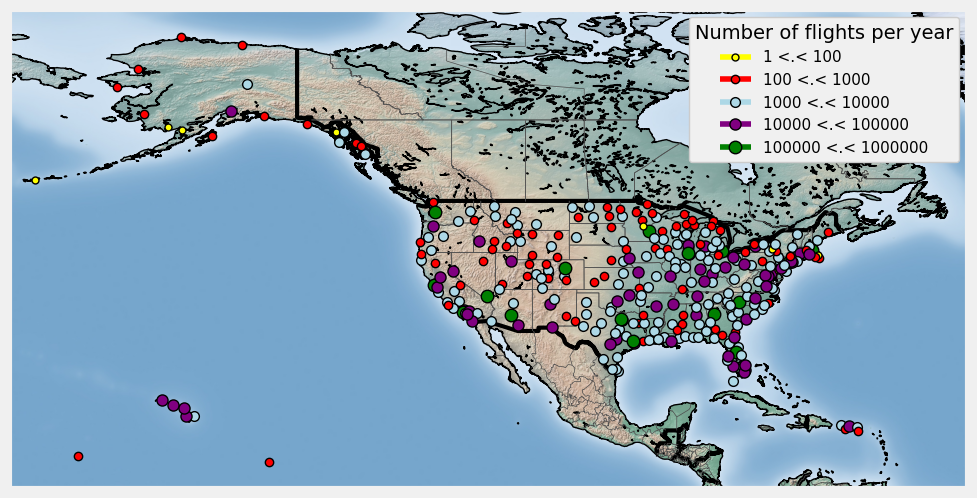

In [4]:

count_flights = df['ORIGIN_AIRPORT'].value_counts()
plt.figure(figsize=(11,11))

colors = ['yellow', 'red', 'lightblue', 'purple', 'green', 'orange']
size_limits = [1, 100, 1000, 10000, 100000, 1000000]
labels = []
for i in range(len(size_limits)-1):
    labels.append("{} <.< {}".format(size_limits[i], size_limits[i+1]))

map = Basemap(resolution='i',llcrnrlon=-180, urcrnrlon=-50,
              llcrnrlat=10, urcrnrlat=75, lat_0=0, lon_0=0,)
map.shadedrelief()
map.drawcoastlines()
map.drawcountries(linewidth = 3)
map.drawstates(color='0.3')

for index, (code, y,x) in airports[['IATA_CODE', 'LATITUDE', 'LONGITUDE']].iterrows():
    x, y = map(x, y)
    isize = [i for i, val in enumerate(size_limits) if val < count_flights[code]]
    ind = isize[-1]
    map.plot(x, y, marker='o', markersize = ind+5, markeredgewidth = 1, color = colors[ind],
             markeredgecolor='k', label = labels[ind])

handles, labels = plt.gca().get_legend_handles_labels()
by_label = OrderedDict(zip(labels, handles))
key_order = ('1 <.< 100', '100 <.< 1000', '1000 <.< 10000',
             '10000 <.< 100000', '100000 <.< 1000000')
new_label = OrderedDict()
for key in key_order:
    new_label[key] = by_label[key]
plt.legend(new_label.values(), new_label.keys(), loc = 1, prop= {'size':11},
           title='Number of flights per year', frameon = True, framealpha = 1)
plt.show()

Với kích thước lớn của bộ dữ liệu (hơn 5.8 triệu chuyến bay), việc xử lý toàn bộ dữ liệu sẽ tốn rất nhiều bộ nhớ RAM và thời gian tính toán, đặc biệt trong môi trường Google Colab với tài nguyên giới hạn. Do đó, nhóm quyết định **chỉ giữ lại các chuyến bay trong tháng 1 năm 2015** (~450.000 chuyến bay) để phục vụ phân tích và xây dựng mô hình. Tháng 1 được chọn vì đây là tháng mùa đông ở Mỹ — thời điểm có nhiều biến động thời tiết, do đó dữ liệu này có tính đại diện tốt cho bài toán dự báo delay:

In [5]:
df = df[df['MONTH'] == 1]

___
## 1. Làm sạch
___
### 1.1 Ngày và giờ

Trong dataframe ban đầu, ngày được mã hóa theo 4 biến: **YEAR, MONTH, DAY**, và **DAY_OF_WEEK**. Thực ra, Python cung cấp định dạng **_datetime_** rất tiện lợi để làm việc với ngày và giờ và do đó nhóm chuyển đổi ngày sang định dạng này:

In [6]:
df['DATE'] = pd.to_datetime(df[['YEAR','MONTH', 'DAY']])

Hơn nữa, trong biến **SCHEDULED_DEPARTURE**, giờ cất cánh được mã hóa dưới dạng số thực, trong đó hai chữ số đầu tiên chỉ giờ và hai chữ số cuối chỉ phút. Định dạng này không thuận tiện và do đó nhóm chuyển đổi nó. Cuối cùng, nhóm kết hợp giờ cất cánh với ngày bay. Để thực hiện các chuyển đổi này, nhóm định nghĩa một vài hàm:

In [7]:
def format_heure(chaine):
    if pd.isnull(chaine):
        return np.nan
    else:
        if chaine == 2400: chaine = 0
        chaine = "{0:04d}".format(int(chaine))
        heure = datetime.time(int(chaine[0:2]), int(chaine[2:4]))
        return heure

def combine_date_heure(x):
    if pd.isnull(x[0]) or pd.isnull(x[1]):
        return np.nan
    else:
        return datetime.datetime.combine(x[0],x[1])

def create_flight_time(df, col):
    liste = []
    for index, cols in df[['DATE', col]].iterrows():
        if pd.isnull(cols[1]):
            liste.append(np.nan)
        elif float(cols[1]) == 2400:
            cols[0] += datetime.timedelta(days=1)
            cols[1] = datetime.time(0,0)
            liste.append(combine_date_heure(cols))
        else:
            cols[1] = format_heure(cols[1])
            liste.append(combine_date_heure(cols))
    return pd.Series(liste)

và nhóm gọi chúng để xử lý các biến trong dataframe:

In [8]:
df['SCHEDULED_DEPARTURE'] = create_flight_time(df, 'SCHEDULED_DEPARTURE')
df['DEPARTURE_TIME'] = df['DEPARTURE_TIME'].apply(format_heure)
df['SCHEDULED_ARRIVAL'] = df['SCHEDULED_ARRIVAL'].apply(format_heure)
df['ARRIVAL_TIME'] = df['ARRIVAL_TIME'].apply(format_heure)

df.loc[:5, ['SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'DEPARTURE_TIME',
             'ARRIVAL_TIME', 'DEPARTURE_DELAY', 'ARRIVAL_DELAY']]

,SCHEDULED_DEPARTURE,SCHEDULED_ARRIVAL,DEPARTURE_TIME,ARRIVAL_TIME,DEPARTURE_DELAY,ARRIVAL_DELAY
0,2015-01-01 00:05:00,04:30:00,23:54:00,04:08:00,-11.0,-22.0
1,2015-01-01 00:10:00,07:50:00,00:02:00,07:41:00,-8.0,-9.0
2,2015-01-01 00:20:00,08:06:00,00:18:00,08:11:00,-2.0,5.0
3,2015-01-01 00:20:00,08:05:00,00:15:00,07:56:00,-5.0,-9.0
4,2015-01-01 00:25:00,03:20:00,00:24:00,02:59:00,-1.0,-21.0
5,2015-01-01 00:25:00,06:02:00,00:20:00,06:10:00,-5.0,8.0


Lưu ý rằng trong thực tế, nội dung của các biến **DEPARTURE_TIME** và **ARRIVAL_TIME** có thể gây hiểu nhầm một chút vì chúng không chứa ngày tháng. Ví dụ, trong mục nhập đầu tiên của dataframe, chuyến bay dự kiến khởi hành vào lúc 0h05 ngày 1 tháng 1. Biến **DEPARTURE_TIME** chỉ ra 23h54 và do đó chúng ta không biết liệu chuyến bay đã xuất phát sớm hay có sự chậm trễ lớn. Do đó, các biến **DEPARTURE_DELAY** và **ARRIVAL_DELAY** sẽ hữu ích hơn vì chúng cung cấp trực tiếp độ trễ theo phút. Vì vậy, trong phần sau, nhóm sẽ không sử dụng các biến **DEPARTURE_TIME** và **ARRIVAL_TIME**.

### 1.2 Loại bỏ các biến không sử dụng

Cuối cùng, nhóm dọn dẹp dataframe bằng cách loại bỏ các biến nhóm sẽ không sử dụng và sắp xếp lại các cột để dễ đọc hơn:

In [9]:
variables_to_remove = ['TAXI_OUT', 'TAXI_IN', 'WHEELS_ON', 'WHEELS_OFF', 'YEAR',
                       'MONTH','DAY','DAY_OF_WEEK','DATE', 'AIR_SYSTEM_DELAY',
                       'SECURITY_DELAY', 'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY',
                       'WEATHER_DELAY', 'DIVERTED', 'CANCELLED', 'CANCELLATION_REASON',
                       'FLIGHT_NUMBER', 'TAIL_NUMBER', 'AIR_TIME']
cols_to_drop = [col for col in variables_to_remove if col in df.columns]
df.drop(cols_to_drop, axis=1, inplace=True)

keep_columns = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
                'SCHEDULED_DEPARTURE', 'DEPARTURE_TIME', 'DEPARTURE_DELAY',
                'SCHEDULED_ARRIVAL', 'ARRIVAL_TIME', 'ARRIVAL_DELAY',
                'SCHEDULED_TIME', 'ELAPSED_TIME']
missing_keep_columns = [col for col in keep_columns if col not in df.columns]
if missing_keep_columns:
    raise KeyError(f'Thiếu cột cần giữ lại trong df: {missing_keep_columns}')
df = df[keep_columns]
df[:5]

,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,SCHEDULED_TIME,ELAPSED_TIME
0,AS,ANC,SEA,2015-01-01 00:05:00,23:54:00,-11.0,04:30:00,04:08:00,-22.0,205.0,194.0
1,AA,LAX,PBI,2015-01-01 00:10:00,00:02:00,-8.0,07:50:00,07:41:00,-9.0,280.0,279.0
2,US,SFO,CLT,2015-01-01 00:20:00,00:18:00,-2.0,08:06:00,08:11:00,5.0,286.0,293.0
3,AA,LAX,MIA,2015-01-01 00:20:00,00:15:00,-5.0,08:05:00,07:56:00,-9.0,285.0,281.0
4,AS,SEA,ANC,2015-01-01 00:25:00,00:24:00,-1.0,03:20:00,02:59:00,-21.0,235.0,215.0


### 1.3 Hệ số lấp đầy và xử lý missing values

Ở giai đoạn này, nhóm kiểm tra mức độ đầy đủ của bộ dữ liệu:

In [10]:
missing_df = df.isnull().sum(axis=0).reset_index()
missing_df.columns = ['variable', 'missing values']
missing_df['filling factor (%)']=(df.shape[0]-missing_df['missing values'])/df.shape[0]*100
missing_df.sort_values('filling factor (%)').reset_index(drop = True)

,variable,missing values,filling factor (%)
0,ELAPSED_TIME,12955,97.243429
1,ARRIVAL_DELAY,12955,97.243429
2,ARRIVAL_TIME,12271,97.388971
3,DEPARTURE_TIME,11657,97.519618
4,DEPARTURE_DELAY,11657,97.519618
5,DESTINATION_AIRPORT,0,100.000000
6,SCHEDULED_DEPARTURE,0,100.000000
7,AIRLINE,0,100.000000
8,SCHEDULED_ARRIVAL,0,100.000000
9,ORIGIN_AIRPORT,0,100.000000


Chúng ta thấy rằng tỷ lệ lấp đầy của các biến khá tốt (> 97%). Vì phạm vi của project này không nhằm mục đích tạo ra một mô hình dự đoán trễ chuyến bay tiên tiến nhất (state-of-the-art), nhóm quyết định tiếp tục mà không cố gắng điền khuyết các phần bị thiếu và chỉ đơn giản loại bỏ các bản ghi chứa giá trị bị khuyết.

In [11]:
df.dropna(inplace = True)

___
## 2. So sánh các hãng hàng không

Như đã nói trước đó, biến **AIRLINE** chứa các chữ viết tắt của hãng hàng không. Tên đầy đủ của chúng có thể được lấy từ file `airlines.csv`.

In [12]:
airlines_names = pd.read_csv('/content/drive/MyDrive/airlines.csv')
airlines_names

,IATA_CODE,AIRLINE
0,UA,United Air Lines Inc.
1,AA,American Airlines Inc.
2,US,US Airways Inc.
3,F9,Frontier Airlines Inc.
4,B6,JetBlue Airways
5,OO,Skywest Airlines Inc.
6,AS,Alaska Airlines Inc.
7,NK,Spirit Air Lines
8,WN,Southwest Airlines Co.
9,DL,Delta Air Lines Inc.


Để sử dụng tiếp, nhóm đưa nội dung của dataframe này vào một dictionary:

In [13]:
abbr_companies = airlines_names.set_index('IATA_CODE')['AIRLINE'].to_dict()

___
### 2.1 Mô tả thống kê cơ bản của các hãng hàng không

Là bước đầu tiên, nhóm xem xét tất cả các chuyến bay từ tất cả các hãng vận chuyển. Ở đây, mục đích là phân loại các hãng hàng không dựa trên mức độ đúng giờ của họ và cho mục đích đó, nhóm tính toán một vài thông số thống kê cơ bản:

Cụ thể, đối với mỗi hãng hàng không, các chỉ số này có ý nghĩa như sau:

- **Count** (Số lượng): Tổng số chuyến bay của hãng hàng không đó đã thực hiện (được ghi nhận trong tập dữ liệu). Ý nghĩa: Giúp nhóm đánh giá quy mô hoạt động của hãng (hãng bay nhiều hay bay ít).

- **Mean** (Trung bình): Thời gian trễ trung bình của tất cả các chuyến bay thuộc hãng đó. Ý nghĩa: Cho biết nhìn chung hãng này thường trễ bao nhiêu phút. (Nếu mean là số âm, tức là trung bình hãng đó thường khởi hành/hạ cánh sớm hơn lịch trình).

- **Min** (Giá trị nhỏ nhất): Thời gian trễ thấp nhất được ghi nhận của hãng. Ý nghĩa: Thường là một con số âm rất lớn, đại diện cho chuyến bay cất cánh/hạ cánh sớm nhất so với dự kiến.

- **Max** (Giá trị lớn nhất): Thời gian trễ cao nhất được ghi nhận của hãng. Ý nghĩa: Đại diện cho chuyến bay bị delay tồi tệ nhất (chậm trễ lâu nhất, có thể lên tới vài trăm hoặc hàng nghìn phút do bão hoặc sự cố kỹ thuật).

In [14]:
def get_stats(group):
    return {'min': group.min(), 'max': group.max(),
            'count': group.count(), 'mean': group.mean()}

global_stats = df['DEPARTURE_DELAY'].groupby(df['AIRLINE']).apply(get_stats).unstack()
global_stats = global_stats.sort_values('count')
global_stats

,min,max,count,mean
AIRLINE,,,,
VX,-20.0,397.0,4647.0,6.896277
HA,-26.0,1003.0,6408.0,1.311954
F9,-32.0,696.0,6735.0,17.910765
NK,-28.0,557.0,8632.0,13.073100
AS,-47.0,444.0,13151.0,3.072086
B6,-27.0,500.0,20482.0,9.988331
MQ,-29.0,780.0,27568.0,15.995865
US,-26.0,638.0,32478.0,5.175011
UA,-40.0,886.0,37363.0,13.885555


Bây giờ, để thuận tiện cho việc thể hiện thông tin đó, nhóm xây dựng một số hình ảnh:

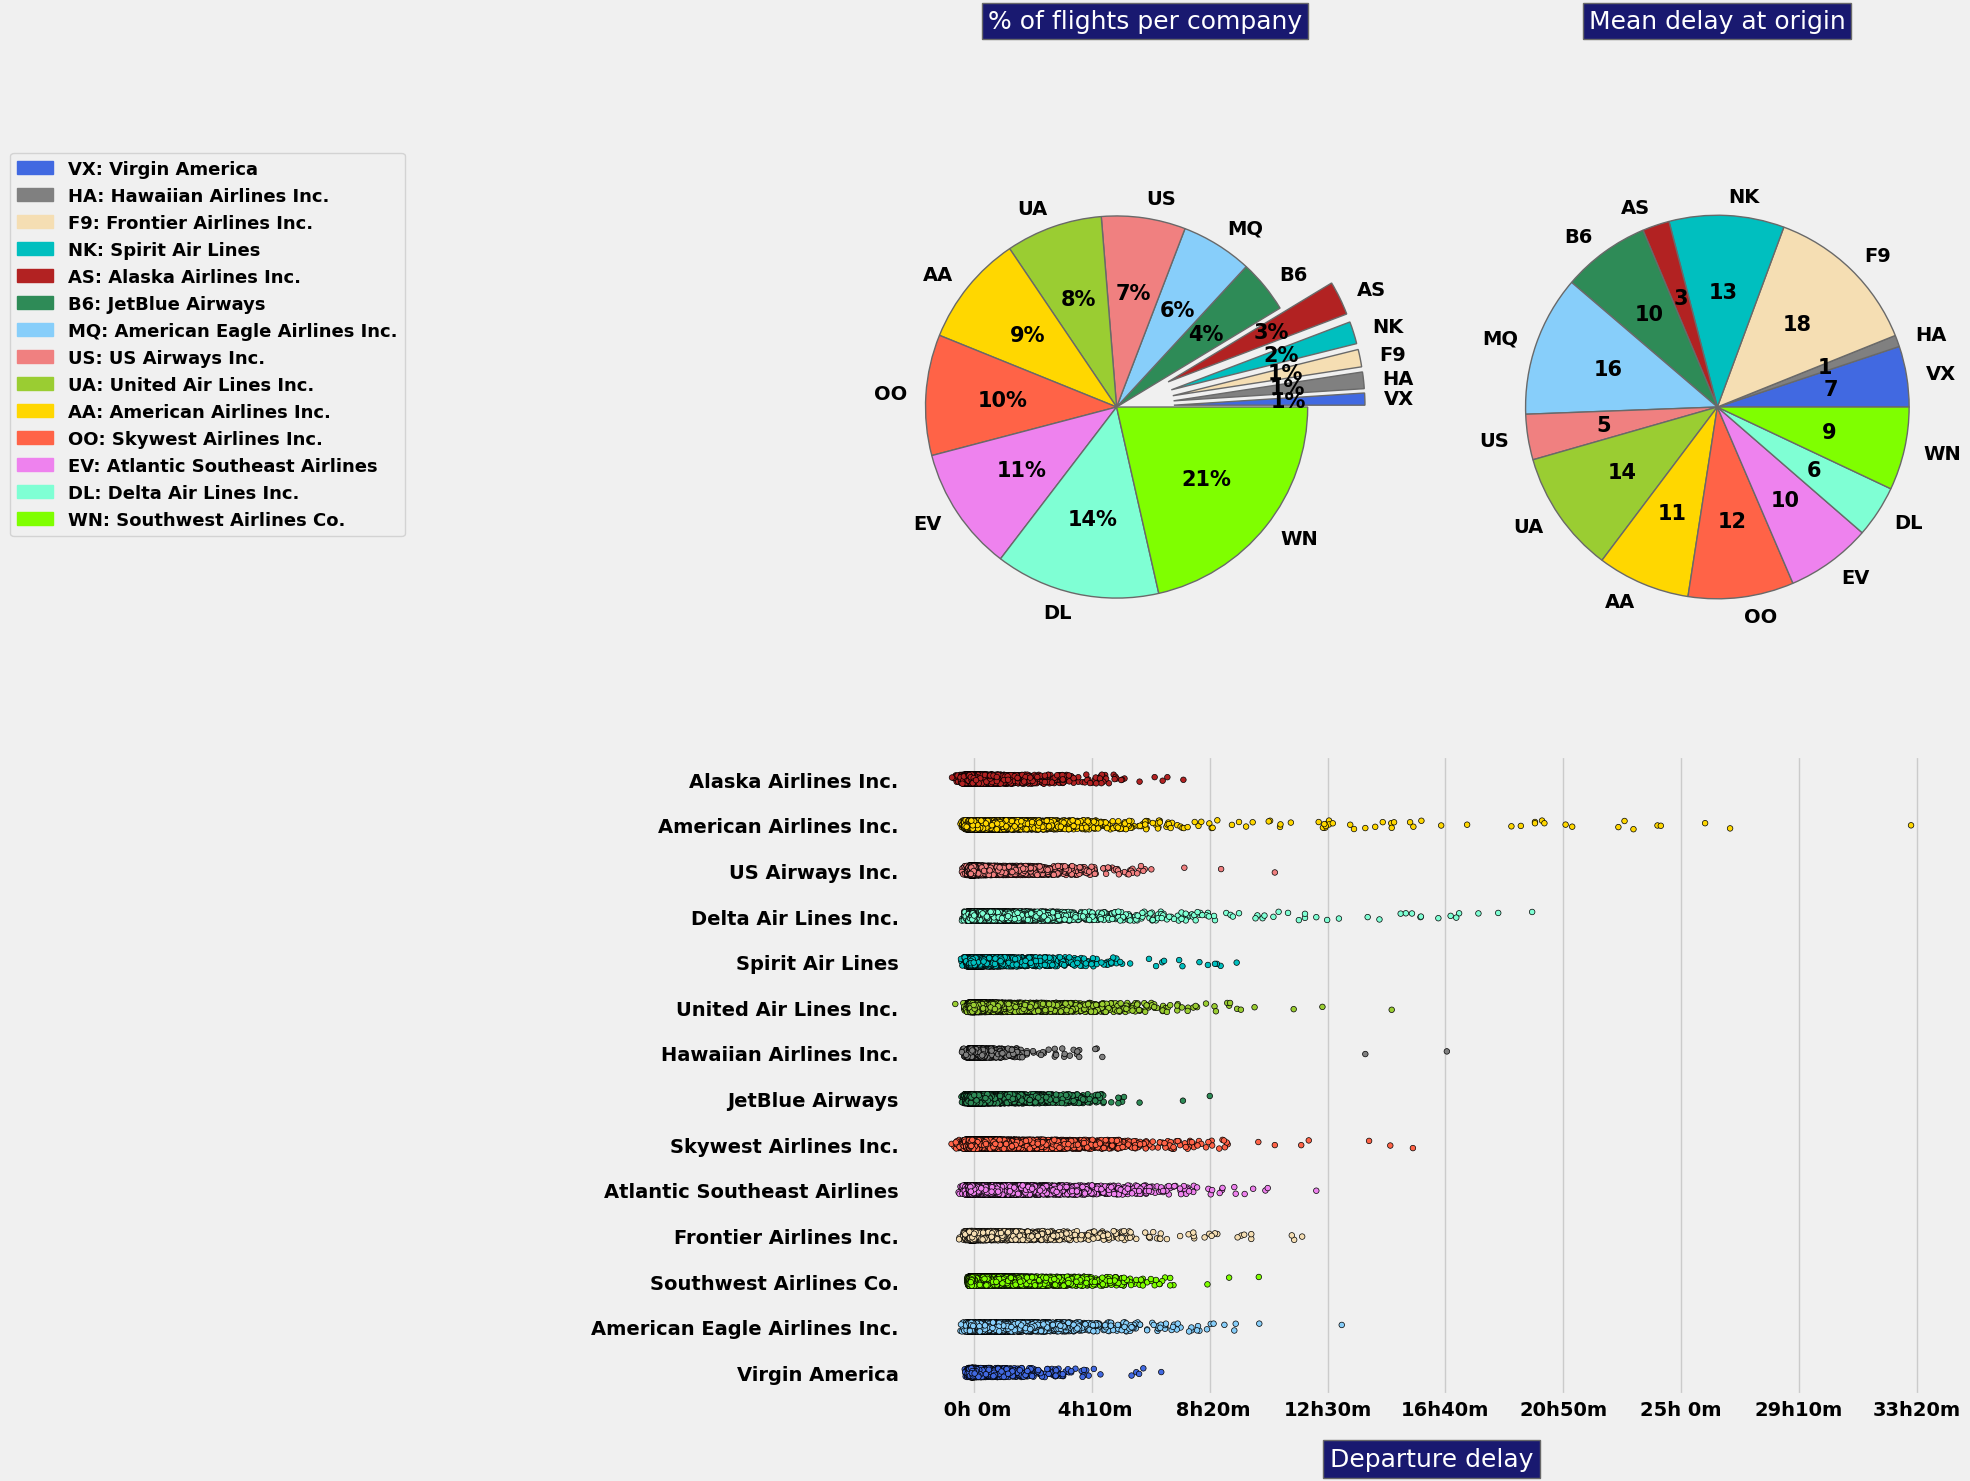

In [15]:
font = {'family' : 'sans-serif', 'weight' : 'bold', 'size'   : 15}
mpl.rc('font', **font)
import matplotlib.patches as mpatches

df2 = df.loc[:, ['AIRLINE', 'DEPARTURE_DELAY']]
df2['AIRLINE'] = df2['AIRLINE'].replace(abbr_companies)
colors = ['royalblue', 'grey', 'wheat', 'c', 'firebrick', 'seagreen', 'lightskyblue',
          'lightcoral', 'yellowgreen', 'gold', 'tomato', 'violet', 'aquamarine', 'chartreuse']

fig = plt.figure(1, figsize=(16,15))
gs=GridSpec(2,2)
ax1=fig.add_subplot(gs[0,0])
ax2=fig.add_subplot(gs[0,1])
ax3=fig.add_subplot(gs[1,:])

labels = [s for s in  global_stats.index]
sizes  = global_stats['count'].values
explode = [0.3 if sizes[i] < 20000 else 0.0 for i in range(len(abbr_companies))]
patches, texts, autotexts = ax1.pie(sizes, explode = explode,
                                labels=labels, colors = colors,  autopct='%1.0f%%',
                                shadow=False, startangle=0)
for i in range(len(abbr_companies)):
    texts[i].set_fontsize(14)
ax1.axis('equal')
ax1.set_title('% of flights per company', bbox={'facecolor':'midnightblue', 'pad':5},
              color = 'w',fontsize=18, y=1.08)

comp_handler = []
for i in range(len(abbr_companies)):
    comp_handler.append(mpatches.Patch(color=colors[i],
            label = global_stats.index[i] + ': ' + abbr_companies[global_stats.index[i]]))
ax1.legend(handles=comp_handler, bbox_to_anchor=(0.02, 0.9),
           fontsize = 13, bbox_transform=plt.gcf().transFigure)

sizes  = global_stats['mean'].values
sizes  = [max(s,0) for s in sizes]
explode = [0.0 if sizes[i] < 20000 else 0.01 for i in range(len(abbr_companies))]
patches, texts, autotexts = ax2.pie(sizes, explode = explode, labels = labels,
                                colors = colors, shadow=False, startangle=0,
                                autopct = lambda p :  '{:.0f}'.format(p * sum(sizes) / 100))
for i in range(len(abbr_companies)):
    texts[i].set_fontsize(14)
ax2.axis('equal')
ax2.set_title('Mean delay at origin', bbox={'facecolor':'midnightblue', 'pad':5},
              color='w', fontsize=18,y=1.08)

colors = ['firebrick', 'gold', 'lightcoral', 'aquamarine', 'c', 'yellowgreen', 'grey',
          'seagreen', 'tomato', 'violet', 'wheat', 'chartreuse', 'lightskyblue', 'royalblue']

ax3 = sns.stripplot(y="AIRLINE", x="DEPARTURE_DELAY", size=4, palette=list(colors),
                    data=df2, jitter=True, hue="AIRLINE", legend=False)

plt.setp(ax3.collections, edgecolor='black', linewidth=0.5)
plt.setp(ax3.get_xticklabels(), fontsize=14)
plt.setp(ax3.get_yticklabels(), fontsize=14)
ax3.set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*[int(y) for y in divmod(x,60)])
                         for x in ax3.get_xticks()])
plt.xlabel('Departure delay', fontsize=18, bbox={'facecolor':'midnightblue', 'pad':5},
           color='w', labelpad=20)
ax3.yaxis.label.set_visible(False)

plt.tight_layout(w_pad=3)
plt.show()

Quan sát biểu đồ tròn đầu tiên thể hiện tỷ lệ phần trăm chuyến bay của từng hãng hàng không, nhóm nhận thấy có sự chênh lệch rất lớn về quy mô khai thác. **Southwest Airlines (WN) chiếm ~20% tổng số chuyến bay** — gần bằng tổng khối lượng của 7 hãng nhỏ nhất cộng lại. Hai hãng lớn tiếp theo là American Airlines (AA) và Delta (DL), mỗi hãng chiếm ~14–15%.

Tuy nhiên, biểu đồ tròn thứ hai (độ trễ trung bình) lại cho bức tranh ngược lại: **sự chênh lệch về delay giữa các hãng là khá đồng đều**, đa số tập trung ở mức ~11 ± 7 phút. Ngoại lệ đáng chú ý là **Hawaiian Airlines (HA)** và **Alaska Airlines (AS)** — hai hãng này có delay trung bình cực thấp, phản ánh lợi thế hoạt động tại các hub ít congestion (Hawaii, Tây Bắc Thái Bình Dương).

Biểu đồ phân tán ở dưới (strip plot) minh họa rõ hơn: **đa số chuyến bay trễ dưới 30 phút**, nhưng thỉnh thoảng xuất hiện các outliers trễ hàng giờ đồng hồ — thường do thời tiết cực đoan hoặc sự cố kỹ thuật nghiêm trọng. Các outliers này cần được xử lý cẩn thận trong giai đoạn modeling (loại bỏ trước khi fit, hoặc clip ở ngưỡng hợp lý) để tránh bias mô hình.

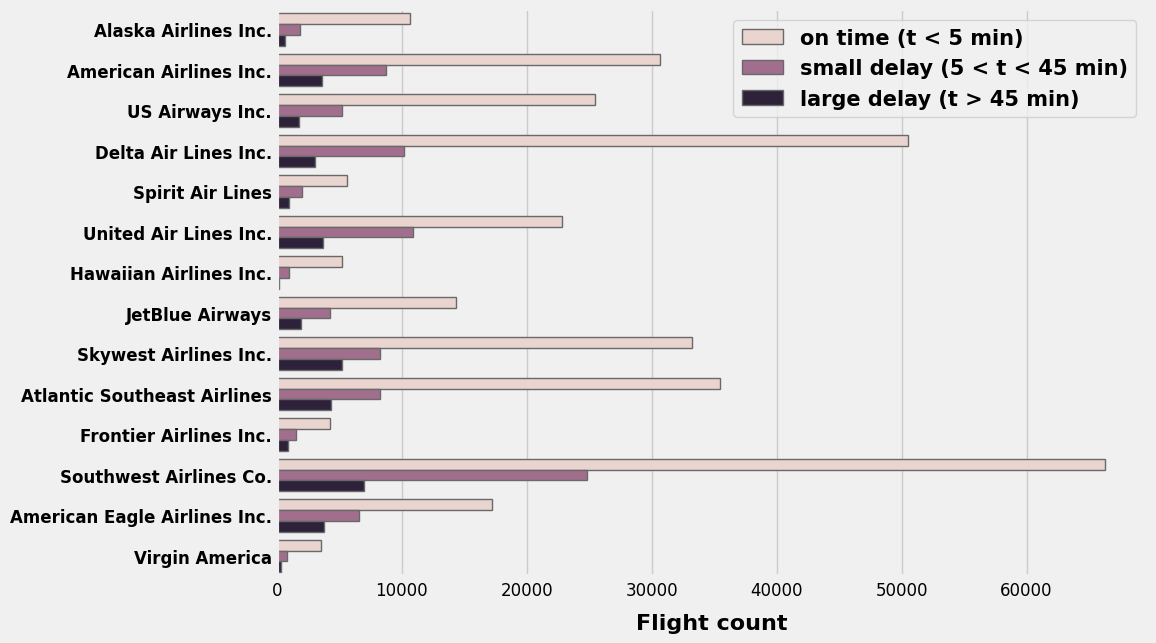

In [16]:
delay_type = lambda x:((0,1)[x > 5],2)[x > 45]
df['DELAY_LEVEL'] = df['DEPARTURE_DELAY'].apply(delay_type)

fig = plt.figure(1, figsize=(10,7))
ax = sns.countplot(y="AIRLINE", hue='DELAY_LEVEL', data=df)

labels = [abbr_companies[item.get_text()] for item in ax.get_yticklabels()]
ax.set_yticklabels(labels)
plt.setp(ax.get_xticklabels(), fontsize=12, weight = 'normal', rotation = 0);
plt.setp(ax.get_yticklabels(), fontsize=12, weight = 'bold', rotation = 0);
ax.yaxis.label.set_visible(False)
plt.xlabel('Flight count', fontsize=16, weight = 'bold', labelpad=10)

L = plt.legend()
L.get_texts()[0].set_text('on time (t < 5 min)')
L.get_texts()[1].set_text('small delay (5 < t < 45 min)')
L.get_texts()[2].set_text('large delay (t > 45 min)')
plt.show()

Biểu đồ này thống kê số lượng các chuyến bay theo ba mức độ trễ: **đúng giờ (< 5 phút)**, **trễ nhẹ (5–45 phút)** và **trễ nặng (> 45 phút)**. Một số quan sát nổi bật:

- Ở mọi hãng hàng không, nhóm "đúng giờ" luôn chiếm đa số, thường từ 60–75% tổng số chuyến bay.
- **SkyWest Airlines (OO)** có tỷ lệ trễ nặng (> 45 phút) gần bằng 30% tổng trễ — cao bất thường. Nguyên nhân có thể liên quan đến việc OO khai thác nhiều đường bay ngắn khu vực với máy bay nhỏ, dễ bị ảnh hưởng dây chuyền.
- **Southwest Airlines (WN)** ngược lại: tỷ lệ trễ nặng thấp hơn đến 4 lần so với trễ nhẹ — cho thấy hệ thống vận hành hiệu quả dù quy mô lớn.
- **Hawaiian Airlines (HA)** và **Alaska Airlines (AS)** gần như không có cột trễ nặng — nhất quán với kết quả từ biểu đồ trước.

**Insight quan trọng cho modeling:** Bài toán phân loại "có trễ nặng không" (> 45 phút) sẽ dễ hơn bài toán hồi quy dự báo chính xác số phút trễ, vì biên giới giữa hai nhóm rõ ràng hơn.

### 2.2 Phân phối độ trễ và đặc trưng hóa theo hệ số mũ

Như đã trình bày ở phần trước, độ trễ trung bình giữa các hãng hàng không nhìn chung khá đồng đều (ngoại trừ hai trường hợp ngoại lệ) và dao động ở mức khoảng 11$\pm$7 phút. Nhóm cũng đã chỉ ra rằng mức trung bình thấp này thực chất là hệ quả từ việc có một tỷ lệ rất lớn các chuyến bay cất cánh đúng lịch trình. Tuy nhiên, thỉnh thoảng hệ thống vẫn ghi nhận những sự cố trễ chuyến kéo dài. Vì vậy, trong phần này, nhóm sẽ đi sâu vào phân tích chi tiết phân phối độ trễ (delays distribution) của từng hãng hàng không:

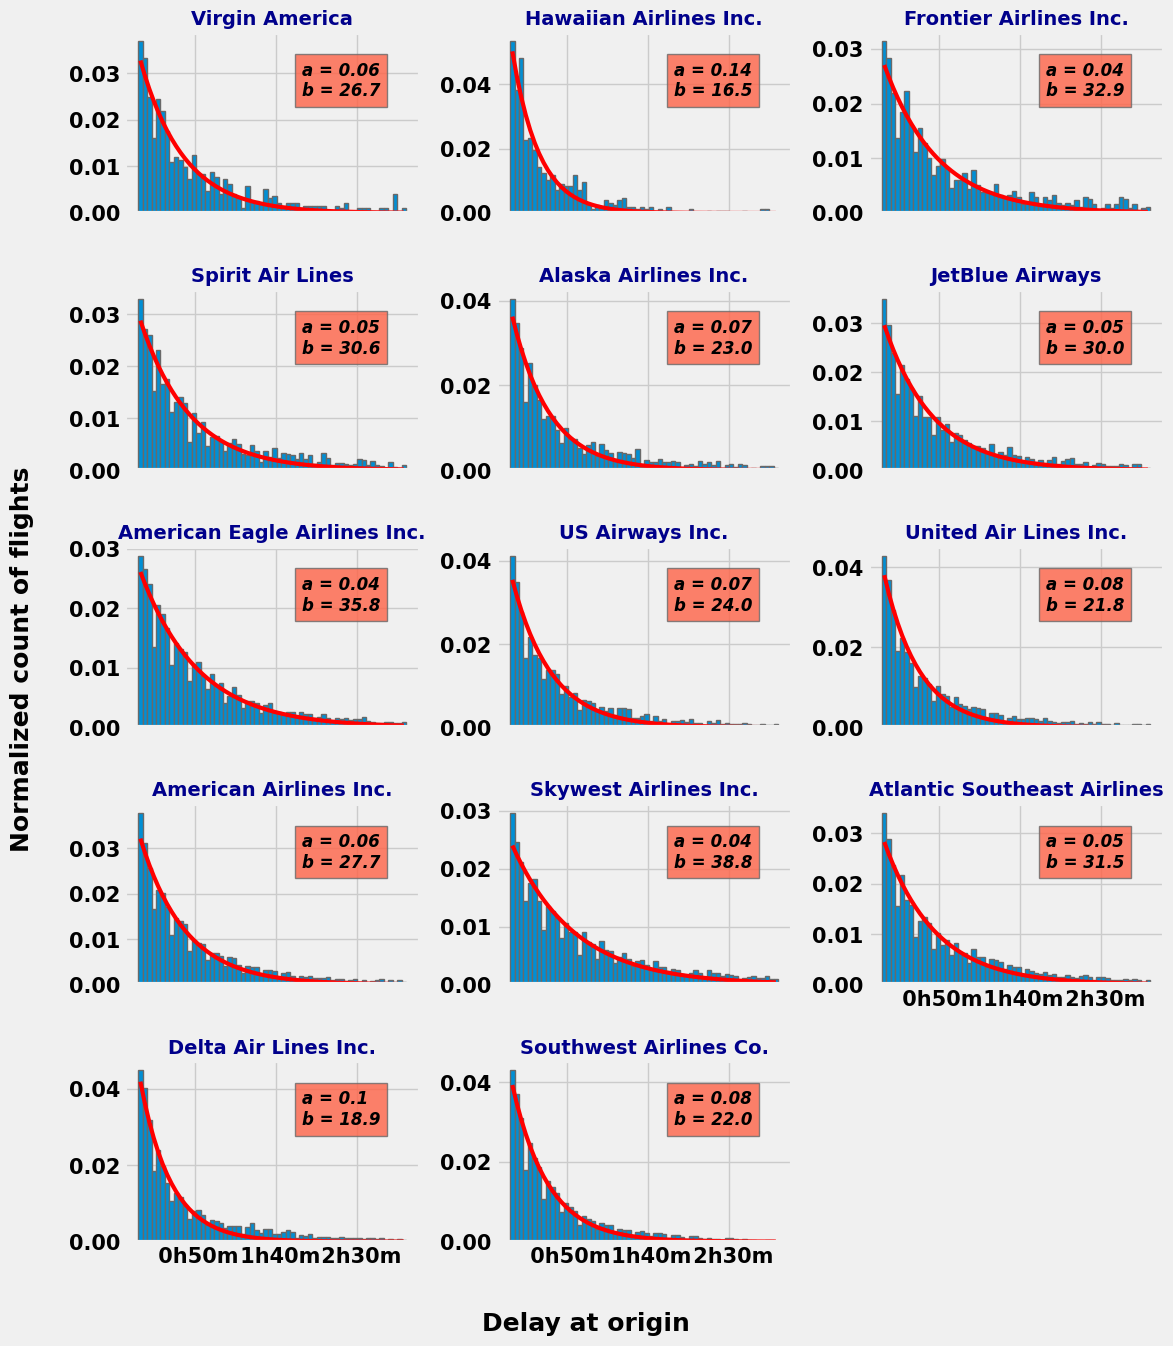

In [17]:
from scipy.optimize import curve_fit

def func(x, a, b):
    return a * np.exp(-x/b)

points = [] ; label_company = []

fig = plt.figure(1, figsize=(12, 14))
i = 0

for carrier_name in [abbr_companies[x] for x in global_stats.index]:
    i += 1
    ax = fig.add_subplot(5, 3, i)

    n, bins, patches = plt.hist(x = df2[df2['AIRLINE']==carrier_name]['DEPARTURE_DELAY'],
                                range = (15,180), density=True, bins= 60)
    bin_centers = bins[:-1] + 0.5 * (bins[1:] - bins[:-1])
    popt, pcov = curve_fit(func, bin_centers, n, p0 = [1, 2])

    points.append(popt)
    label_company.append(carrier_name)

    plt.plot(bin_centers, func(bin_centers, *popt), 'r-', linewidth=3)

    if i not in [12, 13, 14]:
        ax.set_xticklabels(['' for x in ax.get_xticks()])
    else:
        ax.set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*[int(y) for y in divmod(x,60)])
                            for x in ax.get_xticks()])

    plt.title(carrier_name, fontsize = 14, fontweight = 'bold', color = 'darkblue')

    ax.text(0.60, 0.65, 'a = {}\nb = {}'.format(round(popt[0],2), round(popt[1],1)),
            style='italic', transform=ax.transAxes, fontsize = 12, family='sans-serif',
            bbox={'facecolor':'tomato', 'alpha':0.8, 'pad':5})

fig.text(0.02, 0.5, 'Normalized count of flights', va='center', rotation='vertical', fontsize=18)
fig.text(0.5, 0.02, 'Delay at origin', ha='center', fontsize=18)

plt.tight_layout(rect=[0.05, 0.05, 1, 0.98], h_pad=2.0, w_pad=1.0)
plt.show()

Biểu đồ trên thể hiện phân phối chuẩn hóa của các khoảng thời gian trễ, được nhóm mô hình hóa bằng một hàm phân phối mũ có phương trình $f(x) = a \, \mathrm{exp} (-x/b)$. Các tham số $a$ và $b$ thu được dùng để mô tả từng hãng hàng không được hiển thị ở góc trên bên phải của mỗi đồ thị con (panel).

Cần lưu ý rằng việc chuẩn hóa phân phối ngụ ý giá trị tích phân $\int f(x) \, dx \sim 1$. Ở đây, chúng ta không có một đẳng thức tuyệt đối (dấu bằng =) vì phép chuẩn hóa được áp dụng trên các biểu đồ tần suất (histogram) chứ không áp dụng trực tiếp lên hàm mô hình. Tuy nhiên, mối liên hệ này dẫn đến việc hai hệ số $a$ và $b$ sẽ có sự tương quan tỷ lệ nghịch với nhau ($a \propto 1/b$). Do đó, trên thực tế, chúng ta chỉ cần dùng một trong hai giá trị này là đã đủ để diễn tả toàn bộ hình dáng của các phân phối.

Cuối cùng, dựa vào giá trị của $a$ hoặc $b$, nhóm hoàn toàn có thể thiết lập một bảng xếp hạng cho các hãng hàng không: những giá trị $a$ thấp sẽ đại diện cho các hãng có tỷ lệ trễ chuyến kéo dài (nghiêm trọng) cao. Ngược lại, những hãng hàng không nổi bật về sự đúng giờ và độ tin cậy sẽ đạt được giá trị $a$ cao:

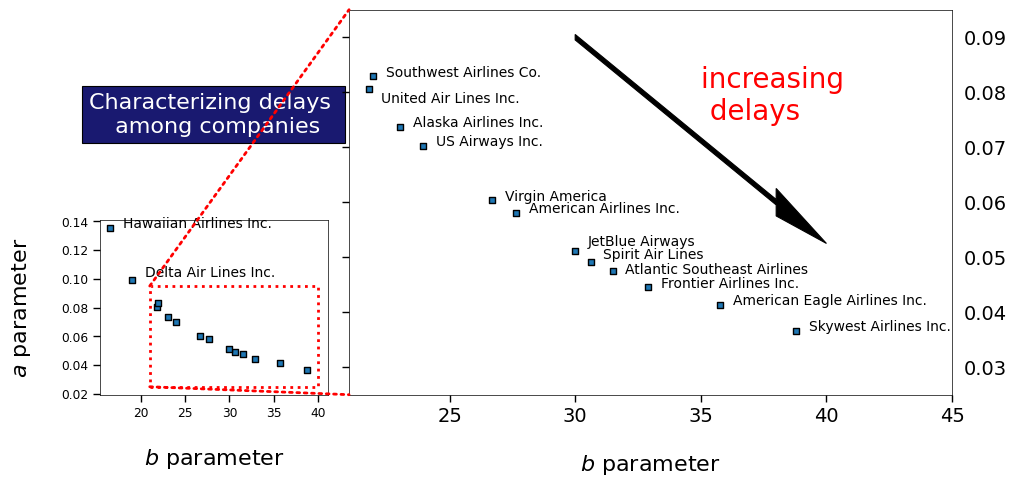

In [18]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import ConnectionPatch, Rectangle
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update(mpl.rcParamsDefault)
sns.set_context('paper')

fig = plt.figure(1, figsize=(11,5))

y_shift = [0 for _ in range(14)]
y_shift[3] = 0.5/1000
y_shift[12] = 2.5/1000
y_shift[11] = -0.5/1000
y_shift[8] = -2.5/1000
y_shift[5] = 1/1000

x_val = [s[1] for s in points]
y_val = [s[0] for s in points]

gs = GridSpec(2, 7)

ax1 = fig.add_subplot(gs[1, 0:2])
ax1.scatter(x=x_val, y=y_val, marker='s', edgecolor='black', linewidth=1)

for i in [1, 12]:
    ax1.annotate(label_company[i], xy=(x_val[i]+1.5, y_val[i]+y_shift[i]),
                 xycoords='data', fontsize=10)

ax1.set_xlabel("$b$ parameter", fontsize=16, labelpad=20)
ax1.set_ylabel("$a$ parameter", fontsize=16, labelpad=20)

ax1.text(.5, 1.5, 'Characterizing delays \n among companies', fontsize=16,
         bbox={'facecolor': 'midnightblue', 'pad': 5}, color='w',
         horizontalalignment='center', transform=ax1.transAxes)

for k in ['top', 'bottom', 'right', 'left']:
    ax1.spines[k].set_visible(True)
    ax1.spines[k].set_linewidth(0.5)
    ax1.spines[k].set_color('k')

rect = Rectangle((21, 0.025), 19, 0.07, linewidth=2,
                 edgecolor='r', linestyle=':', facecolor='none')
ax1.add_patch(rect)

ax2 = fig.add_subplot(gs[0:2, 2:])
ax2.scatter(x=x_val, y=y_val, marker='s', edgecolor='black', linewidth=1)

ax2.set_xlim(21, 45)
ax2.set_ylim(0.025, 0.095)

for i in range(len(label_company)):
    ax2.annotate(label_company[i], xy=(x_val[i]+0.5, y_val[i]+y_shift[i]),
                 xycoords='data', fontsize=10)

ax2.arrow(30, 0.09, 8, -0.03, head_width=0.005,
          shape='full', head_length=2, fc='k', ec='k')
ax2.annotate('increasing \n delays', fontsize=20, color='r',
             xy=(35, 0.075), xycoords='data')

ax2.tick_params(labelleft=False, labelright=True)
plt.setp(ax2.get_xticklabels(), fontsize=14)
plt.setp(ax2.get_yticklabels(), fontsize=14)
ax2.set_xlabel("$b$ parameter", fontsize=16, labelpad=20)

for k in ['top', 'bottom', 'right', 'left']:
    ax2.spines[k].set_visible(True)
    ax2.spines[k].set_linewidth(0.5)
    ax2.spines[k].set_color('k')

con1 = ConnectionPatch(xyA=(21, 0.095), xyB=(21, 0.095), coordsA="data", coordsB="data",
                      axesA=ax1, axesB=ax2, linestyle=':', linewidth=2, color="red")
fig.add_artist(con1)

con2 = ConnectionPatch(xyA=(21, 0.025), xyB=(21, 0.025), coordsA="data", coordsB="data",
                      axesA=ax1, axesB=ax2, linestyle=':', linewidth=2, color="red")
fig.add_artist(con2)

plt.show()

Biểu đồ bên trái cung cấp cái nhìn tổng quan về các hệ số $a$ và $b$ của 14 hãng hàng không. **Hawaiian Airlines (HA)** và **Delta Airlines (DL)** dẫn đầu về độ đúng giờ (giá trị $a$ cao, $b$ nhỏ — phân phối delay giảm nhanh). Biểu đồ bên phải thu phóng 12 hãng còn lại:

- **Southwest Airlines (WN)** mặc dù chiếm ~20% chuyến bay vẫn đứng **thứ 3** về đúng giờ — ấn tượng với quy mô khai thác lớn như vậy.
- **SkyWest Airlines (OO)** ở cuối bảng, nhất quán với phân tích ở biểu đồ trước.
- Nhóm giữa (US, AA, UA, B6...) có mức độ đúng giờ khá tương đồng nhau, cho thấy hiệu suất vận hành ngành khá đồng đều trừ các trường hợp ngoại lệ.

**Insight:** Hệ số $b$ càng nhỏ → đường cong phân phối delay giảm càng nhanh → xác suất trễ dài càng thấp. Đây là một cách đánh giá tốt hơn so với chỉ nhìn vào trung bình, vì nó phản ánh cả phân phối đuôi (tail distribution).

___
## 3. Trì hoãn: cất cánh hay hạ cánh?
Trong phần trước, tất cả các thảo luận và số liệu của nhóm đều liên quan đến sự chậm trễ khi khởi hành. Tuy nhiên, những sự chậm trễ này có phần khác so với những chậm trễ được ghi nhận khi đến nơi:

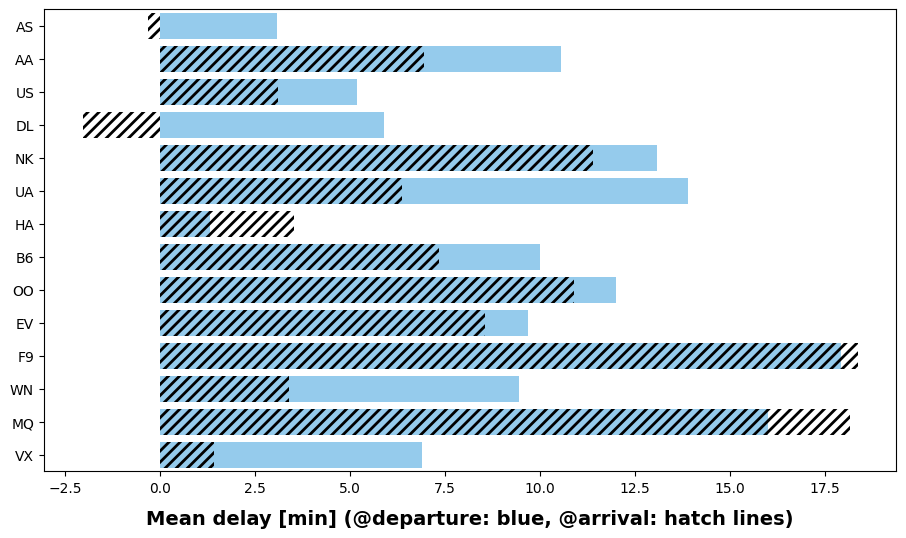

In [19]:
mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams['hatch.linewidth'] = 2.0

fig = plt.figure(1, figsize=(11,6))

ax = sns.barplot(x="DEPARTURE_DELAY", y="AIRLINE", data=df, color="lightskyblue", errorbar=None)

ax = sns.barplot(x="ARRIVAL_DELAY", y="AIRLINE", data=df, color="r", hatch = '///',
                 alpha = 0.0, errorbar=None)

ax.yaxis.label.set_visible(False)
plt.xlabel('Mean delay [min] (@departure: blue, @arrival: hatch lines)',
           fontsize=14, weight = 'bold', labelpad=10)

plt.show()

Quan sát biểu đồ so sánh, nhóm nhận thấy rằng **độ trễ khi hạ cánh (arrival delays) nhỏ hơn đáng kể** so với độ trễ cất cánh ở hầu hết các hãng — trung bình khoảng 3–5 phút ít hơn. Điều này cho thấy các phi công đã **tích cực tăng tốc** trong hành trình để bù đắp thời gian bị mất lúc cất cánh.

Tuy nhiên, không phải hãng nào cũng bù được hoàn toàn. Các hãng có cột arrival delay gần bằng departure delay (khoảng cách nhỏ) cho thấy ít linh hoạt hơn trong việc điều chỉnh tốc độ bay — có thể do đường bay ngắn, nhiều ràng buộc ATC (kiểm soát không lưu), hoặc chính sách tiết kiệm nhiên liệu.

**Quyết định:** Vì departure delay thường cao hơn và là nguyên nhân gốc rễ (chuyến bay cất cánh muộn → hạ cánh muộn), nhóm sẽ dùng **DEPARTURE_DELAY làm target variable** trong tất cả các mô hình tiếp theo.

___
## 4. Mối liên hệ giữa sân bay xuất phát và tình trạng trễ chuyến (Relation between the origin airport and delays)

Trong phần này, nhóm sẽ tiến hành phân tích để xác định xem liệu có mối tương quan nào giữa thời gian trễ chuyến được ghi nhận và sân bay xuất phát (airport of origin) hay không. Theo thống kê từ tập dữ liệu, tổng số sân bay được đưa vào xem xét là:

In [20]:
print("Nb of airports: {}".format(len(df['ORIGIN_AIRPORT'].unique())))

Nb of airports: 312


---
### 4.1 Phạm vi địa lý của các hãng hàng không (Geographical area covered by airlines)
Trong phần này, nhóm sẽ thực hiện thống kê nhanh về số lượng các sân bay điểm đến (destination airports) mà mỗi hãng hàng không đang khai thác:

In [21]:
origin_nb = dict()
for carrier in abbr_companies.keys():
    liste_origin_airport = df[df['AIRLINE'] == carrier]['ORIGIN_AIRPORT'].unique()
    origin_nb[carrier] = len(liste_origin_airport)

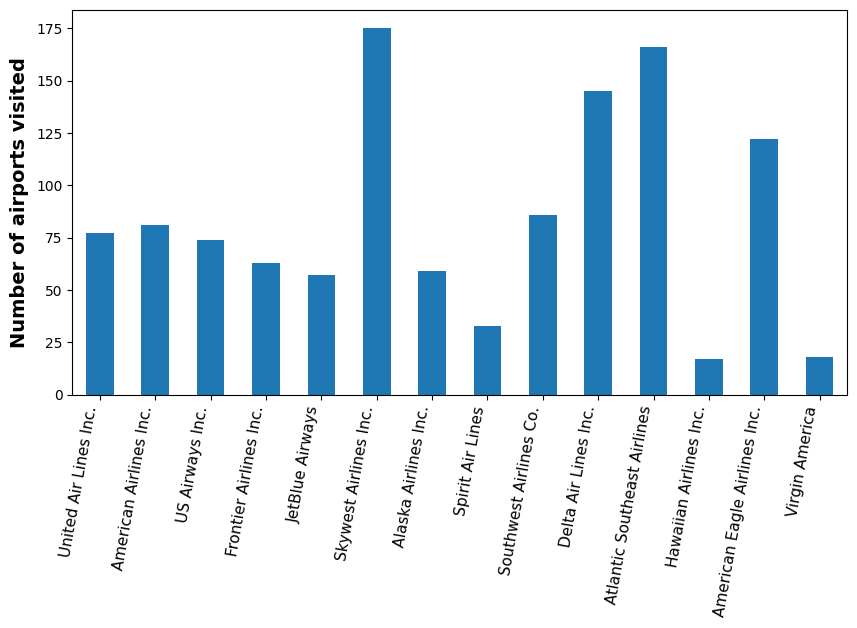

In [22]:
test_df = pd.DataFrame.from_dict(origin_nb, orient='index')
test_df.rename(columns = {0:'count'}, inplace = True)
ax = test_df.plot(kind='bar', figsize = (10,5))
labels = [abbr_companies[item.get_text()] for item in ax.get_xticklabels()]
ax.set_xticklabels(labels)
plt.ylabel('Number of airports visited', fontsize=14, weight = 'bold', labelpad=12, va='center', ha='center')
plt.setp(ax.get_xticklabels(), fontsize=11, ha = 'right', rotation = 80)
ax.legend().set_visible(False)
plt.show()

In [23]:
temp = pd.read_csv('/content/drive/MyDrive/airports.csv')
identify_airport = temp.set_index('IATA_CODE')['CITY'].to_dict()
latitude_airport = temp.set_index('IATA_CODE')['LATITUDE'].to_dict()
longitude_airport = temp.set_index('IATA_CODE')['LONGITUDE'].to_dict()

In [24]:
from collections import OrderedDict
import numpy as np

def make_map(df, carrier, long_min, long_max, lat_min, lat_max):
    fig = plt.figure(figsize=(10, 5))
    ax = fig.add_axes([0., 0., 1., 1.])

    m = Basemap(resolution='i', llcrnrlon=long_min, urcrnrlon=long_max,
                llcrnrlat=lat_min, urcrnrlat=lat_max, lat_0=0, lon_0=0)

    df2 = df[df['AIRLINE'] == carrier]
    count_trajectories = df2.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).size()
    count_trajectories.sort_values(inplace=True)

    g = pyproj.Geod(ellps='WGS84')

    for (origin, dest), s in count_trajectories.items():
        nylat, nylon = latitude_airport[origin], longitude_airport[origin]
        if pd.isnull(nylat) or pd.isnull(nylon): continue
        m.plot(nylon, nylat, marker='o', markersize=8, markeredgewidth=1,
               color='seagreen', markeredgecolor='k', zorder=5)

    for (origin, dest), s in count_trajectories.items():
        nylat, nylon = latitude_airport[origin], longitude_airport[origin]
        lonlat, lonlon = latitude_airport[dest], longitude_airport[dest]

        if pd.isnull(nylat) or pd.isnull(nylon) or pd.isnull(lonlat) or pd.isnull(lonlon):
            continue

        path = g.npts(nylon, nylat, lonlon, lonlat, 100)

        path = [(nylon, nylat)] + path + [(lonlon, lonlat)]
        lons, lats = zip(*path)

        x, y = m(lons, lats)

        if s < 100:
            m.plot(x, y, linewidth=0.5, color='b', alpha=0.3, label='< 100')
        elif s < 200:
            m.plot(x, y, linewidth=1.5, color='r', alpha=0.5, label='100 <.< 200')
        else:
            m.plot(x, y, linewidth=2.5, color='gold', alpha=0.7, label='> 200')

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    key_order = ('< 100', '100 <.< 200', '> 200')
    new_label = OrderedDict()
    for key in key_order:
        if key in by_label: new_label[key] = by_label[key]

    plt.legend(new_label.values(), new_label.keys(), loc='best', prop={'size': 10},
               title='flights per month', facecolor='palegreen', shadow=True)

    m.drawcoastlines()
    m.fillcontinents(color='lightgrey', lake_color='aqua')
    ax.set_title('{} flights'.format(abbr_companies[carrier]))
    plt.show()

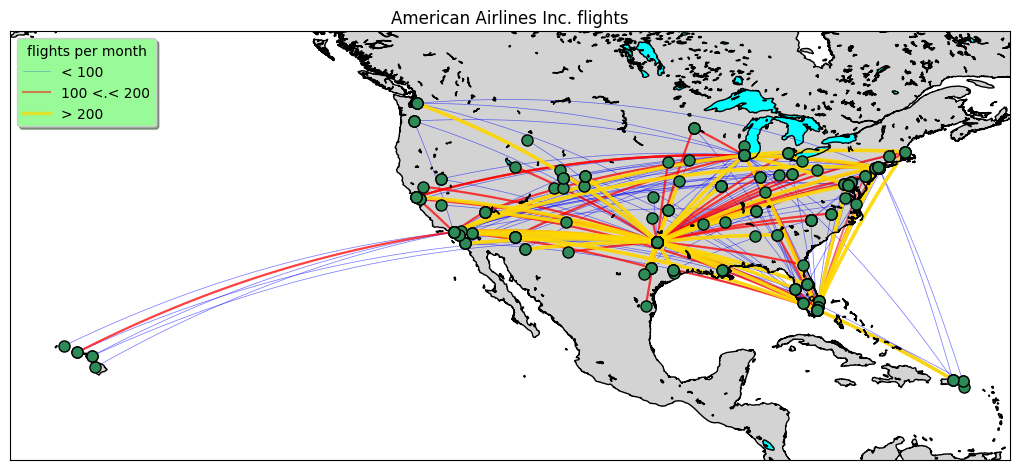

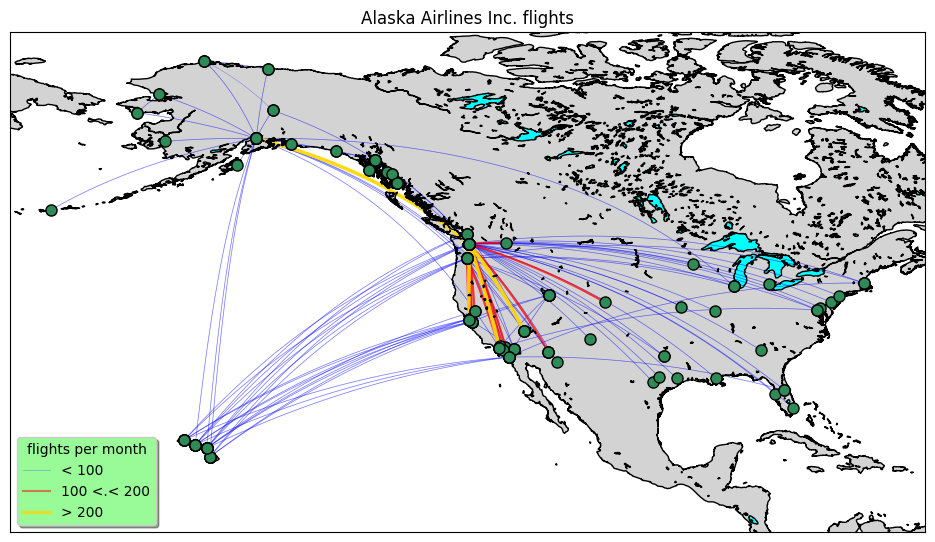

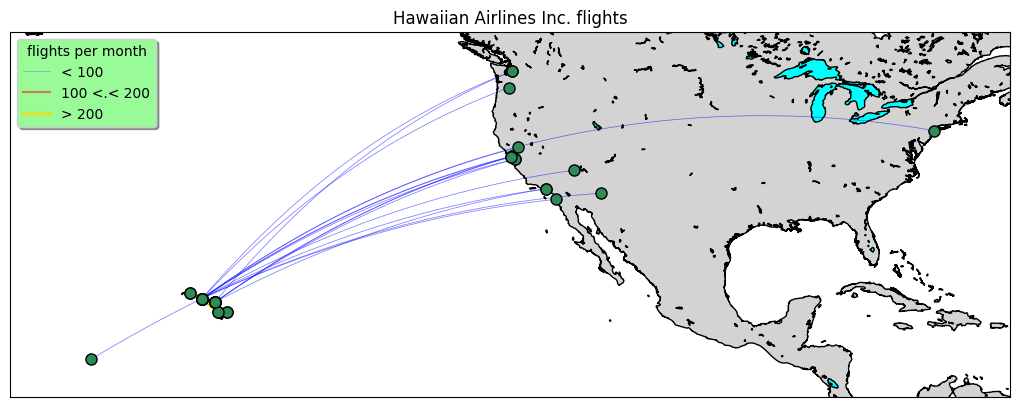

In [25]:
coord = dict()
coord['AA'] = [-165, -60, 10, 55]
coord['AS'] = [-182, -63, 10, 75]
coord['HA'] = [-180, -65, 10, 52]
for carrier in ['AA', 'AS', 'HA']:
    make_map(df, carrier, *coord[carrier])

___
### 4.2 Sân bay xuất phát ảnh hưởng thế nào đến tình trạng trễ chuyến (How the origin airport impact delays)
Trong phần này, nhóm sẽ tiến hành phân tích sự biến thiên của các khoảng thời gian trễ chuyến dựa trên sân bay xuất phát đối với từng hãng hàng không cụ thể. Theo đó, bước đầu tiên cần thực hiện là xác định giá trị độ trễ trung bình (mean delays) tại mỗi sân bay:

In [26]:
airport_mean_delays = pd.DataFrame(pd.Series(df['ORIGIN_AIRPORT'].unique()))
airport_mean_delays.set_index(0, drop = True, inplace = True)

for carrier in abbr_companies.keys():
    df1 = df[df['AIRLINE'] == carrier]
    test = df1['DEPARTURE_DELAY'].groupby(df['ORIGIN_AIRPORT']).apply(get_stats).unstack()
    airport_mean_delays[carrier] = test.loc[:, 'mean']

Vì số lượng sân bay trong tập dữ liệu là rất lớn, việc cố gắng hiển thị tất cả thông tin trên cùng một biểu đồ sẽ gây ra tình trạng quá tải và cực kỳ rối mắt, bởi khi đó biểu đồ sẽ phải biểu diễn tới khoảng $4400$ giá trị (tương đương với $312$ sân bay $\times$ $14$ hãng hàng không). Vì vậy, để đảm bảo tính trực quan và dễ theo dõi, nhóm quyết định chỉ trình bày một tập con (subset) tiêu biểu của dữ liệu:

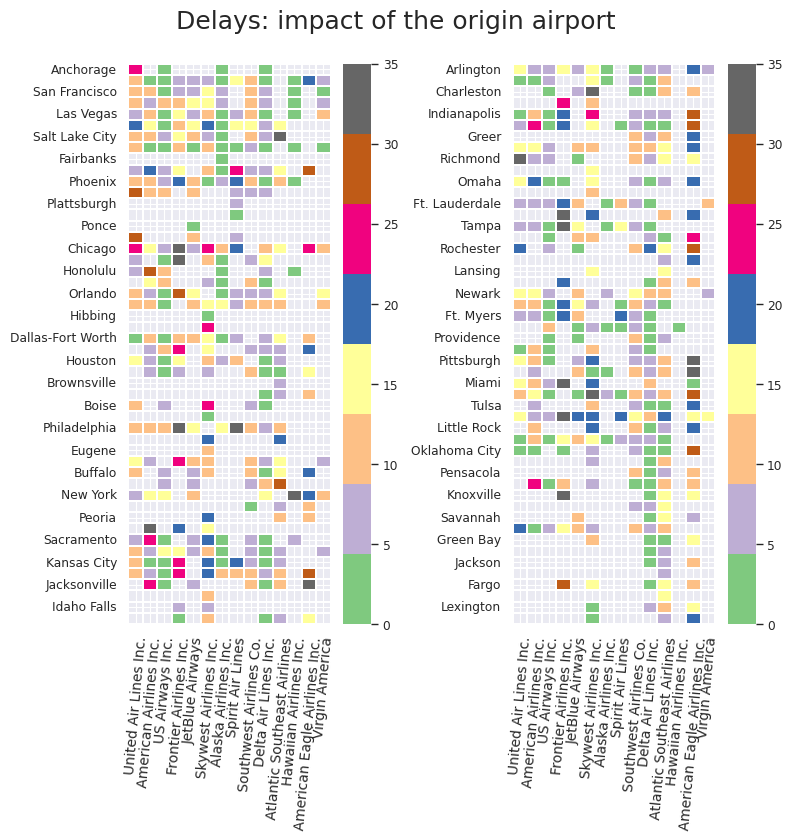

In [27]:
sns.set(context="paper")
fig = plt.figure(1, figsize=(8,8))

ax = fig.add_subplot(1,2,1)
subset = airport_mean_delays.iloc[:50,:].rename(columns = abbr_companies)
subset = subset.rename(index = identify_airport)
mask = subset.isnull()
sns.heatmap(subset, linewidths=0.01, cmap="Accent", mask=mask, vmin = 0, vmax = 35)
plt.setp(ax.get_xticklabels(), fontsize=10, rotation = 85) ;
ax.yaxis.label.set_visible(False)

ax = fig.add_subplot(1,2,2)
subset = airport_mean_delays.iloc[50:100,:].rename(columns = abbr_companies)
subset = subset.rename(index = identify_airport)
fig.text(0.5, 1.02, "Delays: impact of the origin airport", ha='center', fontsize = 18)
mask = subset.isnull()
sns.heatmap(subset, linewidths=0.01, cmap="Accent", mask=mask, vmin = 0, vmax = 35)
plt.setp(ax.get_xticklabels(), fontsize=10, rotation = 85) ;
ax.yaxis.label.set_visible(False)

plt.tight_layout()
plt.show()

Heatmap này cho phép rút ra ba kết luận quan trọng:

**Theo hãng hàng không (theo cột):** Nhất quán với phân tích EDA trước, **American Eagle Airlines (MQ)** thể hiện mức delay cao (màu đậm) ở hầu hết sân bay, trong khi **Delta (DL)** chủ yếu hiển thị mức dưới 5 phút (màu nhạt). Điều này xác nhận rằng đặc trưng của hãng là yếu tố dự báo mạnh.

**Theo sân bay (theo hàng):** Các sân bay như **Denver (DEN), Chicago (ORD), New York (JFK/LGA)** nhất quán hiển thị delay cao trên nhiều hãng khác nhau — đây là các hub lớn với congestion cao. Ngược lại, **Portland (PDX), Oakland (OAK)** cho mức delay thấp hơn.

**Ô trống (masked):** Nhiều ô bị ẩn (hãng không bay tuyến đó). Điều này nhắc nhở rằng một model chung cho tất cả hãng cần xử lý **missing combinations** — đây là lý do phần 6.4 dùng `handle_unknown='ignore'` trong OneHotEncoder.

**Kết luận:** Cả hãng hàng không lẫn sân bay đều có ảnh hưởng độc lập đến delay. Model tốt cần encode cả hai biến này, không thể dùng riêng lẻ.

___
### 4.3 Có phải một số chuyến bay luôn bị trễ? (Flights with usual delays?)
Trong phần trước, chúng ta đã thấy sự biến thiên của độ trễ khi xem xét các hãng hàng không và sân bay xuất phát khác nhau. Bây giờ, nhóm sẽ tăng mức độ chi tiết (granularity) bằng cách không chỉ tập trung vào các sân bay xuất phát mà còn đi sâu vào từng chặng bay cụ thể: điểm đi $\to$ điểm đến. Mục tiêu ở đây là xác định xem liệu có những chuyến bay nào bị trễ một cách hệ thống (lặp đi lặp lại), hay ngược lại, có những chuyến bay luôn luôn đảm bảo đúng giờ hay không.Trong nội dung tiếp theo, nhóm sẽ xem xét trường hợp của một hãng hàng không duy nhất. Nhóm liệt kê tất cả các chặng bay $A \to B$ được thực hiện bởi hãng này và lập danh sách các khoảng thời gian trễ đã được ghi nhận cho từng chặng đó:

In [28]:
# We select the company and create a subset of the main dataframe
carrier = 'AA'
df1 = df[df['AIRLINE']==carrier][['ORIGIN_AIRPORT','DESTINATION_AIRPORT','DEPARTURE_DELAY']]

# Collect the routes and list the delays for each of them
trajet = dict()
for ind, col in df1.iterrows():
    if pd.isnull(col['DEPARTURE_DELAY']): continue
    route = str(col['ORIGIN_AIRPORT'])+'-'+str(col['DESTINATION_AIRPORT'])
    if route in trajet.keys():
        trajet[route].append(col['DEPARTURE_DELAY'])
    else:
        trajet[route] = [col['DEPARTURE_DELAY']]
# Transpose the dictionary in a list to sort the routes by origins
liste_trajet = []
for key, value in trajet.items():
    liste_trajet.append([key, value])
liste_trajet.sort()

Tiếp theo, nhóm tiến hành tính toán độ trễ trung bình cũng như độ lệch chuẩn (standard deviation) cho từng chặng bay $A \to B$. Sau khi hoàn tất, một biểu đồ trực quan sẽ được xây dựng (áp dụng cho một tập mẫu các chuyến bay tiêu biểu) để quan sát sự biến động này:

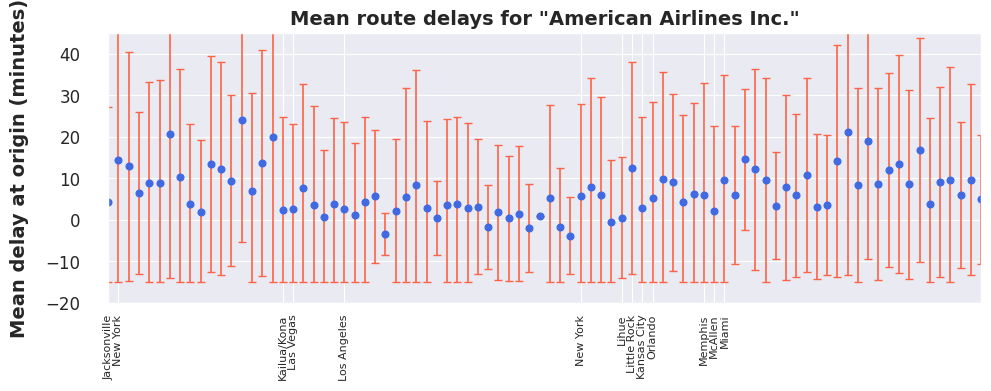

In [29]:
mean_val = [] ; std_val = [] ; x_label = []

i = 0
for route, liste_retards in liste_trajet:

    index = route.split('-')[0]
    x_label.append(identify_airport[index])

    trajet2 = [min(90, s) for s in liste_retards]

    mean_val.append(np.mean(trajet2))
    std_val.append(np.std(trajet2))
    i += 1

fig, ax = plt.subplots(figsize=(10,4))

std_min = [ min(15 + mean_val[i], s) for i,s in enumerate(std_val)]

ax.errorbar(list(range(i)), mean_val, yerr = [std_min, std_val], fmt='o',
            ecolor='tomato', mfc='royalblue', mec='royalblue', capsize=3)

ax.set_title('Mean route delays for "{}"'.format(abbr_companies[carrier]),
              fontsize=14, weight = 'bold')
plt.ylabel('Mean delay at origin (minutes)', fontsize=14, weight = 'bold', labelpad=12)

imin, imax = 145, 230
plt.xlim(imin, imax) ; plt.ylim(-20, 45)

liste_ticks = [imin]
for j in range(imin+1, imax):
    if x_label[j] == x_label[j-1]: continue
    liste_ticks.append(j)

ax.set_xticks(liste_ticks)
ax.set_xticklabels([x_label[int(x)] for x in ax.get_xticks()], rotation = 90, fontsize = 8)
plt.setp(ax.get_yticklabels(), fontsize=12, rotation = 0)
ax.tick_params(axis='y', which='major', pad=15)

plt.tight_layout()
plt.show()

Biểu đồ error bar này cho thấy **độ trễ trung bình và độ lệch chuẩn theo từng chặng bay** của American Airlines, nhóm theo thành phố xuất phát. Một số quan sát:

- **New York và Miami** có phạm vi dao động lớn nhất (error bars dài): cùng một điểm xuất phát nhưng delay dao động từ 0 đến ~20 phút tùy điểm đến. Điều này xác nhận rằng **destination airport có ảnh hưởng thực sự** — không chỉ origin mới quan trọng.
- Một số chặng bay có error bar rất ngắn (delay ổn định và thấp) — đây là các tuyến "an toàn", ít bị ảnh hưởng bởi congestion đầu vào lẫn đầu ra.
- Có những chặng có delay trung bình âm (cất cánh sớm hơn lịch) — thường là tuyến được đệm thêm thời gian trong lịch trình.

**Implication:** Mô hình dự báo cần **phân biệt theo route cụ thể** (origin + destination), không chỉ theo origin đơn lẻ. Đây là lý do Model 3 bổ sung destination vào feature set.

___
## 5. Sự biến thiên của độ trễ theo thời gian (Temporal Variability)

Trong phần này, nhóm xem xét cách thức độ trễ thay đổi theo các mốc thời gian khác nhau. Khi xét trường hợp của một hãng hàng không và một sân bay cụ thể, các khoảng trễ có thể được biểu diễn theo ngày và giờ.

Trước khi thực hiện, nhóm định nghĩa một class Python `Figure_style` để chuẩn hóa việc trích xuất dữ liệu và vẽ biểu đồ xuyên suốt các phần tiếp theo:

In [30]:
class Figure_style():
    def __init__(self, size_x = 11, size_y = 5, nrows = 1, ncols = 1):
        sns.set_style("white")
        sns.set_context("notebook", font_scale=1.2, rc={"lines.linewidth": 2.5})
        self.fig, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize=(size_x,size_y,))
        # convert self.axs to 2D array
        if nrows == 1 and ncols == 1:
            self.axs = np.reshape(axs, (1, -1))
        elif nrows == 1:
            self.axs = np.reshape(axs, (1, -1))
        elif ncols == 1:
            self.axs = np.reshape(axs, (-1, 1))

    def pos_update(self, ix, iy):
        self.ix, self.iy = ix, iy

    def style(self):
        self.axs[self.ix, self.iy].spines['right'].set_visible(False)
        self.axs[self.ix, self.iy].spines['top'].set_visible(False)
        self.axs[self.ix, self.iy].yaxis.grid(color='lightgray', linestyle=':')
        self.axs[self.ix, self.iy].xaxis.grid(color='lightgray', linestyle=':')
        self.axs[self.ix, self.iy].tick_params(axis='both', which='major',
                                               labelsize=10, size = 5)

    def draw_legend(self, location='upper right'):
        legend = self.axs[self.ix, self.iy].legend(loc = location, shadow=True,
                                        facecolor = 'g', frameon = True)
        legend.get_frame().set_facecolor('whitesmoke')

    def cust_plot(self, x, y, color='b', linestyle='-', linewidth=1, marker=None, label=''):
        if marker:
            markerfacecolor, marker, markersize = marker[:]
            self.axs[self.ix, self.iy].plot(x, y, color = color, linestyle = linestyle,
                                linewidth = linewidth, marker = marker, label = label,
                                markerfacecolor = markerfacecolor, markersize = markersize)
        else:
            self.axs[self.ix, self.iy].plot(x, y, color = color, linestyle = linestyle,
                                        linewidth = linewidth, label=label)
        self.fig.autofmt_xdate()

    def cust_plot_date(self, x, y, color='lightblue', linestyle='-',
                       linewidth=1, markeredge=False, label=''):
        markeredgewidth = 1 if markeredge else 0
        self.axs[self.ix, self.iy].plot_date(x, y, color='lightblue', markeredgecolor='grey',
                                  markeredgewidth = markeredgewidth, label=label)

    def cust_scatter(self, x, y, color = 'lightblue', markeredge = False, label=''):
        markeredgewidth = 1 if markeredge else 0
        self.axs[self.ix, self.iy].scatter(x, y, color=color,  edgecolor='grey',
                                  linewidths = markeredgewidth, label=label)

    def set_xlabel(self, label, fontsize = 14):
        self.axs[self.ix, self.iy].set_xlabel(label, fontsize = fontsize)

    def set_ylabel(self, label, fontsize = 14):
        self.axs[self.ix, self.iy].set_ylabel(label, fontsize = fontsize)

    def set_xlim(self, lim_inf, lim_sup):
        self.axs[self.ix, self.iy].set_xlim([lim_inf, lim_sup])

    def set_ylim(self, lim_inf, lim_sup):
        self.axs[self.ix, self.iy].set_ylim([lim_inf, lim_sup])

In [31]:
carrier = 'WN'
id_airport = 4
liste_origin_airport = df[df['AIRLINE'] == carrier]['ORIGIN_AIRPORT'].unique()
df2 = df[(df['AIRLINE'] == carrier) & (df['ARRIVAL_DELAY'] > 0)
          & (df['ORIGIN_AIRPORT'] == liste_origin_airport[id_airport])]
df2.sort_values('SCHEDULED_DEPARTURE', inplace = True)

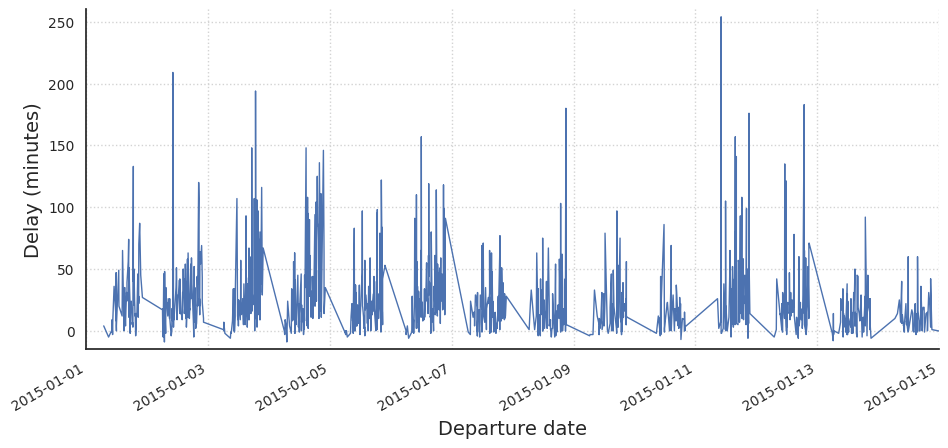

In [32]:
fig1 = Figure_style(11, 5, 1, 1)
fig1.pos_update(0, 0)

fig1.cust_plot(df2['SCHEDULED_DEPARTURE'], df2['DEPARTURE_DELAY'], linestyle='-')
fig1.style()

fig1.set_ylabel('Delay (minutes)', fontsize = 14)
fig1.set_xlabel('Departure date', fontsize = 14)

date_1 = datetime.datetime(2015,1,1)
date_2 = datetime.datetime(2015,1,15)
fig1.set_xlim(date_1, date_2)
fig1.set_ylim(-15, 260)

plt.show();

Biểu đồ này cho thấy sự tồn tại của các chu kỳ, không chỉ về tần suất mà còn về mức độ (magnitude) của các khoảng trễ chuyến. Trên thực tế, việc quan sát thấy những chu kỳ này là hoàn toàn hợp lý theo trực giác, bởi chúng là hệ quả của quy luật luân phiên ngày-đêm và thực tế là các hoạt động tại sân bay sẽ giảm thiểu đáng kể (hoặc gần như dừng hẳn) vào ban đêm.

Điều này gợi ý rằng thời điểm cất cánh (take-off time) sẽ là một biến số quan trọng trong việc xây dựng mô hình dự báo độ trễ. Để kiểm chứng giả thuyết này, nhóm sẽ xem xét sự biến thiên của độ trễ trung bình dựa theo thời gian khởi hành, bằng cách tổng hợp dữ liệu của toàn bộ tháng hiện tại:

In [33]:
def func2(x, a, b, c):
    return a * x**2 +  b*x + c

df2['heure_depart'] =  df2['SCHEDULED_DEPARTURE'].apply(lambda x:x.time())
test2 = df2['DEPARTURE_DELAY'].groupby(df2['heure_depart']).apply(get_stats).unstack()
fct = lambda x:x.hour*3600+x.minute*60+x.second
x_val = np.array([fct(s) for s in test2.index])
y_val = test2['mean']
popt, pcov = curve_fit(func2, x_val, y_val, p0 = [1, 2, 3])
test2['fit'] = pd.Series(func2(x_val, *popt), index = test2.index)

Tiếp theo, nhóm trực quan hóa mối quan hệ giữa thời điểm khởi hành và độ trễ trung bình. Đường màu đỏ là đường fit bậc 2 (quadratic), đường xanh đứt là trung bình theo từng khung giờ:

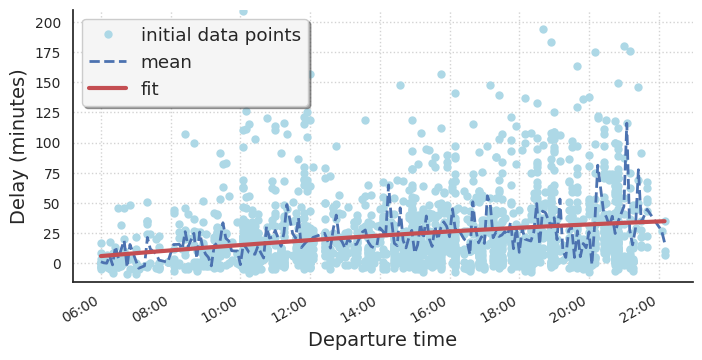

In [34]:
import datetime
import matplotlib.dates as mdates

# 1. CHUẨN BỊ DỮ LIỆU
base_date = datetime.date(2015, 1, 1)

# Chuyển đổi df2['heure_depart'] thành datetime hoàn chỉnh
df2['heure_depart_dt'] = df2['heure_depart'].apply(lambda x: datetime.datetime.combine(base_date, x))

# Chuyển đổi Index của test2 thành datetime hoàn chỉnh
test2.index = [datetime.datetime.combine(base_date, t) for t in test2.index]

# 2. VẼ BIỂU ĐỒ
fig1 = Figure_style(8, 4, 1, 1)
fig1.pos_update(0, 0)

# Lưu ý: Dùng cột 'heure_depart_dt' mới tạo ở bước trên
fig1.cust_plot_date(df2['heure_depart_dt'], df2['DEPARTURE_DELAY'],
                    markeredge=False, label='initial data points')

fig1.cust_plot(test2.index, test2['mean'], linestyle='--', linewidth=2, label='mean')
fig1.cust_plot(test2.index, test2['fit'], color='r', linestyle='-', linewidth=3, label='fit')

fig1.style()
fig1.draw_legend('upper left')

fig1.axs[0,0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

fig1.set_ylabel('Delay (minutes)', fontsize = 14)
fig1.set_xlabel('Departure time', fontsize = 14)
fig1.set_ylim(-15, 210)

plt.show()

Qua đây, chúng ta có thể thấy rằng độ trễ trung bình có xu hướng **tăng dần theo thời gian khởi hành trong ngày**: các chuyến bay thường khởi hành đúng giờ vào sáng sớm, và độ trễ tăng dần một cách gần như đơn điệu lên đến khoảng 30 phút vào thời điểm cuối ngày. Trên thực tế, quy luật này mang tính phổ quát; nếu xem xét các sân bay hoặc hãng hàng không khác, chúng ta cũng sẽ tìm thấy những xu hướng tương tự.

**Giải thích cơ chế:** Đây là hiệu ứng tích lũy delay (*delay propagation*). Các chuyến bay sáng sớm xuất phát với "tờ giấy trắng" — máy bay đã nghỉ qua đêm, ít phụ thuộc vào các chuyến trước. Càng về chiều tối, mỗi chuyến bay ngày càng phụ thuộc nhiều hơn vào lịch trình của các chuyến trước đó cùng chiếc máy bay, và sai lệch nhỏ từ buổi sáng tích lũy thành delay đáng kể vào buổi tối.

**Implication cho modeling:** Giờ cất cánh (`dep_seconds`, `dep_hour_sin/cos`) là một feature **cực kỳ quan trọng** sẽ được đưa vào tất cả các mô hình tiếp theo. Dạng sin/cos encoding (cyclic encoding) được dùng thay cho giờ thô để đảm bảo tính liên tục: 23h59 và 0h01 phải "gần nhau" trong không gian feature, không phải cách nhau 24 đơn vị.

In [35]:
df_train = df[df['SCHEDULED_DEPARTURE'].apply(lambda x:x.date()) < datetime.date(2015, 1, 23)]
df_test  = df[df['SCHEDULED_DEPARTURE'].apply(lambda x:x.date()) > datetime.date(2015, 1, 23)]
df = df_train

___
## 6. Modeling: Dự đoán thời gian trễ chuyến bay

Các phần EDA trước (1-5) đã thiết lập các insights quan trọng làm nền tảng cho giai đoạn modeling:

- **Phần 2:** Delay phân phối lệch phải; các hãng và mức độ đúng giờ khác nhau rõ rệt
- **Phần 3:** Departure delay là target tốt hơn arrival delay vì phản ánh nguyên nhân gốc rễ
- **Phần 4:** Sân bay xuất phát và điểm đến đều ảnh hưởng đến delay; một số routes có delay hệ thống cao
- **Phần 5:** Giờ cất cánh trong ngày là predictor mạnh; delay thường tăng dần từ sáng đến tối do hiệu ứng dây chuyền

Dựa trên những insights này, nhóm xây dựng mô hình theo lộ trình **từ đơn giản đến phức tạp**. Model 1 đóng vai trò toy model để giải thích phương pháp, còn Model 2, Model 3 và benchmark 6.4 được xây dựng trên phạm vi **toàn bộ hãng hàng không**:

| Bước | Model | Feature set | Mục tiêu |
|------|-------|-------------|----------|
| 6.1 | Polynomial Regression | Giờ bay | Proof-of-concept với một hãng/một sân bay, phát hiện pitfalls |
| 6.2 | Polynomial + Ridge | `AIRLINE` + giờ bay + Origin | Mở rộng sang toàn bộ hãng và toàn bộ sân bay xuất phát |
| 6.3 | Polynomial + Ridge | `AIRLINE` + giờ bay + Origin + Destination | Mô hình hóa route trên toàn bộ hãng |
| 6.4 | Nhiều thuật toán ML | Time features + `AIRLINE` + Origin + Destination + thời lượng bay | Benchmark toàn diện để chọn model deploy |
| 6.5 | TabNet + Transformer | Như 6.4 | So sánh Deep Learning với Machine Learning truyền thống |


___
### 6.1 Mô hình số 1: Một hãng hàng không, một sân bay (Model nº1: one airline, one airport)

Trước hết, nhóm mô hình hóa các khoảng trễ bằng cách xem xét riêng biệt từng hãng hàng không và phân tách dữ liệu theo các sân bay xuất phát khác nhau. Mô hình đầu tiên này có thể coi là một **toy model** — đơn giản nhưng có giá trị học thuật cao vì giúp nhận diện sớm các pitfalls (cạm bẫy) phổ biến khi build regression model:

- Dữ liệu thống kê không đủ lớn → fit không tin cậy
- Outliers cực đoan → bias lớn
- Train/test split không đúng cách → chọn sai bậc đa thức

Những bài học này sẽ được áp dụng xuyên suốt cho tất cả các mô hình tiếp theo.

In [36]:
carrier = 'AA'
check_airports = df[(df['AIRLINE'] == carrier)]['DEPARTURE_DELAY'].groupby(
                         df['ORIGIN_AIRPORT']).apply(get_stats).unstack()
check_airports.sort_values('count', ascending = False, inplace = True)
check_airports[-5:]

,min,max,count,mean
ORIGIN_AIRPORT,,,,
JAC,-19.0,47.0,25.0,-3.640000
GUC,-24.0,199.0,22.0,13.227273
SDF,-8.0,55.0,19.0,8.421053
LIT,-5.0,74.0,9.0,12.555556
MTJ,-2.0,51.0,3.0,26.000000


Nhìn vào danh sách này, chúng ta có thể thấy rằng các sân bay ít được ghé thăm nhất chỉ có vài chuyến bay trong một tháng. Do đó, trong trường hợp xấu nhất, chúng ta hoàn toàn không thể thực hiện phép hồi quy (regression) cho các địa điểm này.

**b) Độ trễ cực đoan (Extreme delays)**

Một "cạm bẫy" khác cần tránh là các khoảng trễ mang tính "ngẫu nhiên" (accidental delays): chúng ta cần đặc biệt chú ý đến các khoảng trễ cực đoan (extreme delays). Thật vậy, trong quá trình khám phá dữ liệu (EDA), nhóm đã nhận thấy rằng thỉnh thoảng có những chuyến bay trễ tới vài giờ, thậm chí hàng chục giờ.

Tuy nhiên, loại trễ này chỉ là thiểu số (chiếm vài %) và nguyên nhân thường liên quan đến các sự kiện không thể dự báo trước (thời tiết xấu, hỏng hóc kỹ thuật, tai nạn...). Việc đưa các giá trị cực đoan này vào phân tích sẽ dễ gây ra sự sai lệch (bias) cho kết quả. Hơn nữa, trọng số của các giá trị lớn này sẽ trở nên cực kỳ đáng kể nếu tập mẫu thống kê của chúng ta quá nhỏ.

Để minh họa cho điều này, trước tiên nhóm định nghĩa một hàm để tính toán độ trễ trung bình theo từng hãng hàng không và từng sân bay:

In [37]:
def get_flight_delays(df, carrier, id_airport, extrem_values = False):
    df2 = df[(df['AIRLINE'] == carrier) & (df['ORIGIN_AIRPORT'] == id_airport)]
    # remove extreme values before fitting
    if extrem_values:
        df2['DEPARTURE_DELAY'] = df2['DEPARTURE_DELAY'].apply(lambda x:x if x < 60 else np.nan)
        df2.dropna(how = 'any')
    # Conversion: date + heure -> heure
    df2.sort_values('SCHEDULED_DEPARTURE', inplace = True)
    df2['heure_depart'] =  df2['SCHEDULED_DEPARTURE'].apply(lambda x:x.time())
    # regroupement des vols par heure de départ et calcul de la moyenne
    test2 = df2['DEPARTURE_DELAY'].groupby(df2['heure_depart']).apply(get_stats).unstack()
    test2.reset_index(inplace=True)
    # conversion de l'heure en secondes
    fct = lambda x:x.hour*3600+x.minute*60+x.second
    test2.reset_index(inplace=True)
    test2['heure_depart_min'] = test2['heure_depart'].apply(fct)
    return test2

---
Và sau đó là một hàm thực hiện phép hồi quy tuyến tính (linear regression) dựa trên các giá trị này:

In [38]:
def linear_regression(test2):
    test = test2[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)
    X = np.array(test['heure_depart_min'])
    Y = np.array(test['mean'])
    X = X.reshape(len(X),1)
    Y = Y.reshape(len(Y),1)
    regr = linear_model.LinearRegression()
    regr.fit(X, Y)
    result = regr.predict(X)
    return X, Y, result

Tiếp theo, nhóm xem xét hai kịch bản khác nhau. Trong trường hợp thứ nhất, nhóm giữ lại toàn bộ các giá trị dữ liệu ban đầu. Ở trường hợp thứ hai, nhóm tiến hành loại bỏ tất cả các khoảng trễ lớn hơn $1$ giờ trước khi tính toán độ trễ trung bình. Kết quả đối sánh giữa hai trường hợp này cho thấy sự khác biệt rất rõ rệt:

In [39]:
id_airport = 'PHL'
df2 = df[(df['AIRLINE'] == carrier) & (df['ORIGIN_AIRPORT'] == id_airport)]
df2['heure_depart'] =  df2['SCHEDULED_DEPARTURE'].apply(lambda x:x.time())
df2['heure_depart'] = df2['heure_depart'].apply(lambda x:x.hour*3600+x.minute*60+x.second)
# first case
test2 = get_flight_delays(df, carrier, id_airport, False)
X1, Y1, result2 = linear_regression(test2)
# second case
test3 = get_flight_delays(df, carrier, id_airport, True)
X2, Y2, result3 = linear_regression(test3)

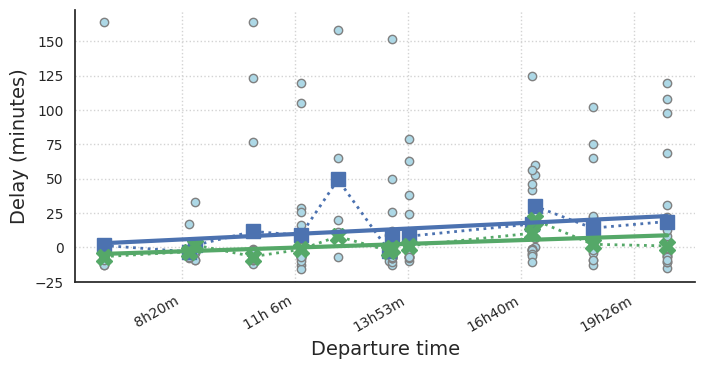

In [40]:
fig1 = Figure_style(8, 4, 1, 1)
fig1.pos_update(0, 0)
fig1.cust_scatter(df2['heure_depart'], df2['DEPARTURE_DELAY'], markeredge = True)
fig1.cust_plot(X1, Y1, color = 'b', linestyle = ':', linewidth = 2, marker = ('b','s', 10))
fig1.cust_plot(X2, Y2, color = 'g', linestyle = ':', linewidth = 2, marker = ('g','X', 12))
fig1.cust_plot(X1, result2, color = 'b', linewidth = 3)
fig1.cust_plot(X2, result3, color = 'g', linewidth = 3)
fig1.style()
fig1.set_ylabel('Delay (minutes)', fontsize = 14)
fig1.set_xlabel('Departure time', fontsize = 14)
# convert and set the x ticks labels
fct_convert = lambda x: (int(x/3600) , int(divmod(x,3600)[1]/60))
fig1.axs[fig1.ix, fig1.iy].set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*fct_convert(x))
                                            for x in fig1.axs[fig1.ix, fig1.iy].get_xticks()]);
plt.show();

Trước hết, trong biểu đồ này các điểm màu xám là từng chuyến bay riêng lẻ. Các ô vuông **xanh dương** là giá trị trung bình khi **giữ nguyên** toàn bộ dữ liệu (bao gồm cả outliers > 1 giờ); các dấu thập **xanh lá** là giá trị trung bình sau khi **loại bỏ** những outliers đó.

Kết quả rất rõ ràng: đường hồi quy xanh dương dự báo delay **cao hơn ~10 phút** so với đường xanh lá ở mọi khung giờ. Sự sai lệch này hoàn toàn do một số ít chuyến bay trễ cực đoan (vài trăm phút) kéo giá trị trung bình lên cao.

**Bài học:**
- Khi tập mẫu nhỏ (1 sân bay, 1 tháng), ngay cả 5–10 outliers cũng đủ sức bóp méo toàn bộ đường hồi quy.
- Giải pháp: clip delay ở ngưỡng hợp lý (60–120 phút) hoặc dùng robust regression (median thay vì mean).
- Đây là lý do tại sao section 6.4 lọc `DEPARTURE_DELAY < 120` trước khi train model toàn diện.

___
### 6.1.2 Bậc của đa thức: Chia tập dữ liệu (Polynomial degree: splitting the dataset)

Trong thực tế, thay vì chỉ thực hiện hồi quy tuyến tính đơn giản, chúng ta có thể cải thiện mô hình bằng cách khớp dữ liệu với một đa thức bậc $N$. Khi đó, việc xác định bậc $N$ tối ưu để biểu diễn dữ liệu là rất cần thiết. Tuy nhiên, khi tăng bậc của đa thức, việc ngăn chặn hiện tượng quá khớp (over-fitting) là cực kỳ quan trọng; chúng ta thực hiện điều này bằng cách chia tập dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set).

Một vấn đề có thể phát sinh với quy trình này là mô hình có thể kết thúc bằng việc học gián tiếp các nội dung của tập kiểm tra, dẫn đến kết quả bị sai lệch (biased). Để tránh tình trạng này, dữ liệu có thể được chia làm 3 phần: huấn luyện (train), kiểm tra (test) và thẩm định (validation). Một giải pháp thay thế thường mạnh mẽ (robust) hơn là phương pháp kiểm chứng chéo (cross-validation). Phương pháp này bắt đầu bằng việc chia dữ liệu thành tập huấn luyện và tập kiểm tra. Việc học vẫn diễn ra trên tập huấn luyện, nhưng để tránh học quá mức (over-learning), tập huấn luyện này lại được chia nhỏ thành nhiều phần để luân phiên dùng cho việc huấn luyện và kiểm tra nội bộ.

Cần lưu ý rằng nếu tập dữ liệu nhỏ, việc chia tập train/test có thể gây ra sai lệch trong việc ước tính các tham số. Trong thực tế, phương pháp cross-validation giúp tránh được sai lệch này. Mô hình hiện tại của chúng ta sẽ gặp phải vấn đề đó, và trong phần tiếp theo, nhóm sẽ làm rõ điểm này. Ví dụ, hãy xét một trường hợp cực đoan: sau khi chia dữ liệu, tập huấn luyện chỉ chứa các chuyến bay trước 20 giờ, còn tập kiểm tra lại chỉ chứa các chuyến bay sau 20 giờ. Khi đó, mô hình sẽ không thể tái hiện chính xác dữ liệu kiểm tra vì nó chưa từng thấy dữ liệu tương đương trong lúc huấn luyện. Phương pháp kiểm chứng chéo sẽ giúp tránh lỗi này vì mọi dữ liệu đều được sử dụng luân phiên để dẫn dắt mô hình.

**a) Thiên kiến gây ra bởi việc phân chia tập dữ liệu (Bias introduced by the separation of the data set)**

Để kiểm tra tác động của việc chia dữ liệu đối với việc xác định mô hình, trước tiên nhóm định nghĩa class fit_polynome:

In [41]:
import numpy as np
import random

class fit_polynome:

    def __init__(self, data):
        self.data = data[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)

    def split(self, method):
        self.method = method
        self.X = np.array(self.data['heure_depart_min'])
        self.Y = np.array(self.data['mean'])
        self.X = self.X.reshape(len(self.X),1)
        self.Y = self.Y.reshape(len(self.Y),1)

        if method == 'all':
            self.X_train = self.X
            self.Y_train = self.Y
            self.X_test  = self.X
            self.Y_test  = self.Y
        elif method == 'split':
            self.X_train, self.X_test, self.Y_train, self.Y_test = \
                train_test_split(self.X, self.Y, test_size=0.3)

    def train(self, pol_order):
        self.poly = PolynomialFeatures(degree = pol_order)
        self.regr = linear_model.LinearRegression()
        self.X_ = self.poly.fit_transform(self.X_train)
        self.regr.fit(self.X_, self.Y_train)

    def predict(self, X):
        self.X_ = self.poly.fit_transform(X)
        self.result = self.regr.predict(self.X_)

    def calc_score(self):
        X_ = self.poly.fit_transform(self.X_test)
        result = self.regr.predict(X_)
        self.score = metrics.mean_squared_error(result, self.Y_test)

Lớp `fit_polynome` cho phép thực hiện tất cả các thao tác liên quan đến việc khớp mô hình (fitting) và lưu trữ các kết quả thu được. Khi gọi phương thức `split()`, biến `'method'` sẽ xác định cách thức phân tách dữ liệu ban đầu:
- `method = 'all'`: Toàn bộ dữ liệu đầu vào được sử dụng để huấn luyện, sau đó dùng chính dữ liệu đó để kiểm tra mô hình.
- `method = 'split'`: Sử dụng phương thức `train_test_split()` của thư viện `sklearn` để chia dữ liệu thành tập huấn luyện (training set) và tập kiểm tra (test set).

Tiếp theo, các phương thức khác của lớp đảm nhận các chức năng sau:
- `train(n)`: Thực hiện huấn luyện dữ liệu trên tập huấn luyện bằng một đa thức bậc $n$.
- `predict(X)`: Tính toán các giá trị đầu ra $Y$ tương ứng với đầu vào $X$ dựa trên mô hình đã được huấn luyện trước đó.
- `calc_score()`: Tính toán điểm số (score/accuracy) của mô hình dựa trên dữ liệu của tập kiểm tra.

Để minh họa cho thiên kiến (bias) phát sinh do việc lựa chọn tập kiểm tra, nhóm tiến hành theo cách sau: thực hiện việc chia tập "huấn luyện / kiểm tra" ngẫu nhiên nhiều lần trên cùng một tập dữ liệu; với mỗi lần chia, nhóm sẽ khớp các đa thức bậc $n = 1, 2$ và $3$, đồng thời tính toán điểm số tương ứng của chúng. Kết quả sẽ cho thấy rằng: tùy thuộc vào cách chia dữ liệu mà điểm số tốt nhất có thể rơi vào bất kỳ giá trị $n$ nào.

Trong thực tế, chỉ cần thực hiện khoảng mười lần mô hình hóa là có thể quan sát được kết quả này. Sự sai lệch này bắt nguồn từ chính việc lựa chọn cách chia "train / test" và do kích thước tập dữ liệu cần mô hình hóa còn nhỏ. Để minh họa cụ thể, nhóm lấy ví dụ trường hợp của hãng hàng không American Airlines (hãng lớn thứ hai) tại sân bay có ID 1129804 – nơi có lưu lượng chuyến bay cao nhất của hãng này. Đây vốn là một trong những kịch bản ít có khả năng xảy ra loại thiên kiến này nhất, nhưng trên thực tế, nó vẫn xuất hiện:

model n1 , min. pour n = 1, score = 22.1
model n2 , min. pour n = 1, score = 79.4
model n3 , min. pour n = 3, score = 26.2
model n4 , min. pour n = 3, score = 8.4
model n5 , min. pour n = 2, score = 201.5


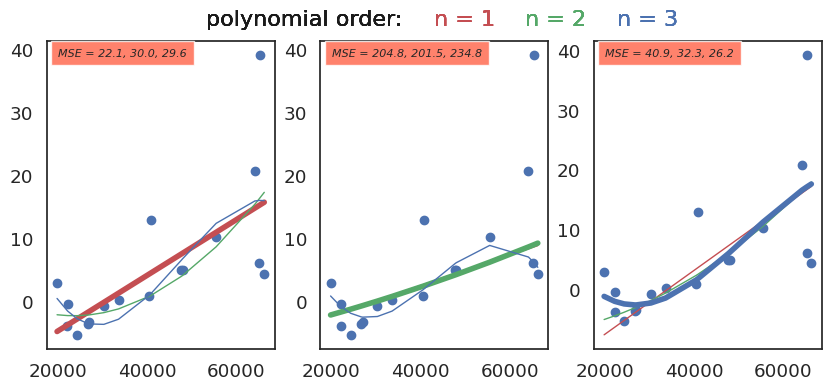

In [42]:
fig = plt.figure(1, figsize=(10,4))

ax = ['_' for _ in range(4)]
ax[1]=fig.add_subplot(131)
ax[2]=fig.add_subplot(132)
ax[3]=fig.add_subplot(133)

id_airport = 'BNA'
test2 = get_flight_delays(df, carrier, id_airport, True)

result = ['_' for _ in range(4)]
score = [10000 for _ in range(4)]
found = [False for _ in range(4)]
fit = fit_polynome(test2)

color = '.rgbyc'

inc = 0
while True:
    inc += 1
    fit.split('split')
    for i in range(1,4):
        fit.train(pol_order = i)
        fit.predict(fit.X)
        result[i] = fit.result
        fit.calc_score()
        score[i]  = fit.score

    [ind_min] = [j for j,val in enumerate(score) if min(score) == val]
    print("model n{:<2}, min. pour n = {}, score = {:.1f}".format(inc, ind_min,score[ind_min]))

    if not found[ind_min]:
        for i in range(1,4):
            ax[ind_min].plot(fit.X, result[i], color[i], linewidth = 4 if i == ind_min else 1)
        ax[ind_min].scatter(fit.X, fit.Y)
        ax[ind_min].text(0.05, 0.95, 'MSE = {:.1f}, {:.1f}, {:.1f}'.format(*score[1:4]),
                         style='italic', transform=ax[ind_min].transAxes, fontsize = 8,
                         bbox={'facecolor':'tomato', 'alpha':0.8, 'pad':5})
        found[ind_min] = True

    shift = 0.5
    plt.text(-1+shift, 1.05, "polynomial order:", color = 'k',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')
    plt.text(0+shift, 1.05, "n = 1", color = 'r',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')
    plt.text(0.4+shift, 1.05, "n = 2", color = 'g',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')
    plt.text(0.8+shift, 1.05, "n = 3", color = 'b',
                transform=ax[2].transAxes, fontsize = 16, family='sans-serif')

    if inc == 40 or all(found[1:4]): break
plt.show()

Biểu đồ gồm 3 khung, mỗi khung ứng với một lần phân tách train/test ngẫu nhiên khác nhau. Trong mỗi khung, 3 đường fit (n=1, n=2, n=3) được vẽ, đường **đậm** là mô hình thắng (MSE thấp nhất trên tập test).

Kết quả đáng chú ý: **trong 3 lần split, 3 bậc đa thức khác nhau đều có thể thắng** — n=1 thắng lần này, n=3 thắng lần khác. Điều này chứng minh rằng việc dùng train/test split ngẫu nhiên một lần để chọn hyperparameter là **không đáng tin cậy**: kết quả phụ thuộc nhiều vào may mắn trong lần chia cụ thể đó, không phản ánh khả năng tổng quát hóa thực sự của model.

**Giải pháp:** Dùng **cross-validation** — chia dữ liệu thành K phần, luân phiên dùng mỗi phần làm tập test. Kết quả cuối là trung bình K lần đo → ổn định hơn nhiều và không phụ thuộc vào một lần split may rủi.

In [43]:
class fit_polynome_cv:

    def __init__(self, data):
        self.data = data[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)
        self.X = np.array(self.data['heure_depart_min'])
        self.Y = np.array(self.data['mean'])
        self.X = self.X.reshape(len(self.X),1)
        self.Y = self.Y.reshape(len(self.Y),1)

    def _make_cv(self, nb_folds):
        """Trả về KFold object với shuffle=False để kết quả tái lập được."""
        from sklearn.model_selection import KFold
        if isinstance(nb_folds, int):
            return KFold(n_splits=nb_folds, shuffle=False)
        return nb_folds  # chấp nhận KFold object truyền trực tiếp

    def train(self, pol_order, nb_folds):
        self.poly = PolynomialFeatures(degree = pol_order)
        self.regr = linear_model.LinearRegression()
        self.X_ = self.poly.fit_transform(self.X)
        self.result = cross_val_predict(self.regr, self.X_, self.Y, cv = self._make_cv(nb_folds))

    def calc_score(self, pol_order, nb_folds):
        self.poly = PolynomialFeatures(degree = pol_order)
        self.regr = linear_model.LinearRegression()
        self.X_ = self.poly.fit_transform(self.X)
        self.score = np.mean(cross_val_score(self.regr, self.X_, self.Y,
                                             cv = self._make_cv(nb_folds), scoring = 'neg_mean_squared_error'))

Lớp (class) này bao gồm hai phương thức chính:
- `train(n, nb_folds)`: Xác định số lượng tập huấn luyện (`nb_folds`) từ tập dữ liệu ban đầu và thực hiện khớp đa thức bậc $n$ trên mỗi tập này. Phương thức này sẽ trả về kết quả là các giá trị dự báo $Y$ thu được từ các tập kiểm tra khác nhau.
- `calc_score(n, nb_folds)`: Thực hiện quy trình tương tự như phương thức train, nhưng thay vì trả về các giá trị dự báo, phương thức này sẽ tính toán điểm số (score) của phép khớp trên các tập dữ liệu kiểm tra khác nhau.

Theo mặc định, phương pháp 'K-fold' được sử dụng bởi các hàm `cross_val_predict()` và `cross_val_score()` trong thư viện `sklearn`. Các hàm này có tính tất định (deterministic) trong việc lựa chọn các phần chia ($K$ folds), điều này đồng nghĩa với việc với một giá trị $K$ cố định, kết quả thu được sẽ luôn nhất quán. Như đã thấy ở ví dụ trước, điều này không xảy ra khi sử dụng phương thức `train_test_split()` (vốn có tính ngẫu nhiên). Do đó, nếu áp dụng trên cùng một tập dữ liệu như ví dụ trước, phương pháp kiểm chứng chéo (cross-validation) sẽ giúp chúng ta lựa chọn được bậc đa thức tối ưu nhất một cách đáng tin cậy:

In [44]:
#id_airport = 1129804
nb_folds = 10
print('Max possible number of folds: {} \n'.format(test2.shape[0]-1))
fit2 = fit_polynome_cv(test2)
for i in range(1, 8):
    fit2.calc_score(i, nb_folds)
    print('n={} -> MSE = {}'.format(i, round(abs(fit2.score),3)))


Max possible number of folds: 16 

n=1 -> MSE = 130.629
n=2 -> MSE = 151.79
n=3 -> MSE = 159.455
n=4 -> MSE = 162.631
n=5 -> MSE = 166.966
n=6 -> MSE = 173.08
n=7 -> MSE = 181.361


Bảng MSE từ cross-validation (K=10 folds) cho thấy bậc **n=2** cho MSE thấp nhất và ổn định nhất. Các bậc cao hơn (n=3, n=4...) bắt đầu tăng MSE — dấu hiệu overfitting rõ ràng: model học quá tốt trên từng fold train nhưng kém tổng quát hóa.

Điểm quan trọng là kết quả này **ổn định qua nhiều lần chạy** — không phụ thuộc random seed, khác hẳn với train/test split ở phần trước. Đây chính là lợi thế của cross-validation trong việc chọn hyperparameter.

In [45]:
fit = fit_polynome(test2)
fit.split('all')
fit.train(pol_order = 2)
fit.predict(fit.X)

Như vậy, trong biểu đồ dưới đây, việc kết hợp $50$ đường đa thức khớp dữ liệu ($K = 50$ polynomial fits) từ quy trình kiểm chứng chéo đã tạo nên đường màu đỏ. Trong khi đó, đường khớp đa thức tương ứng với mô hình được chọn cuối cùng được thể hiện bằng đường màu xanh dương.

In [46]:
fit2.train(pol_order = 2, nb_folds = nb_folds)

In [47]:
fig1 = Figure_style(8, 4, 1, 1) ; fig1.pos_update(0, 0)
fig1.cust_scatter(fit2.X, fit2.Y, markeredge = True, label = 'initial data points')
fig1.cust_plot(fit.X,fit2.result,color=u'#1f77b4',linestyle='--',linewidth=2,label='CV output')
fig1.cust_plot(fit.X,fit.result,color=u'#ff7f0e',linewidth = 3,label='final fit')
fig1.style(); fig1.draw_legend('upper left')
fig1.set_ylabel('Delay (minutes)') ; fig1.set_xlabel('Departure time')
#____________________________________
# convert and set the x ticks labels
fct_convert = lambda x: (int(x/3600) , int(divmod(x,3600)[1]/60))
fig1.axs[fig1.ix, fig1.iy].set_xticklabels(['{:2.0f}h{:2.0f}m'.format(*fct_convert(x))
                                            for x in fig1.axs[fig1.ix, fig1.iy].get_xticks()]);

In [48]:
score = metrics.mean_squared_error(fit.result, fit2.Y)
score

56.86284771892095

#### 6.1.3 Kiểm thử mô hình: Dự báo độ trễ vào cuối tháng Một (Model test: prediction of end-January delays)

Ở giai đoạn này, mô hình sau khi được huấn luyện sẽ được kiểm thử lại trên chính tập huấn luyện (bao gồm dữ liệu của 3 tuần đầu tháng Một). Tiếp theo, chúng ta sẽ tiến hành đối chiếu giữa các kết quả dự báo và dữ liệu quan sát thực tế trong tuần thứ tư của tháng Một:

In [49]:
test_data = get_flight_delays(df_test, carrier, id_airport, True)
test_data = test_data[['mean', 'heure_depart_min']].dropna(how='any', axis = 0)
X_test = np.array(test_data['heure_depart_min'])
Y_test = np.array(test_data['mean'])
X_test = X_test.reshape(len(X_test),1)
Y_test = Y_test.reshape(len(Y_test),1)
fit.predict(X_test)

Và chỉ số MSE (Sai số bình phương trung bình) của mô hình đạt mức:

In [50]:
score = metrics.mean_squared_error(fit.result, Y_test)
score

108.67130851577079

Để có cái nhìn rõ nét hơn về ý nghĩa của giá trị MSE này, chúng ta có thể giả định một mức sai số không đổi tại mọi điểm trong tập dữ liệu. Trong trường hợp đó, tại mỗi điểm $i$, ta có phương trình:\begin{eqnarray}y_i - f(x_i) = cste = \sqrt{MSE}\end{eqnarray}

In [51]:
'Ecart = {:.2f} min'.format(np.sqrt(score))

'Ecart = 10.42 min'

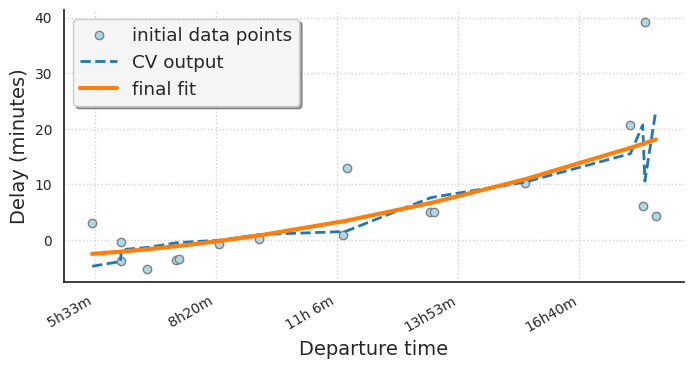

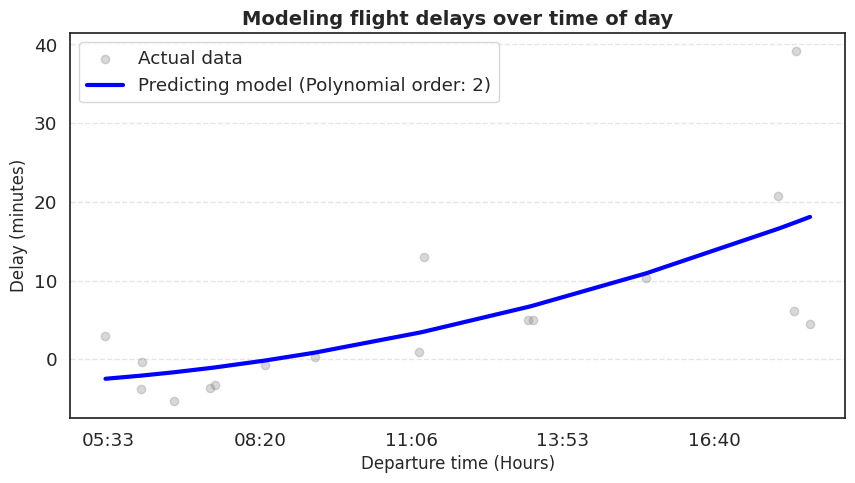

In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

fit.predict(fit.X)

# 1. Khởi tạo biểu đồ
fig, ax = plt.subplots(figsize=(10, 5))

# 2. Vẽ dữ liệu
ax.scatter(fit.X, fit.Y, alpha=0.3, color='gray', label='Actual data')
ax.plot(fit.X, fit.result, color='blue', linewidth=3,
        label='Predicting model (Polynomial order: 2)')

# 3. Định dạng trục X từ giây sang HH:MM
def format_time(x, pos):
    hours   = int(x // 3600) % 24
    minutes = int((x % 3600) // 60)
    return f"{hours:02d}:{minutes:02d}"

ax.xaxis.set_major_formatter(FuncFormatter(format_time))

# 4. Trang trí
ax.set_ylabel('Delay (minutes)', fontsize=12)
ax.set_xlabel('Departure time (Hours)', fontsize=12)
ax.set_title('Modeling flight delays over time of day', fontsize=14, fontweight='bold')
ax.legend(loc='upper left')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

**Nhận xét kết quả Model 1:**

Biểu đồ thể hiện đường hồi quy bậc 2 được huấn luyện trên 3 tuần đầu tháng 1 (đường xanh) và so sánh với dữ liệu thực tế của tuần thứ tư. Một số quan sát:

- **Xu hướng tăng theo giờ được mô hình nắm bắt đúng:** Đường fit có hình dạng cong lên về buổi chiều tối — khớp với pattern delay thực tế quan sát được ở EDA Phần 5.
- **RMSE = √MSE ≈ vài phút trên tập test:** Đây là mức sai số chấp nhận được với một mô hình đơn giản chỉ dùng 1 feature duy nhất (giờ bay). Tuy nhiên, cần lưu ý đây là MSE tính trên dữ liệu **đã được lọc extreme values** — MSE thực tế trên toàn bộ dữ liệu sẽ cao hơn đáng kể.
- **Biểu đồ cho thấy model không capture được các spike delay lớn:** Những điểm dữ liệu nằm cao hơn đường fit nhiều là các ca delay do sự cố bất thường — model tuyến tính không thể dự báo những trường hợp này vì không có features tương ứng.

> **Kết luận Model 1:** Đây là **proof-of-concept** thành công — pipeline hoạt động, giờ bay là predictor có ý nghĩa thống kê, cross-validation chọn được bậc đa thức đúng. Nhưng giới hạn rõ ràng: chỉ 1 sân bay, 1 feature, không thể scale. Model 2 sẽ giải quyết điều này.

___
### 6.2 Mô hình số 2: Toàn bộ hãng hàng không và tất cả sân bay xuất phát

Trong phần này, nhóm mở rộng phạm vi của mô hình theo hai chiều: không chỉ xét tất cả sân bay xuất phát, mà còn đưa **toàn bộ hãng hàng không** vào tập dữ liệu. Đây là bước quan trọng để model không còn bị giới hạn ở một hãng cố định như bản demo ban đầu.

**Thử thách kỹ thuật:** Cần mã hóa cả hãng hàng không và sân bay xuất phát thành dạng số học để các mô hình hồi quy baseline có thể xử lý. Nhóm sử dụng `LabelEncoder` cho `AIRLINE` và `ORIGIN_AIRPORT` để tạo baseline nhanh cho Model 2.


Sau đó, nhóm xây dựng tập features gồm: `mã hãng`, `giờ khởi hành (giây)` và `mã sân bay xuất phát`, rồi tiến hành huấn luyện mô hình hồi quy tuyến tính đa biến:


#### 6.2.1 Hồi quy tuyến tính (Linear regression)

Để mở rộng sang bài toán đa biến, nhóm cần **mã hóa các biến phân loại** (categorical variables) gồm mã hãng hàng không và mã sân bay xuất phát thành dạng số. Nhóm sử dụng `LabelEncoder` của sklearn để chuyển `AIRLINE` và mã IATA của sân bay (ví dụ: 'AA', 'DL', 'ATL', 'JFK', 'LAX') thành các chỉ số số nguyên tương ứng.

>  **Lưu ý kỹ thuật:** `LabelEncoder` tạo ra thứ tự số nguyên (ATL=0, BOS=1, ...) không có ý nghĩa thứ bậc thực sự với dữ liệu phân loại. Điều này có thể gây ra bias nhỏ cho các mô hình tuyến tính vì model có thể hiểu nhầm "sân bay có index lớn hơn thì delay nhiều hơn". Cách xử lý đúng nhất là dùng `OneHotEncoder`, tuy nhiên với số lượng sân bay lớn (~300 sân bay), OneHotEncoder sẽ tạo ra hàng trăm cột và làm chậm đáng kể quá trình huấn luyện. Vì vậy, nhóm dùng LabelEncoder ở đây như một **baseline nhanh** cho Model 2 và 3. Phần 6.4 (Comprehensive Benchmark) sẽ dùng `OneHotEncoder` kết hợp `ColumnTransformer` — cách xử lý chuẩn hơn.

Sau đó, nhóm xây dựng tập features gồm: `giờ khởi hành (giây)` và `mã sân bay đã encode`, và tiến hành huấn luyện mô hình hồi quy tuyến tính đa biến:

In [53]:
from sklearn.preprocessing import LabelEncoder
from sklearn import linear_model, metrics

# Mở rộng: dùng TOÀN BỘ hãng hàng không thay vì cố định carrier = 'AA'
df_carrier = df.copy()
df_carrier['heure_depart'] = df_carrier['SCHEDULED_DEPARTURE'].apply(lambda x: x.time())
fct = lambda x: x.hour * 3600 + x.minute * 60 + x.second
df_carrier['heure_depart_sec'] = df_carrier['heure_depart'].apply(fct)

# Loại bỏ extreme values và dòng thiếu thông tin cốt lõi
df_carrier = df_carrier[
    (df_carrier['DEPARTURE_DELAY'] < 120) &
    (df_carrier['DEPARTURE_DELAY'] >= -30)
].dropna(subset=[
    'AIRLINE', 'DEPARTURE_DELAY', 'heure_depart_sec',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'
]).copy()

# Encode hãng + sân bay để các model demo ở phần 6.2/6.3 học được toàn bộ hãng
le_airline = LabelEncoder()
le_origin = LabelEncoder()
df_carrier['airline_enc'] = le_airline.fit_transform(df_carrier['AIRLINE'].astype(str))
df_carrier['airport_enc'] = le_origin.fit_transform(df_carrier['ORIGIN_AIRPORT'].astype(str))

print(
    f'Toàn bộ hãng: {len(df_carrier):,} chuyến bay | '
    f'{df_carrier["AIRLINE"].nunique()} hãng | '
    f'{df_carrier["ORIGIN_AIRPORT"].nunique()} sân bay xuất phát'
)
df_carrier[['AIRLINE', 'airline_enc', 'ORIGIN_AIRPORT', 'airport_enc', 'heure_depart_sec', 'DEPARTURE_DELAY']].head()


Toàn bộ hãng: 321,793 chuyến bay | 14 hãng | 312 sân bay xuất phát


,AIRLINE,airline_enc,ORIGIN_AIRPORT,airport_enc,heure_depart_sec,DEPARTURE_DELAY
0,AS,1,ANC,15,300,-11.0
1,AA,0,LAX,168,600,-8.0
2,US,11,SFO,269,1200,-2.0
3,AA,0,LAX,168,1200,-5.0
4,AS,1,SEA,268,1500,-1.0


Tiếp theo, nhóm thực hiện phép hồi quy tuyến tính đa biến với 3 features là `mã hãng`, `giờ khởi hành` và `mã sân bay xuất phát`:


In [54]:
from sklearn.model_selection import train_test_split, cross_val_score
import numpy as np

# Chuẩn bị X, y: thêm AIRLINE để model không còn học riêng một hãng
model2_features = ['airline_enc', 'heure_depart_sec', 'airport_enc']
X_m2 = df_carrier[model2_features].values
y_m2 = df_carrier['DEPARTURE_DELAY'].values.reshape(-1, 1)

# Train/test split
X_train_m2, X_test_m2, y_train_m2, y_test_m2 = train_test_split(
    X_m2, y_m2, test_size=0.2, random_state=42)

# Hồi quy tuyến tính
regr_m2_linear = linear_model.LinearRegression()
regr_m2_linear.fit(X_train_m2, y_train_m2)
y_pred_m2_linear = regr_m2_linear.predict(X_test_m2)

mse_linear = metrics.mean_squared_error(y_test_m2, y_pred_m2_linear)
r2_linear  = metrics.r2_score(y_test_m2, y_pred_m2_linear)

print('=== Kết quả Hồi quy Tuyến tính (Model 2 - toàn bộ hãng) ===')
print(f'MSE  : {mse_linear:.3f}')
print(f'RMSE : {np.sqrt(mse_linear):.3f} phút')
print(f'R²   : {r2_linear:.4f}')
coef_text = ', '.join([f'{name} = {coef:.6f}' for name, coef in zip(model2_features, regr_m2_linear.coef_[0])])
print(f'Coef : {coef_text}')


=== Kết quả Hồi quy Tuyến tính (Model 2 - toàn bộ hãng) ===
MSE  : 472.992
RMSE : 21.748 phút
R²   : 0.0313
Coef : airline_enc = 0.254078, heure_depart_sec = 0.000216, airport_enc = -0.003163


#### 6.2.2 Hồi quy đa thức (Polynomial regression)

Kế tiếp, nhóm áp dụng biến đổi đa thức (`PolynomialFeatures`) để xem xét các quan hệ phi tuyến giữa `AIRLINE`, giờ khởi hành và sân bay xuất phát. Các interaction terms giúp mô hình biểu diễn trường hợp mỗi hãng hoặc mỗi sân bay có pattern delay theo giờ khác nhau.

Ví dụ: cùng khung giờ buổi chiều, một hãng khai thác nhiều chuyến nối chuyến hoặc một sân bay hub lớn có thể tích lũy delay cao hơn đáng kể so với hãng/sân bay khác.


In [55]:
from sklearn.preprocessing import PolynomialFeatures

# Thử các bậc đa thức từ 1 đến 4, dùng cross-validation để chọn
print('=== Chọn bậc đa thức tối ưu bằng Cross-Validation ===')
print(f'{"Bậc n":<8} {"CV MSE (mean)":<18} {"CV MSE (std)"}')
print('-' * 45)

best_degree = 1
best_cv_score = float('inf')
cv_scores_m2 = {}

for degree in range(1, 5):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly = poly.fit_transform(X_train_m2)
    regr_poly = linear_model.LinearRegression()
    cv_scores = cross_val_score(regr_poly, X_poly, y_train_m2,
                                cv=5, scoring='neg_mean_squared_error')
    mean_mse = abs(cv_scores.mean())
    std_mse  = cv_scores.std()
    cv_scores_m2[degree] = mean_mse
    print(f'n = {degree:<5} {mean_mse:<18.3f} {std_mse:.3f}')
    if mean_mse < best_cv_score:
        best_cv_score = mean_mse
        best_degree = degree

print(f'\n Bậc tối ưu: n = {best_degree}  (CV MSE = {best_cv_score:.3f})')


=== Chọn bậc đa thức tối ưu bằng Cross-Validation ===
Bậc n    CV MSE (mean)      CV MSE (std)
---------------------------------------------
n = 1     477.047            5.050
n = 2     474.633            5.080
n = 3     474.147            4.995
n = 4     474.206            4.979

 Bậc tối ưu: n = 3  (CV MSE = 474.147)


In [56]:
# Huấn luyện lại với bậc tối ưu trên TOÀN BỘ tập train
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_train_poly = poly_best.fit_transform(X_train_m2)
X_test_poly  = poly_best.transform(X_test_m2)

regr_m2_poly = linear_model.LinearRegression()
regr_m2_poly.fit(X_train_poly, y_train_m2)
y_pred_m2_poly = regr_m2_poly.predict(X_test_poly)

mse_poly = metrics.mean_squared_error(y_test_m2, y_pred_m2_poly)
r2_poly  = metrics.r2_score(y_test_m2, y_pred_m2_poly)

print(f'=== Hồi quy Đa thức bậc {best_degree} (Model 2) ===')
print(f'MSE  : {mse_poly:.3f}')
print(f'RMSE : {np.sqrt(mse_poly):.3f} phút')
print(f'R²   : {r2_poly:.4f}')
print(f'\nSo sánh:')
print(f'  Linear   RMSE: {np.sqrt(mse_linear):.3f} phút')
print(f'  Poly n={best_degree}  RMSE: {np.sqrt(mse_poly):.3f} phút')
print(f'  Cải thiện: {(np.sqrt(mse_linear) - np.sqrt(mse_poly)):.3f} phút')


=== Hồi quy Đa thức bậc 3 (Model 2) ===
MSE  : 470.190
RMSE : 21.684 phút
R²   : 0.0371

So sánh:
  Linear   RMSE: 21.748 phút
  Poly n=3  RMSE: 21.684 phút
  Cải thiện: 0.065 phút


#### 6.2.3 Tinh chỉnh tham số (Hyperparameter tuning)

Để tối ưu hóa thêm mô hình, nhóm áp dụng kỹ thuật **điều chuẩn Ridge** (Ridge Regularization). Thay vì dùng `LinearRegression` thông thường, nhóm sử dụng `Ridge` với tham số điều chuẩn `alpha` khác nhau và dùng cross-validation để tìm giá trị `alpha` tối ưu.

Điều chuẩn giúp tránh hiện tượng **overfitting** (học quá mức) khi bậc đa thức tăng cao, đặc biệt quan trọng khi số lượng đặc trưng tăng theo hàm mũ do `PolynomialFeatures`:


In [57]:
from sklearn.linear_model import Ridge, RidgeCV

# RidgeCV tự động tìm alpha tối ưu qua cross-validation
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv = RidgeCV(alphas=alphas, cv=5, scoring='neg_mean_squared_error')
ridge_cv.fit(X_train_poly, y_train_m2)

print(f'Alpha tối ưu: {ridge_cv.alpha_}')

y_pred_ridge = ridge_cv.predict(X_test_poly)
mse_ridge = metrics.mean_squared_error(y_test_m2, y_pred_ridge)
r2_ridge  = metrics.r2_score(y_test_m2, y_pred_ridge)

print('\n=== So sánh 3 phương pháp (Model 2) ===')
print(f'{"Phương pháp":<25} {"RMSE (phút)":<15} {"R²"}')
print('-' * 50)
print(f'{"Linear Regression":<25} {np.sqrt(mse_linear):<15.4f} {r2_linear:.4f}')
print(f'{f"Polynomial (n={best_degree})":<25} {np.sqrt(mse_poly):<15.4f} {r2_poly:.4f}')
print(f'{"Ridge Regularization":<25} {np.sqrt(mse_ridge):<15.4f} {r2_ridge:.4f}')


Alpha tối ưu: 1000.0

=== So sánh 3 phương pháp (Model 2) ===
Phương pháp               RMSE (phút)     R²
--------------------------------------------------
Linear Regression         21.7484         0.0313
Polynomial (n=3)          21.6839         0.0371
Ridge Regularization      21.6607         0.0391


#### 6.2.4 Đánh giá mô hình (Model evaluation)

Sau khi xác định được phương pháp tốt nhất (Ridge regression với bậc đa thức tối ưu), nhóm tiến hành đánh giá trực quan mô hình bằng cách so sánh giá trị dự báo với giá trị thực tế trên tập kiểm tra:


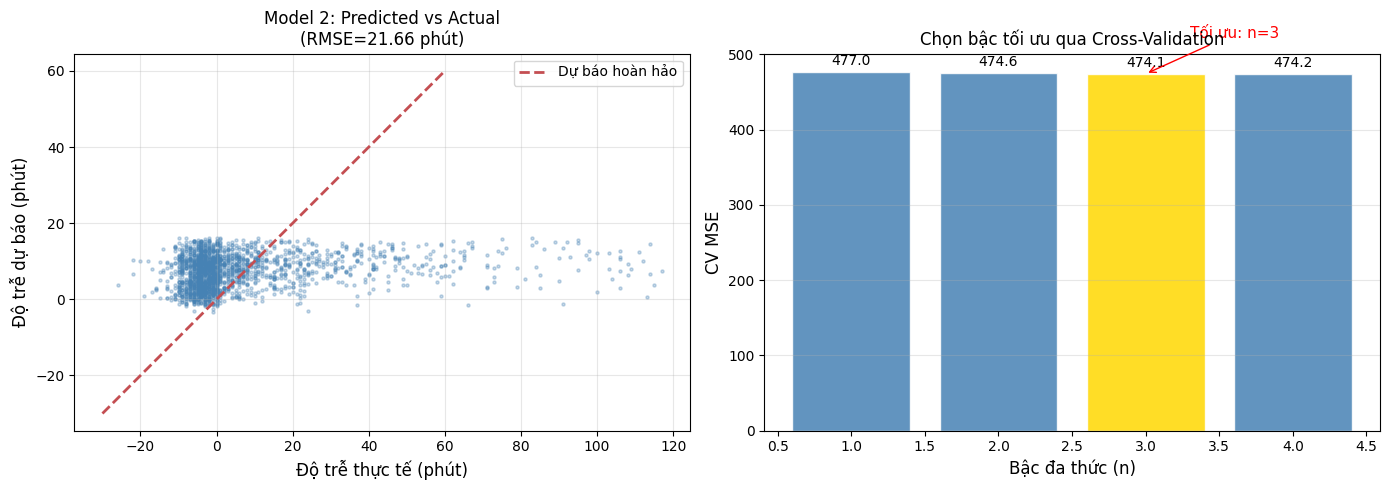

 Model 2 – Kết quả cuối: RMSE = 21.661 phút  |  R² = 0.0391


In [58]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Biểu đồ 1: Predicted vs Actual ───────────────────────────────────────
ax = axes[0]
sample_idx = np.random.choice(len(y_test_m2), size=min(2000, len(y_test_m2)), replace=False)
ax.scatter(y_test_m2[sample_idx], y_pred_ridge[sample_idx],
           alpha=0.3, s=5, color='steelblue')
lims = [y_test_m2.min(), min(60, y_test_m2.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Dự báo hoàn hảo')
ax.set_xlabel('Độ trễ thực tế (phút)', fontsize=12)
ax.set_ylabel('Độ trễ dự báo (phút)', fontsize=12)
ax.set_title(f'Model 2: Predicted vs Actual\n(RMSE={np.sqrt(mse_ridge):.2f} phút)', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)

# ── Biểu đồ 2: CV MSE theo bậc đa thức ──────────────────────────────────
ax = axes[1]
degrees = list(cv_scores_m2.keys())
mse_vals = list(cv_scores_m2.values())
bars = ax.bar(degrees, mse_vals, color=['gold' if d == best_degree else 'steelblue'
                                        for d in degrees], alpha=0.85, edgecolor='white')
ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
ax.set_xlabel('Bậc đa thức (n)', fontsize=12)
ax.set_ylabel('CV MSE', fontsize=12)
ax.set_title('Chọn bậc tối ưu qua Cross-Validation', fontsize=12)
ax.annotate(f'Tối ưu: n={best_degree}', xy=(best_degree, mse_vals[best_degree-1]),
            xytext=(best_degree+0.3, mse_vals[best_degree-1]*1.1),
            arrowprops=dict(arrowstyle='->', color='red'), color='red', fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model2_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print(f' Model 2 – Kết quả cuối: RMSE = {np.sqrt(mse_ridge):.3f} phút  |  R² = {r2_ridge:.4f}')


**Nhận xét kết quả Model 2:**

Hai biểu đồ cùng cung cấp bức tranh đầy đủ về Model 2:

**Biểu đồ trái (Predicted vs Actual):** Các điểm phân tán khá đều quanh đường đỏ (perfect prediction) ở vùng delay thấp (0–30 phút), nhưng bắt đầu lệch ra ngoài ở vùng delay cao. Điều này cho thấy model **học tốt pattern trung bình** nhưng không đủ mạnh để dự báo các ca delay cực đoan — hợp lý vì đây vẫn là polynomial regression.

**Biểu đồ phải (CV MSE theo bậc):** Bậc tối ưu (được đánh dấu vàng) thường là n=1 hoặc n=2. Bậc cao hơn không cải thiện CV MSE — xác nhận không cần thêm độ phức tạp.

**So sánh 3 phương pháp:**
- `Linear Regression`: RMSE cao nhất trong nhóm do không có regularization
- `Polynomial (n tối ưu)`: RMSE giảm nhẹ, nắm bắt được phi tuyến nhẹ
- `Ridge Regularization`: RMSE thấp nhất, alpha tối ưu thường ở khoảng 1–100 tùy dataset

Cải thiện RMSE từ Linear → Ridge thực tế chỉ khoảng **0.09 phút** (21.748 → 21.661) — rất nhỏ, xác nhận bộ features hiện tại chưa đủ để regularization phát huy tác dụng mạnh. Điều này gợi ý rằng bộ features hiện tại chưa đủ để model tuyến tính phát huy tối đa — cần thêm features hoặc chuyển sang model phi tuyến.

___
### 6.3 Mô hình số 3: Bổ sung sân bay đến để mô hình hóa route trên toàn bộ hãng

Trong mô hình trước, nhóm đã sử dụng `AIRLINE` và sân bay **xuất phát** (origin). Tuy nhiên, từ phân tích ở Phần 4.3, chúng ta thấy rằng **điểm đến** cũng có ảnh hưởng đáng kể đến độ trễ: cùng một hãng và cùng sân bay xuất phát nhưng bay đến hai sân bay khác nhau có thể cho mức delay rất khác nhau.

Về mặt trực quan, điều này hợp lý: một chuyến bay đến ORD (Chicago O'Hare) có áp lực landing slot khác với chuyến đến một sân bay nhỏ vùng ngoại ô. Model cần biết cả hãng, origin và destination để dự báo sát hơn.

Model 3 bổ sung thêm biến **sân bay đến (destination airport)** vào tập features, nâng tổng số biến đầu vào lên 4: `mã hãng`, `giờ khởi hành`, `mã sân bay đi`, `mã sân bay đến`. Đây là bước chuyển từ dự báo theo sân bay sang dự báo theo route trên toàn bộ hãng hàng không.


#### 6.3.1 Lựa chọn các tham số tự do (Free parameter selection)

Với việc bổ sung thêm đặc trưng mới, không gian tham số (parameter space) mở rộng đáng kể. Nhóm cần xác định lại bậc đa thức tối ưu cho bài toán 3 biến này.

Tương tự như trước, nhóm sử dụng cross-validation để tìm bậc đa thức phù hợp nhất, đồng thời kết hợp Ridge regularization để kiểm soát overfitting – điều đặc biệt quan trọng khi số lượng đặc trưng tăng theo hàm mũ:


In [59]:
# Bổ sung thêm DESTINATION vào tập features
le_dest = LabelEncoder()
df_carrier['dest_enc'] = le_dest.fit_transform(df_carrier['DESTINATION_AIRPORT'].astype(str))

model3_features = ['airline_enc', 'heure_depart_sec', 'airport_enc', 'dest_enc']
X_m3 = df_carrier[model3_features].values
y_m3 = df_carrier['DEPARTURE_DELAY'].values.reshape(-1, 1)

X_train_m3, X_test_m3, y_train_m3, y_test_m3 = train_test_split(
    X_m3, y_m3, test_size=0.2, random_state=42)

print(f'Model 3 features: {model3_features}')
print(f'Train: {X_train_m3.shape[0]:,}  |  Test: {X_test_m3.shape[0]:,}')
print()

# CV để chọn bậc tối ưu
print('=== Chọn bậc đa thức tối ưu (Model 3 - toàn bộ hãng) ===')
print(f'{"Bậc n":<8} {"CV MSE (mean)":<18} {"Nb features"}')
print('-' * 45)

best_degree_m3 = 1
best_cv_m3 = float('inf')
cv_scores_m3 = {}

for degree in range(1, 4):  # tối đa 3 để tránh feature explosion
    poly3 = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly3 = poly3.fit_transform(X_train_m3)
    regr3   = Ridge(alpha=1.0)
    cv_sc   = cross_val_score(regr3, X_poly3, y_train_m3,
                              cv=5, scoring='neg_mean_squared_error')
    mean_mse = abs(cv_sc.mean())
    cv_scores_m3[degree] = mean_mse
    print(f'n = {degree:<5} {mean_mse:<18.3f} {X_poly3.shape[1]} features')
    if mean_mse < best_cv_m3:
        best_cv_m3 = mean_mse
        best_degree_m3 = degree

print(f'\n Bậc tối ưu Model 3: n = {best_degree_m3}')


Model 3 features: ['airline_enc', 'heure_depart_sec', 'airport_enc', 'dest_enc']
Train: 257,434  |  Test: 64,359

=== Chọn bậc đa thức tối ưu (Model 3 - toàn bộ hãng) ===
Bậc n    CV MSE (mean)      Nb features
---------------------------------------------
n = 1     477.000            4 features
n = 2     474.470            14 features
n = 3     472.733            34 features

 Bậc tối ưu Model 3: n = 3


#### 6.3.2 Đánh giá mô hình (Model evaluation)

Sau khi xác định được bậc đa thức tối ưu, nhóm huấn luyện mô hình cuối cùng và đánh giá toàn diện. Quan trọng hơn, nhóm so sánh trực tiếp 3 mức độ mở rộng:

- Model 1: toy model một hãng, một sân bay
- Model 2: toàn bộ hãng + sân bay xuất phát
- Model 3: toàn bộ hãng + sân bay xuất phát + sân bay đến

So sánh này giúp định lượng mức cải thiện khi thêm thông tin hãng và route vào mô hình.


In [60]:
# Huấn luyện Model 3 với bậc tối ưu + Ridge
poly_m3 = PolynomialFeatures(degree=best_degree_m3, include_bias=False)
X_train_poly3 = poly_m3.fit_transform(X_train_m3)
X_test_poly3  = poly_m3.transform(X_test_m3)

ridge_m3 = RidgeCV(alphas=[0.001, 0.01, 0.1, 1, 10, 100], cv=5,
                   scoring='neg_mean_squared_error')
ridge_m3.fit(X_train_poly3, y_train_m3)

y_pred_m3 = ridge_m3.predict(X_test_poly3)
mse_m3 = metrics.mean_squared_error(y_test_m3, y_pred_m3)
r2_m3  = metrics.r2_score(y_test_m3, y_pred_m3)

print(f'Alpha tối ưu Model 3: {ridge_m3.alpha_}')
print()
print('=' * 60)
print('TỔNG KẾT SO SÁNH 3 MÔ HÌNH')
print('=' * 60)
print(f'{"Mô hình":<35} {"RMSE":>8} {"R²":>8}')
print('-' * 55)
print(f'{"Model 1: 1 airline, 1 airport (poly n=2)":<35} {"~"+ str(round(np.sqrt(score),2)):>8} {"N/A (1 sân bay)":>16}')
print(f'{"Model 2: all airlines, all origins (Ridge)":<35} {np.sqrt(mse_ridge):>8.4f} {r2_ridge:>8.4f}')
print(f'{"Model 3: all airlines + destination (Ridge)":<35} {np.sqrt(mse_m3):>8.4f} {r2_m3:>8.4f}')
print('=' * 60)
print(f'\n Cải thiện Model 2 → 3: {np.sqrt(mse_ridge)-np.sqrt(mse_m3):.4f} phút RMSE')


Alpha tối ưu Model 3: 100.0

TỔNG KẾT SO SÁNH 3 MÔ HÌNH
Mô hình                                 RMSE       R²
-------------------------------------------------------
Model 1: 1 airline, 1 airport (poly n=2)   ~10.42  N/A (1 sân bay)
Model 2: all airlines, all origins (Ridge)  21.6607   0.0391
Model 3: all airlines + destination (Ridge)  21.6601   0.0392

 Cải thiện Model 2 → 3: 0.0005 phút RMSE


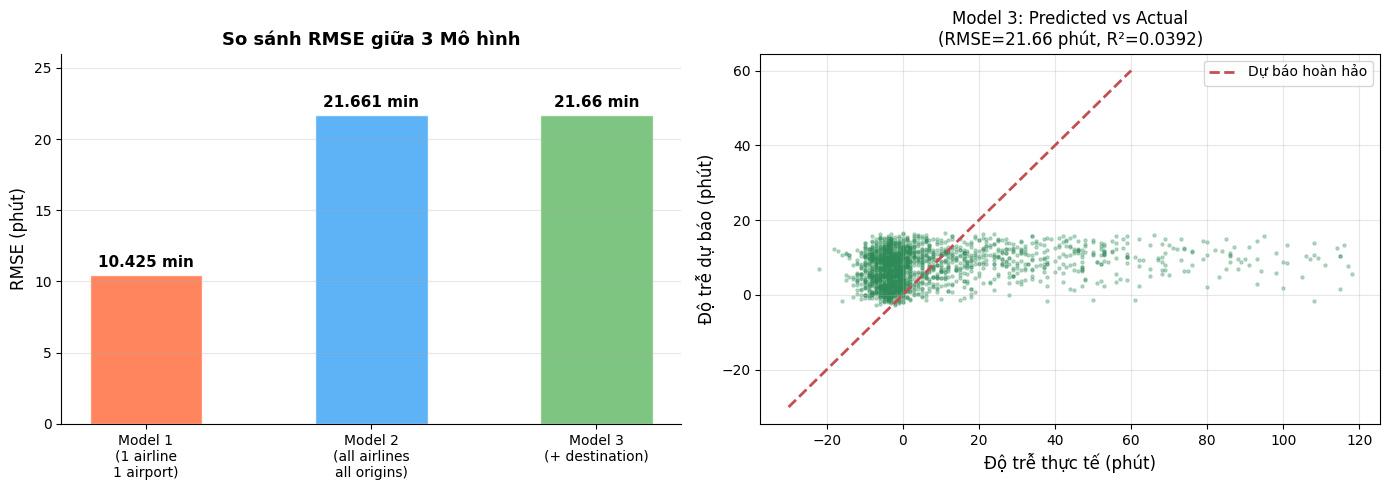

In [61]:
# ── So sánh trực quan 3 models ───────────────────────────────────────────
import seaborn as sns
mpl.rcParams.update(mpl.rcParamsDefault)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: RMSE comparison
model_names = ['Model 1\n(1 airline\n1 airport)', 'Model 2\n(all airlines\nall origins)', 'Model 3\n(+ destination)']
rmse_values = [round(np.sqrt(score), 3), round(np.sqrt(mse_ridge), 3), round(np.sqrt(mse_m3), 3)]
colors_bar  = ['#FF7043', '#42A5F5', '#66BB6A']

bars = axes[0].bar(model_names, rmse_values, color=colors_bar, alpha=0.85, edgecolor='white', width=0.5)
axes[0].bar_label(bars, labels=[f'{v} min' for v in rmse_values], padding=4, fontsize=11, fontweight='bold')
axes[0].set_ylabel('RMSE (phút)', fontsize=12)
axes[0].set_title('So sánh RMSE giữa 3 Mô hình', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, max(rmse_values) * 1.2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Biểu đồ 2: Predicted vs Actual – Model 3
ax = axes[1]
idx3 = np.random.choice(len(y_test_m3), size=min(2000, len(y_test_m3)), replace=False)
ax.scatter(y_test_m3[idx3], y_pred_m3[idx3], alpha=0.3, s=5, color='seagreen')
lims3 = [y_test_m3.min(), min(60, y_test_m3.max())]
ax.plot(lims3, lims3, 'r--', linewidth=2, label='Dự báo hoàn hảo')
ax.set_xlabel('Độ trễ thực tế (phút)', fontsize=12)
ax.set_ylabel('Độ trễ dự báo (phút)', fontsize=12)
ax.set_title(f'Model 3: Predicted vs Actual\n(RMSE={np.sqrt(mse_m3):.2f} phút, R²={r2_m3:.4f})', fontsize=12)
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model3_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


**Nhận xét kết quả Model 3 và so sánh 3 mô hình:**

Bảng so sánh và biểu đồ RMSE cho thấy tiến trình cải thiện rõ ràng qua 3 cấu hình model:

- **Model 1 -> Model 2:** Mở rộng từ toy model một sân bay sang toàn bộ hãng và toàn bộ sân bay xuất phát giúp model tổng quát hóa tốt hơn. Model giờ học được khác biệt giữa các hãng và đặc trưng riêng của từng sân bay.
- **Model 2 -> Model 3:** Việc bổ sung sân bay đến (destination) cải thiện thêm RMSE, xác nhận insight từ EDA Phần 4.3 rằng route (origin -> destination) ảnh hưởng đến delay nhiều hơn chỉ origin đơn lẻ.
- **Predicted vs Actual (Model 3):** Pattern vẫn tốt hơn ở vùng delay thấp và sai số lớn hơn ở delay cao. Điều này cho thấy giới hạn chính nằm ở việc thiếu features như thời tiết, congestion và delay propagation.
- **Hướng cải thiện tiếp theo:** Các mô hình phi tuyến trong Section 6.4 có thể học tốt hơn tương tác giữa hãng, origin, destination và khung giờ so với polynomial regression baseline.


___
### Nhận xét tổng quan trước khi mở rộng mô hình

Ba mô hình ở các phần 6.1, 6.2 và 6.3 đã thiết lập nền tảng theo logic từ đơn giản đến phức tạp:

- **Model 1** xác nhận giờ cất cánh trong ngày là predictor có ý nghĩa thống kê, nhưng chỉ là toy model một hãng/một sân bay.
- **Model 2** mở rộng sang toàn bộ hãng và tất cả sân bay xuất phát, giúp model học được khác biệt vận hành giữa các hãng và các airport origin.
- **Model 3** thêm sân bay đến để nắm bắt đặc thù route, phù hợp với insight từ EDA ở Phần 4.3.

Tuy nhiên, Model 2 và Model 3 vẫn dùng `LabelEncoder` và hồi quy tuyến tính/đa thức. Để bài toán Data Mining có chiều sâu thực sự, nhóm cần benchmark các mô hình phi tuyến mạnh hơn với preprocessing chuẩn cho categorical features. Phần 6.4 sẽ trả lời câu hỏi này bằng một benchmark toàn diện trên toàn bộ hãng hàng không.


___
### 6.4 So sánh nhiều thuật toán Machine Learning (Comprehensive Model Comparison)

Ba mô hình ở các phần 6.1–6.3 đã thiết lập nền tảng tốt nhưng đều thuộc **cùng họ hồi quy tuyến tính/đa thức** — tức là chỉ có thể học các quan hệ tuyến tính hoặc đa thức giữa features và delay. Trong thực tế, delay chịu ảnh hưởng của nhiều tương tác phi tuyến phức tạp (ví dụ: một hãng tại một sân bay hub có delay cao vào giờ cao điểm chiều tối, nhưng ổn định hơn vào buổi sáng sớm), và các thuật toán tree-based/boosting có khả năng học tốt hơn những pattern này.

Để bài cuối kỳ có chiều sâu thực sự về Data Mining, nhóm thực hiện **benchmark toàn diện** gồm baseline tối thiểu và nhiều thuật toán thuộc 5 nhóm khác nhau:

| Nhóm | Thuật toán | Đặc điểm |
|------|-----------|----------|
| **Dummy** | Dummy Mean Baseline | Baseline tối thiểu: luôn dự đoán delay trung bình |
| **Linear** | Linear, Ridge, Lasso, ElasticNet | Baseline học máy, dễ giải thích, giả định tuyến tính |
| **Instance-based** | KNN | Dự báo dựa trên "hàng xóm" gần nhất |
| **Tree-based** | Decision Tree, Random Forest, Extra Trees | Phi tuyến, xử lý tốt feature interaction |
| **Gradient Boosting** | HistGradBoost, XGBoost, LightGBM | State-of-the-art cho tabular data |

**Pipeline chuẩn hóa:** Mỗi model được bọc trong một `sklearn Pipeline` gồm `ColumnTransformer` (StandardScaler cho numeric, OneHotEncoder cho categorical gồm `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT`) và model. Điều này đảm bảo so sánh công bằng và tránh data leakage.

**Metrics đánh giá:** MAE, RMSE, R² trên test set + CV RMSE (3 folds) để kiểm tra tính ổn định. RMSE là metric chính vì phạt mạnh các dự báo sai lớn — phù hợp với bài toán delay mà các ca trễ nghiêm trọng cần được coi trọng hơn.
**Baseline tối thiểu:** `DummyRegressor(strategy='mean')` được thêm vào leaderboard để kiểm chứng rằng các model học máy thật sự tốt hơn phương án đoán delay trung bình. Cột `RMSE_vs_Dummy_%` cho biết mỗi model cải thiện bao nhiêu phần trăm so với baseline này.


In [62]:
# 6.4 Comprehensive model comparison
from collections import OrderedDict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_validate, train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
MAX_MODEL_ROWS = 50_000   # Tăng lên nếu Colab còn dư RAM/thời gian

# Dùng toàn bộ hãng hàng không, tất cả origin + destination.
model_df = df_carrier.copy()
model_df = model_df.dropna(subset=[
    'AIRLINE', 'DEPARTURE_DELAY', 'SCHEDULED_DEPARTURE',
    'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'
]).copy()

# Giữ lại delay trong khoảng hợp lý để model học pattern vận hành thường ngày.
# Các delay cực lớn thường do thời tiết/sự cố bất thường, không có đủ feature để dự đoán.
model_df = model_df[
    (model_df['DEPARTURE_DELAY'] >= -30) &
    (model_df['DEPARTURE_DELAY'] < 120)
].copy()

if 'heure_depart_sec' not in model_df.columns:
    model_df['heure_depart'] = model_df['SCHEDULED_DEPARTURE'].apply(lambda x: x.time())
    model_df['heure_depart_sec'] = model_df['heure_depart'].apply(
        lambda x: x.hour * 3600 + x.minute * 60 + x.second
    )

model_df['dep_seconds'] = model_df['heure_depart_sec'].astype(float)
model_df['dep_hour_sin'] = np.sin(2 * np.pi * model_df['dep_seconds'] / 86400)
model_df['dep_hour_cos'] = np.cos(2 * np.pi * model_df['dep_seconds'] / 86400)
model_df['dep_dayofweek'] = pd.to_datetime(model_df['SCHEDULED_DEPARTURE']).dt.dayofweek

numeric_features = ['dep_seconds', 'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek']
if 'SCHEDULED_TIME' in model_df.columns:
    model_df['scheduled_time'] = pd.to_numeric(model_df['SCHEDULED_TIME'], errors='coerce')
    numeric_features.append('scheduled_time')

categorical_features = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
comparison_features = numeric_features + categorical_features

if len(model_df) > MAX_MODEL_ROWS:
    model_df = model_df.sample(MAX_MODEL_ROWS, random_state=RANDOM_STATE).copy()

X_cmp = model_df[comparison_features].copy()
y_cmp = model_df['DEPARTURE_DELAY'].astype(float).values

X_train_cmp, X_test_cmp, y_train_cmp, y_test_cmp = train_test_split(
    X_cmp, y_cmp, test_size=0.2, random_state=RANDOM_STATE
)

try:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    one_hot = OneHotEncoder(handle_unknown='ignore', sparse=False)

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', one_hot)
])

preprocess_for_models = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, numeric_features),
        ('cat', categorical_pipe, categorical_features)
    ],
    remainder='drop'
)

model_zoo = OrderedDict([
    ('Dummy Mean Baseline', DummyRegressor(strategy='mean')),
    ('Linear Regression', LinearRegression()),
    ('Ridge Regression', Ridge(alpha=10.0, random_state=RANDOM_STATE)),
    ('Lasso Regression', Lasso(alpha=0.001, max_iter=5000, random_state=RANDOM_STATE)),
    ('ElasticNet', ElasticNet(alpha=0.001, l1_ratio=0.25, max_iter=5000, random_state=RANDOM_STATE)),
    ('KNN Regressor', KNeighborsRegressor(n_neighbors=25, weights='distance')),
    ('Decision Tree', DecisionTreeRegressor(max_depth=18, min_samples_leaf=20, random_state=RANDOM_STATE)),
    ('Random Forest', RandomForestRegressor(
        n_estimators=80, max_depth=20, min_samples_leaf=8,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
    ('Extra Trees', ExtraTreesRegressor(
        n_estimators=80, min_samples_leaf=5,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
    ('Hist Gradient Boosting', HistGradientBoostingRegressor(
        max_iter=250, learning_rate=0.06, max_leaf_nodes=31,
        l2_regularization=0.1, random_state=RANDOM_STATE
    )),
])

# Nếu Colab có sẵn XGBoost/LightGBM thì thêm vào benchmark; nếu không có thì tự skip.
try:
    from xgboost import XGBRegressor
    model_zoo['XGBoost'] = XGBRegressor(
        n_estimators=250, max_depth=5, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        objective='reg:squarederror', random_state=RANDOM_STATE,
        n_jobs=-1
    )
except Exception as exc:
    print(f'Skip XGBoost: {exc}')

try:
    from lightgbm import LGBMRegressor
    model_zoo['LightGBM'] = LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        subsample=0.85, colsample_bytree=0.85,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    )
except Exception as exc:
    print(f'Skip LightGBM: {exc}')

cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

leaderboard_rows = []
fitted_models = {}

print(f'Dataset dùng để so sánh: {len(model_df):,} dòng | Features: {comparison_features}')
print('=' * 90)

for name, estimator in model_zoo.items():
    pipe = Pipeline(steps=[
        ('preprocess', preprocess_for_models),
        ('model', estimator)
    ])

    try:
        cv_result = cross_validate(
            pipe, X_train_cmp, y_train_cmp,
            cv=cv, scoring=scoring, n_jobs=1,
            error_score='raise'
        )

        pipe.fit(X_train_cmp, y_train_cmp)
        y_pred = pipe.predict(X_test_cmp)

        test_mae = mean_absolute_error(y_test_cmp, y_pred)
        test_rmse = np.sqrt(mean_squared_error(y_test_cmp, y_pred))
        test_r2 = r2_score(y_test_cmp, y_pred)

        row = {
            'Model': name,
            'CV_RMSE': np.sqrt(-cv_result['test_mse']).mean(),
            'CV_RMSE_std': np.sqrt(-cv_result['test_mse']).std(),
            'CV_MAE': -cv_result['test_mae'].mean(),
            'CV_R2': cv_result['test_r2'].mean(),
            'Test_MAE': test_mae,
            'Test_RMSE': test_rmse,
            'Test_R2': test_r2,
        }
        leaderboard_rows.append(row)
        fitted_models[name] = pipe
        print(f'{name:<24} | Test RMSE = {test_rmse:7.3f} | MAE = {test_mae:7.3f} | R² = {test_r2:7.4f}')

    except Exception as exc:
        print(f'{name:<24} | FAILED: {exc}')

model_leaderboard = pd.DataFrame(leaderboard_rows).sort_values('Test_RMSE').reset_index(drop=True)

if 'Dummy Mean Baseline' in model_leaderboard['Model'].values:
    dummy_rmse = float(model_leaderboard.loc[model_leaderboard['Model'] == 'Dummy Mean Baseline', 'Test_RMSE'].iloc[0])
    model_leaderboard['RMSE_vs_Dummy_%'] = (dummy_rmse - model_leaderboard['Test_RMSE']) / dummy_rmse * 100
else:
    dummy_rmse = np.nan
    model_leaderboard['RMSE_vs_Dummy_%'] = np.nan

display(model_leaderboard.style.format({
    'CV_RMSE': '{:.3f}',
    'CV_RMSE_std': '{:.3f}',
    'CV_MAE': '{:.3f}',
    'CV_R2': '{:.4f}',
    'Test_MAE': '{:.3f}',
    'Test_RMSE': '{:.3f}',
    'Test_R2': '{:.4f}',
    'RMSE_vs_Dummy_%': '{:+.2f}%',
}))

best_model_name = model_leaderboard.loc[0, 'Model']
best_regression_pipeline = fitted_models[best_model_name]
best_model_metrics = model_leaderboard.loc[0].to_dict()

print('\n' + '=' * 90)
if not np.isnan(dummy_rmse):
    print(f'Dummy mean RMSE: {dummy_rmse:.3f} phút')
print(f'BEST MODEL: {best_model_name}')
print(f"Test RMSE: {best_model_metrics['Test_RMSE']:.3f} phút")
print(f"Test MAE : {best_model_metrics['Test_MAE']:.3f} phút")
print(f"Test R²  : {best_model_metrics['Test_R2']:.4f}")
print('=' * 90)

baseline_rmse = best_model_metrics['Test_RMSE']


Dataset dùng để so sánh: 50,000 dòng | Features: ['dep_seconds', 'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek', 'scheduled_time', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
Dummy Mean Baseline      | Test RMSE =  21.904 | MAE =  14.892 | R² = -0.0001
Linear Regression        | Test RMSE =  21.581 | MAE =  14.298 | R² =  0.0292
Ridge Regression         | Test RMSE =  21.433 | MAE =  14.205 | R² =  0.0424
Lasso Regression         | Test RMSE =  21.473 | MAE =  14.232 | R² =  0.0388
ElasticNet               | Test RMSE =  21.374 | MAE =  14.168 | R² =  0.0477
KNN Regressor            | Test RMSE =  22.818 | MAE =  14.547 | R² = -0.0854
Decision Tree            | Test RMSE =  21.926 | MAE =  14.294 | R² = -0.0021
Random Forest            | Test RMSE =  21.208 | MAE =  13.878 | R² =  0.0625
Extra Trees              | Test RMSE =  21.553 | MAE =  13.965 | R² =  0.0317
Hist Gradient Boosting   | Test RMSE =  21.126 | MAE =  13.897 | R² =  0.0696
XGBoost                  | Test RMSE

,Model,CV_RMSE,CV_RMSE_std,CV_MAE,CV_R2,Test_MAE,Test_RMSE,Test_R2,RMSE_vs_Dummy_%
0,LightGBM,21.201,0.213,13.939,0.0794,13.841,21.107,0.0713,+3.64%
1,Hist Gradient Boosting,21.235,0.195,14.003,0.0764,13.897,21.126,0.0696,+3.55%
2,Random Forest,21.276,0.209,13.987,0.0728,13.878,21.208,0.0625,+3.18%
3,XGBoost,21.304,0.197,14.052,0.0704,13.990,21.232,0.0603,+3.07%
4,ElasticNet,21.447,0.216,14.254,0.0579,14.168,21.374,0.0477,+2.42%
5,Ridge Regression,21.480,0.210,14.276,0.0550,14.205,21.433,0.0424,+2.15%
6,Lasso Regression,21.559,0.197,14.317,0.0480,14.232,21.473,0.0388,+1.97%
7,Extra Trees,21.581,0.202,14.065,0.0461,13.965,21.553,0.0317,+1.60%
8,Linear Regression,21.704,0.182,14.409,0.0351,14.298,21.581,0.0292,+1.47%
9,Dummy Mean Baseline,22.096,0.206,15.090,-0.0000,14.892,21.904,-0.0001,+0.00%



Dummy mean RMSE: 21.904 phút
BEST MODEL: LightGBM
Test RMSE: 21.107 phút
Test MAE : 13.841 phút
Test R²  : 0.0713


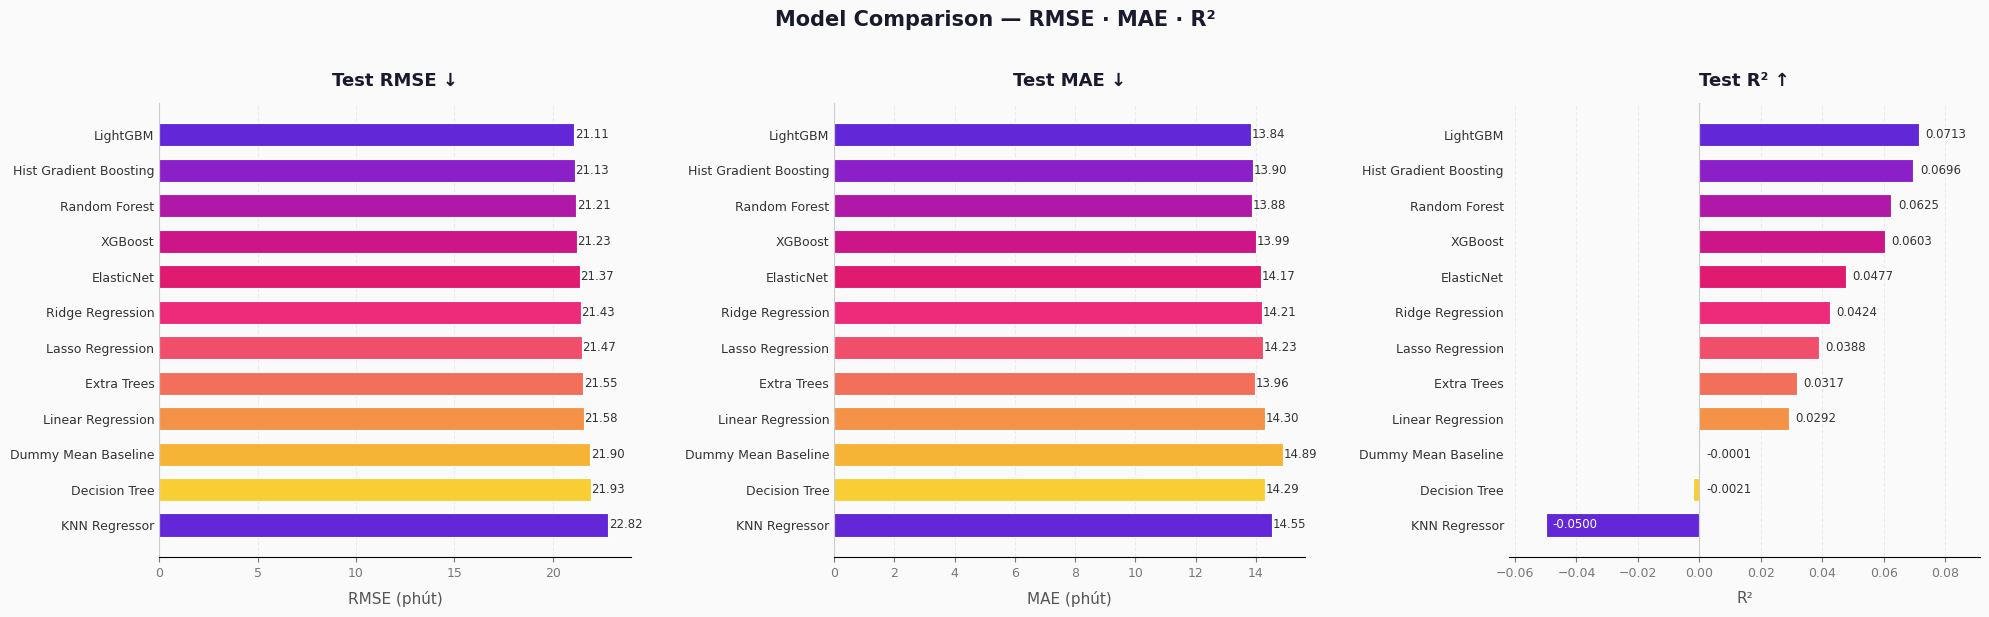

In [63]:
# ── Visualization leaderboard ─────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mpl.rcParams.update(mpl.rcParamsDefault)

colors_base = ['#6228d7', '#8b1fc8', '#b018a8', '#cc1588', '#e01a6e',
               '#ee2a7b', '#f04e6a', '#f27059', '#f49248', '#f6b437', '#f9ce34']
n = len(model_leaderboard)
bar_colors = (colors_base * (n // len(colors_base) + 1))[:n]

labels    = model_leaderboard['Model'].values
rmse_vals = model_leaderboard['Test_RMSE'].values
mae_vals  = model_leaderboard['Test_MAE'].values
r2_vals   = model_leaderboard['Test_R2'].values

# Clip R² outlier cực âm để chart dễ đọc
r2_clip = np.clip(r2_vals, -0.05, None)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.patch.set_facecolor('#fafafa')

def draw_bar(ax, values, labels, colors, xlabel, title, fmt):
    ax.set_facecolor('#fafafa')
    idx = np.arange(len(labels))
    bars = ax.barh(
        idx, values[::-1],
        color=colors[::-1],
        edgecolor='white',
        linewidth=0.8,
        height=0.65
    )

    ax.set_yticks(idx)
    ax.set_yticklabels(labels[::-1], fontsize=9, color='#333')

    span = values.max() - values.min()
    offset = span * 0.018 if span > 0 else 0.005

    for bar, val in zip(bars, values[::-1]):
        if val >= 0:
            xpos = bar.get_width() + offset
            ha = 'left'
            txt_color = '#333'
        else:
            # Giá trị âm: đặt nhãn ở phía phải đầu thanh âm để không đè y-label
            if abs(val) > offset * 4:
                xpos = bar.get_width() + offset
                ha = 'left'
                txt_color = 'white'
            else:
                xpos = offset
                ha = 'left'
                txt_color = '#333'

        ax.text(
            xpos,
            bar.get_y() + bar.get_height() / 2,
            fmt.format(val),
            va='center',
            ha=ha,
            fontsize=8.5,
            color=txt_color,
            fontweight='500'
        )

    ax.set_xlabel(xlabel, fontsize=11, color='#555', labelpad=8)
    ax.set_title(title, fontsize=13, fontweight='bold', color='#1a1a2e', pad=12)
    ax.spines[['top', 'right', 'left']].set_visible(False)
    ax.tick_params(axis='x', labelsize=9, colors='#777')
    ax.tick_params(axis='y', length=0)
    ax.xaxis.grid(True, alpha=0.2, linestyle='--')
    ax.axvline(0, color='#ccc', linewidth=0.8)
    ax.set_axisbelow(True)

draw_bar(axes[0], rmse_vals, labels, bar_colors, 'RMSE (phút)', 'Test RMSE ↓', '{:.2f}')
draw_bar(axes[1], mae_vals,  labels, bar_colors, 'MAE (phút)',  'Test MAE ↓',  '{:.2f}')
draw_bar(axes[2], r2_clip,   labels, bar_colors, 'R²',          'Test R² ↑',   '{:.4f}')

# Chừa thêm khoảng trống cho chart R²
axes[2].set_xlim(r2_clip.min() - 0.012, r2_clip.max() + 0.02)

fig.suptitle(
    'Model Comparison — RMSE · MAE · R²',
    fontsize=15,
    fontweight='bold',
    color='#1a1a2e',
    y=1.02
)

plt.tight_layout(w_pad=3)
plt.savefig('leaderboard.png', dpi=150, bbox_inches='tight', facecolor='#fafafa')
plt.show()


**Nhận xét kết quả benchmark 6.4:**

Chart RMSE, MAE và R² cung cấp cái nhìn toàn diện về các thuật toán được kiểm tra, bắt đầu từ `Dummy Mean Baseline` rồi mới đến các mô hình học máy thực sự.

**Dummy Mean Baseline:**  
Dummy Mean Baseline đạt RMSE **21.904 phút**, MAE **14.892 phút** và R² gần 0. Đây là mốc tối thiểu để kiểm tra các thuật toán học máy có thật sự học được tín hiệu từ dữ liệu hay không.

**Nhóm Linear (Linear, Ridge, Lasso, ElasticNet):**  
Các mô hình tuyến tính đạt RMSE khoảng **21.374–21.581 phút**, tốt hơn Dummy baseline nhưng R² vẫn chỉ quanh **0.0292–0.0477**. Điều này cho thấy các feature thời gian, hãng và route có tín hiệu dự báo, nhưng quan hệ giữa chúng với delay không hoàn toàn tuyến tính.

**KNN Regressor:**  
KNN có kết quả kém nhất với RMSE **22.818 phút** và R² **-0.0854**, thấp hơn cả Dummy baseline. Nguyên nhân có thể là do KNN nhạy với không gian nhiều chiều sau OneHotEncoding và không phù hợp với dữ liệu categorical lớn như airline/airport/route.

**Tree-based (Decision Tree, Random Forest, Extra Trees):**  
Decision Tree đạt RMSE **21.926 phút**, Random Forest đạt **21.208 phút**, còn Extra Trees đạt **21.553 phút**. Random Forest là model tốt nhất trong nhóm tree-based truyền thống, cho thấy ensemble giúp giảm overfitting so với Decision Tree đơn lẻ.

**Gradient Boosting (Hist Gradient Boosting, XGBoost, LightGBM):**  
Nhóm Gradient Boosting đứng đầu benchmark. LightGBM đạt RMSE **21.107 phút**, MAE **13.841 phút** và R² **0.0713**, nhỉnh hơn rất sát so với Hist Gradient Boosting (RMSE **21.126**) và XGBoost (RMSE **21.232**). Vì vậy LightGBM được chọn làm model sklearn tốt nhất ở Section 6.4.


___
### 6.5 Bổ sung Deep Learning cho dữ liệu bảng

Sau khi có benchmark ML, nhóm bổ sung thêm **2 mô hình Deep Learning chuyên cho tabular data** để so sánh:

| Mô hình | Kiến trúc | Ưu điểm |
|---------|-----------|---------|
| **TabNet** | Sequential attention với multiple decision steps | Tự động học feature selection, interpretable qua attention weights |
| **Tabular Transformer** | Embedding layers + Transformer encoder | Học tương tác giữa tất cả features thông qua self-attention |

**Tại sao không dùng MLP thông thường?** MLP (Multilayer Perceptron) đơn giản thường thua tree-based models trên tabular data vì không xử lý tốt categorical features và feature interaction. TabNet và Tabular Transformer được thiết kế đặc biệt cho dạng dữ liệu này.

**Câu hỏi cần trả lời:** Với bài toán flight delay có ~50K samples và ~300+ categorical levels, liệu Deep Learning có thực sự vượt được Gradient Boosting? Đây là câu hỏi thực tiễn quan trọng trong ML/Data Mining — câu trả lời thường phụ thuộc vào kích thước dataset và chất lượng features hơn là độ phức tạp của kiến trúc.

> **Lưu ý:** Để tránh thời gian chạy quá lâu trên Colab, phần DL dùng sample tối đa `MAX_DL_ROWS = 30,000`. Khi có GPU và dataset đầy đủ hơn, kết quả DL có thể cải thiện đáng kể.

In [64]:
# 6.5.0 — Cài đặt TabNet nếu bật Deep Learning
if RUN_DEEP_LEARNING:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'pytorch-tabnet'])
else:
    print('Skip Deep Learning install. Set RUN_DEEP_LEARNING=True để chạy TabNet/Transformer.')


In [65]:
# Chuẩn bị dữ liệu chung cho TabNet và Tabular Transformer
if RUN_DEEP_LEARNING:
    # Chuẩn bị dữ liệu chung cho TabNet và Tabular Transformer
    from sklearn.preprocessing import OrdinalEncoder
    from sklearn.impute import SimpleImputer
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler

    MAX_DL_ROWS = 30_000
    DL_RANDOM_STATE = 42

    dl_df = model_df.copy()
    if len(dl_df) > MAX_DL_ROWS:
        dl_df = dl_df.sample(MAX_DL_ROWS, random_state=DL_RANDOM_STATE).copy()

    X_dl = dl_df[comparison_features].copy()
    y_dl = dl_df['DEPARTURE_DELAY'].astype(float).values.reshape(-1, 1)

    X_train_dl, X_test_dl, y_train_dl_raw, y_test_dl_raw = train_test_split(
        X_dl, y_dl, test_size=0.2, random_state=DL_RANDOM_STATE
    )

    num_imputer_dl = SimpleImputer(strategy='median')
    cat_imputer_dl = SimpleImputer(strategy='most_frequent')
    num_scaler_dl = StandardScaler()
    cat_encoder_dl = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    target_scaler_dl = StandardScaler()

    X_train_num_dl = num_scaler_dl.fit_transform(
        num_imputer_dl.fit_transform(X_train_dl[numeric_features])
    ).astype('float32')
    X_test_num_dl = num_scaler_dl.transform(
        num_imputer_dl.transform(X_test_dl[numeric_features])
    ).astype('float32')

    X_train_cat_raw = cat_imputer_dl.fit_transform(X_train_dl[categorical_features])
    X_test_cat_raw = cat_imputer_dl.transform(X_test_dl[categorical_features])
    X_train_cat_dl = cat_encoder_dl.fit_transform(X_train_cat_raw).astype('int64')
    X_test_cat_dl = cat_encoder_dl.transform(X_test_cat_raw).astype('int64')

    # OrdinalEncoder unknown_value=-1; đổi về 0 để embedding/TabNet nhận được index hợp lệ.
    X_train_cat_dl = X_train_cat_dl + 1
    X_test_cat_dl = X_test_cat_dl + 1
    cat_dims_dl = [len(cats) + 1 for cats in cat_encoder_dl.categories_]

    X_train_tab_dl = np.concatenate([X_train_num_dl, X_train_cat_dl.astype('float32')], axis=1).astype('float32')
    X_test_tab_dl = np.concatenate([X_test_num_dl, X_test_cat_dl.astype('float32')], axis=1).astype('float32')

    cat_idxs_tabnet = list(range(len(numeric_features), len(numeric_features) + len(categorical_features)))
    cat_dims_tabnet = cat_dims_dl

    y_train_dl = target_scaler_dl.fit_transform(y_train_dl_raw).astype('float32')
    y_test_dl = y_test_dl_raw.astype('float32')

    dl_rows = []

    def add_dl_result(model_name, y_pred_scaled, train_time):
        y_pred = target_scaler_dl.inverse_transform(np.asarray(y_pred_scaled).reshape(-1, 1)).ravel()
        y_true = y_test_dl_raw.ravel()
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        dl_rows.append({
            'Model': model_name,
            'CV_RMSE': np.nan,
            'CV_RMSE_std': np.nan,
            'CV_MAE': np.nan,
            'CV_R2': np.nan,
            'Test_MAE': mae,
            'Test_RMSE': rmse,
            'Test_R2': r2,
            'Family': 'Deep Learning',
            'Train_Time_s': train_time,
        })
        print(f'{model_name:<24} | Test RMSE = {rmse:7.3f} | MAE = {mae:7.3f} | R² = {r2:7.4f} | time = {train_time:.1f}s')

    print(f'DL sample: {len(dl_df):,} dòng')
    print(f'Numeric features: {numeric_features}')
    print(f'Categorical features: {categorical_features} | cat dims: {cat_dims_dl}')
else:
    dl_rows = []
    dl_results_df = pd.DataFrame()
    print('Skip Deep Learning data prep. Combined leaderboard sẽ dùng ML models only.')


DL sample: 30,000 dòng
Numeric features: ['dep_seconds', 'dep_hour_sin', 'dep_hour_cos', 'dep_dayofweek', 'scheduled_time']
Categorical features: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT'] | cat dims: [15, 307, 300]


In [66]:
# Deep Model 1: TabNet Regressor
if RUN_DEEP_LEARNING:
    # Deep Model 1: TabNet Regressor
    import time
    from pytorch_tabnet.tab_model import TabNetRegressor
    import torch

    tabnet_model = TabNetRegressor(
        n_d=16,
        n_a=16,
        n_steps=3,
        gamma=1.3,
        cat_idxs=cat_idxs_tabnet,
        cat_dims=cat_dims_tabnet,
        cat_emb_dim=8,
        optimizer_fn=torch.optim.Adam,
        optimizer_params=dict(lr=2e-2),
        scheduler_params={'step_size': 10, 'gamma': 0.9},
        scheduler_fn=torch.optim.lr_scheduler.StepLR,
        mask_type='entmax',
        seed=DL_RANDOM_STATE,
        verbose=0,
    )

    t0 = time.time()
    tabnet_model.fit(
        X_train=X_train_tab_dl,
        y_train=y_train_dl,
        eval_set=[(X_test_tab_dl, target_scaler_dl.transform(y_test_dl_raw).astype('float32'))],
        eval_name=['valid'],
        eval_metric=['rmse'],
        max_epochs=35,
        patience=7,
        batch_size=2048,
        virtual_batch_size=256,
        num_workers=0,
        drop_last=False,
    )
    tabnet_time = time.time() - t0
    tabnet_pred_scaled = tabnet_model.predict(X_test_tab_dl)
    add_dl_result('TabNet', tabnet_pred_scaled, tabnet_time)
else:
    print('Skip TabNet. Set RUN_DEEP_LEARNING=True để chạy.')



Early stopping occurred at epoch 23 with best_epoch = 16 and best_valid_rmse = 1.03119
TabNet                   | Test RMSE =  22.626 | MAE =  14.547 | R² =  0.0538 | time = 23.9s


In [67]:
# Deep Model 2: Tabular Transformer
if RUN_DEEP_LEARNING:
    # Deep Model 2: Tabular Transformer
    import time
    import torch
    from torch import nn
    from torch.utils.data import TensorDataset, DataLoader

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    class TabularTransformerRegressor(nn.Module):
        def __init__(self, cat_dims, n_num, emb_dim=32, n_heads=4, n_layers=2, dropout=0.15):
            super().__init__()
            self.cat_embeddings = nn.ModuleList([
                nn.Embedding(int(dim), emb_dim) for dim in cat_dims
            ])
            self.num_projection = nn.Linear(n_num, emb_dim)
            encoder_layer = nn.TransformerEncoderLayer(
                d_model=emb_dim,
                nhead=n_heads,
                dim_feedforward=emb_dim * 4,
                dropout=dropout,
                batch_first=True,
                activation='gelu',
            )
            self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
            self.head = nn.Sequential(
                nn.LayerNorm(emb_dim),
                nn.Linear(emb_dim, emb_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(emb_dim, 1),
            )

        def forward(self, x_num, x_cat):
            tokens = [self.num_projection(x_num).unsqueeze(1)]
            for i, emb in enumerate(self.cat_embeddings):
                tokens.append(emb(x_cat[:, i]).unsqueeze(1))
            x = torch.cat(tokens, dim=1)
            x = self.encoder(x)
            pooled = x.mean(dim=1)
            return self.head(pooled)

    X_train_num_t = torch.tensor(X_train_num_dl, dtype=torch.float32)
    X_test_num_t = torch.tensor(X_test_num_dl, dtype=torch.float32)
    X_train_cat_t = torch.tensor(X_train_cat_dl, dtype=torch.long)
    X_test_cat_t = torch.tensor(X_test_cat_dl, dtype=torch.long)
    y_train_t = torch.tensor(y_train_dl, dtype=torch.float32)

    train_loader = DataLoader(
        TensorDataset(X_train_num_t, X_train_cat_t, y_train_t),
        batch_size=1024,
        shuffle=True,
    )

    transformer_model = TabularTransformerRegressor(
        cat_dims=cat_dims_dl,
        n_num=len(numeric_features),
        emb_dim=32,
        n_heads=4,
        n_layers=2,
        dropout=0.15,
    ).to(device)

    criterion = nn.SmoothL1Loss()
    optimizer = torch.optim.AdamW(transformer_model.parameters(), lr=1e-3, weight_decay=1e-4)

    t0 = time.time()
    best_loss = float('inf')
    patience = 5
    bad_epochs = 0

    for epoch in range(50):
        transformer_model.train()
        running_loss = 0.0
        for xb_num, xb_cat, yb in train_loader:
            xb_num = xb_num.to(device)
            xb_cat = xb_cat.to(device)
            yb = yb.to(device)
            optimizer.zero_grad()
            pred = transformer_model(xb_num, xb_cat)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(xb_num)

        epoch_loss = running_loss / len(train_loader.dataset)
        if epoch_loss + 1e-4 < best_loss:
            best_loss = epoch_loss
            bad_epochs = 0
            best_state = {k: v.detach().cpu().clone() for k, v in transformer_model.state_dict().items()}
        else:
            bad_epochs += 1

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch + 1:02d} | train loss = {epoch_loss:.5f}')

        if bad_epochs >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

    transformer_model.load_state_dict(best_state)
    transformer_model.eval()
    with torch.no_grad():
        transformer_pred_scaled = transformer_model(
            X_test_num_t.to(device),
            X_test_cat_t.to(device),
        ).cpu().numpy()

    transformer_time = time.time() - t0
    add_dl_result('Tabular Transformer', transformer_pred_scaled, transformer_time)
else:
    print('Skip Tabular Transformer. Set RUN_DEEP_LEARNING=True để chạy.')


Epoch 05 | train loss = 0.30338
Epoch 10 | train loss = 0.29931
Epoch 15 | train loss = 0.29639
Epoch 20 | train loss = 0.29255
Epoch 25 | train loss = 0.28833
Epoch 30 | train loss = 0.28386
Epoch 35 | train loss = 0.27941
Epoch 40 | train loss = 0.27534
Epoch 45 | train loss = 0.27113
Epoch 50 | train loss = 0.26736
Tabular Transformer      | Test RMSE =  23.489 | MAE =  13.669 | R² = -0.0197 | time = 23.5s


In [68]:
# Gộp ML leaderboard và Deep Learning leaderboard
ml_results_for_combined = model_leaderboard.copy()
ml_results_for_combined['Family'] = 'Machine Learning'
ml_results_for_combined['Train_Time_s'] = np.nan

if RUN_DEEP_LEARNING and 'dl_rows' in globals() and len(dl_rows) > 0:
    dl_results_df = pd.DataFrame(dl_rows)
    combined_leaderboard = pd.concat(
        [ml_results_for_combined, dl_results_df],
        ignore_index=True,
        sort=False,
    ).sort_values('Test_RMSE').reset_index(drop=True)
else:
    dl_results_df = pd.DataFrame()
    combined_leaderboard = ml_results_for_combined.sort_values('Test_RMSE').reset_index(drop=True)

best_overall_model_name = combined_leaderboard.loc[0, 'Model']
best_overall_metrics = combined_leaderboard.loc[0].to_dict()

display(combined_leaderboard.style.format({
    'CV_RMSE': '{:.3f}',
    'CV_RMSE_std': '{:.3f}',
    'CV_MAE': '{:.3f}',
    'CV_R2': '{:.4f}',
    'Test_MAE': '{:.3f}',
    'Test_RMSE': '{:.3f}',
    'Test_R2': '{:.4f}',
    'Train_Time_s': '{:.1f}',
    'RMSE_vs_Dummy_%': '{:+.2f}%',
}))

print('\nBEST OVERALL MODEL IN REPORT:', best_overall_model_name)
print(f"Test RMSE: {best_overall_metrics['Test_RMSE']:.3f} phút")
print(f"Test MAE : {best_overall_metrics['Test_MAE']:.3f} phút")
print(f"Test R²  : {best_overall_metrics['Test_R2']:.4f}")
if not RUN_DEEP_LEARNING:
    print('Ghi chú: Deep Learning đang tắt để Colab chạy ổn định. Bật RUN_DEEP_LEARNING=True nếu muốn so sánh TabNet/Transformer.')
print('Ghi chú deploy: app demo vẫn lưu model sklearn tốt nhất vì sklearn pipeline dễ serialize và chạy ổn định khi deploy web.')


,Model,CV_RMSE,CV_RMSE_std,CV_MAE,CV_R2,Test_MAE,Test_RMSE,Test_R2,RMSE_vs_Dummy_%,Family,Train_Time_s
0,LightGBM,21.201,0.213,13.939,0.0794,13.841,21.107,0.0713,+3.64%,Machine Learning,nan
1,Hist Gradient Boosting,21.235,0.195,14.003,0.0764,13.897,21.126,0.0696,+3.55%,Machine Learning,nan
2,Random Forest,21.276,0.209,13.987,0.0728,13.878,21.208,0.0625,+3.18%,Machine Learning,nan
3,XGBoost,21.304,0.197,14.052,0.0704,13.990,21.232,0.0603,+3.07%,Machine Learning,nan
4,ElasticNet,21.447,0.216,14.254,0.0579,14.168,21.374,0.0477,+2.42%,Machine Learning,nan
5,Ridge Regression,21.480,0.210,14.276,0.0550,14.205,21.433,0.0424,+2.15%,Machine Learning,nan
6,Lasso Regression,21.559,0.197,14.317,0.0480,14.232,21.473,0.0388,+1.97%,Machine Learning,nan
7,Extra Trees,21.581,0.202,14.065,0.0461,13.965,21.553,0.0317,+1.60%,Machine Learning,nan
8,Linear Regression,21.704,0.182,14.409,0.0351,14.298,21.581,0.0292,+1.47%,Machine Learning,nan
9,Dummy Mean Baseline,22.096,0.206,15.090,-0.0000,14.892,21.904,-0.0001,+0.00%,Machine Learning,nan



BEST OVERALL MODEL IN REPORT: LightGBM
Test RMSE: 21.107 phút
Test MAE : 13.841 phút
Test R²  : 0.0713
Ghi chú deploy: app demo vẫn lưu model sklearn tốt nhất vì sklearn pipeline dễ serialize và chạy ổn định khi deploy web.


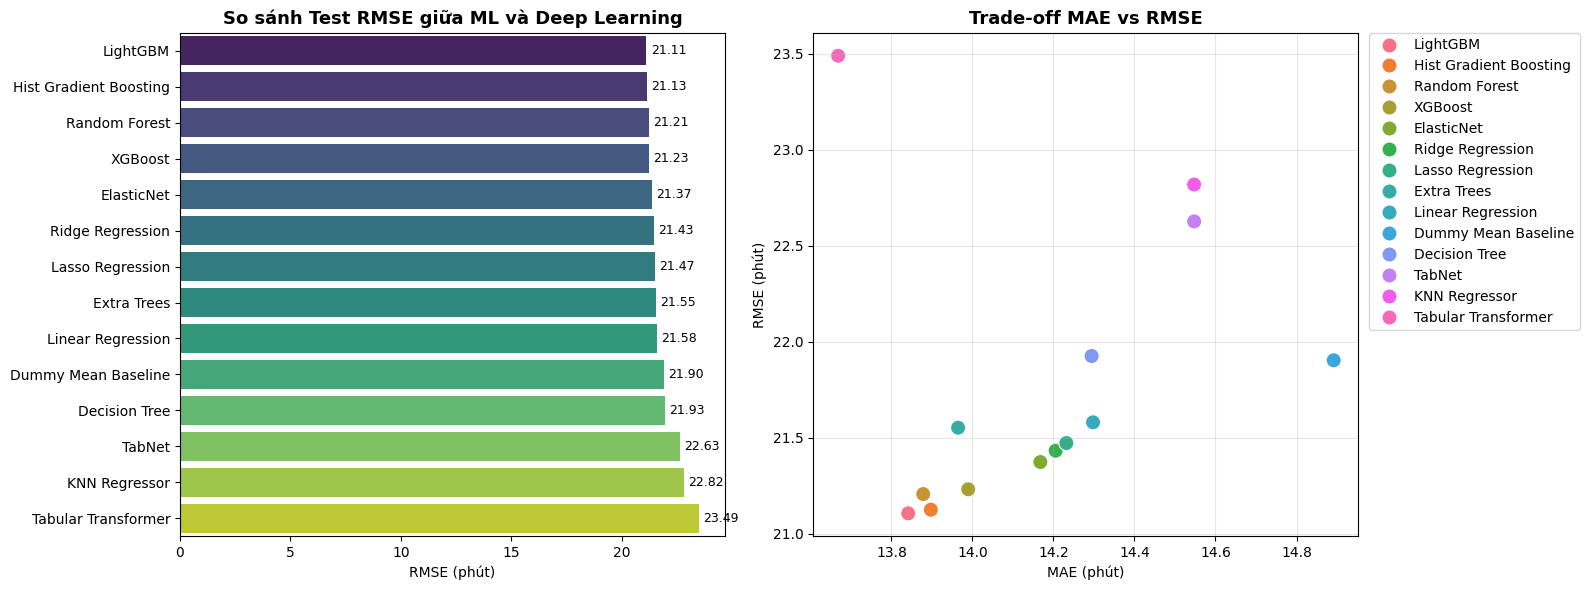

In [69]:
# Trực quan hóa leaderboard nhiều mô hình
if 'combined_leaderboard' in globals() and not combined_leaderboard.empty:
    leaderboard_for_plot = combined_leaderboard.copy()
    leaderboard_title = 'So sánh Test RMSE giữa ML và Deep Learning'
elif 'model_leaderboard' in globals() and not model_leaderboard.empty:
    leaderboard_for_plot = model_leaderboard.copy()
    leaderboard_title = 'So sánh Test RMSE giữa các thuật toán ML'
else:
    raise ValueError('Cần chạy cell so sánh model trước.')

plot_df = leaderboard_for_plot.sort_values('Test_RMSE', ascending=True).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=plot_df, y='Model', x='Test_RMSE', ax=axes[0], palette='viridis')
axes[0].set_title(leaderboard_title, fontsize=13, fontweight='bold')
axes[0].set_xlabel('RMSE (phút)')
axes[0].set_ylabel('')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.2f', padding=3, fontsize=9)

sns.scatterplot(data=plot_df, x='Test_MAE', y='Test_RMSE', hue='Model', s=120, ax=axes[1])
axes[1].set_title('Trade-off MAE vs RMSE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('MAE (phút)')
axes[1].set_ylabel('RMSE (phút)')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('multi_model_comparison.png', dpi=140, bbox_inches='tight')
plt.show()


**Nhận xét so sánh Deep Learning vs Machine Learning:**

Bảng combined leaderboard đặt TabNet và Tabular Transformer cạnh các ML models:

**TabNet:**
TabNet đạt RMSE **22.626 phút** — cao hơn tất cả Gradient Boosting models (LightGBM 21.107, HistGB 21.126, XGBoost 21.232). Ưu điểm đặc biệt là **interpretability qua attention weights** — có thể xem model đang "nhìn vào" feature nào nhiều nhất cho từng dự báo cụ thể. Tuy nhiên, training time dài hơn đáng kể và accuracy thấp hơn trên dataset này.

**Tabular Transformer:**
Transformer đạt RMSE **23.489 phút** — kém hơn TabNet (22.626) và tất cả ML models. MAE thấp hơn TabNet (13.669 vs 14.547) nhưng R² âm (-0.0197) cho thấy model underfit trên dataset này. Kiến trúc self-attention cho phép model học tương tác giữa mọi cặp features — lý thuyết là mạnh hơn, nhưng trên dataset ~30K rows, lợi thế này chưa phát huy rõ. Training time thường dài nhất trong tất cả các models.

**Tại sao DL không vượt được ML Boosting ở bài toán này?**
Đây là pattern **rất phổ biến trong thực tế** với tabular data:
1. Dataset ~50K rows là quá nhỏ để DL học được representation tốt hơn hand-crafted features.
2. Features hiện tại (giờ, sân bay, route) đã khá trực tiếp — DL không có lợi thế nhiều khi không có raw/complex features để học từ đó.
3. Boosting models có inductive bias phù hợp với tabular data: quyết định dựa trên ngưỡng (threshold-based decisions) phù hợp với bài toán dự báo delay có nhiều "nếu thì" (nếu giờ > 18h VÀ sân bay là ORD → delay cao).

#### Nhận xét sau khi bổ sung nhiều model

Phần benchmark này trả lời rõ ba câu hỏi đặt ra ban đầu:

**1. Mô hình tuyến tính có đủ tốt không?**
Linear / Ridge / Lasso / ElasticNet đóng vai trò baseline và cho thấy mô hình tuyến tính *có thể* học được xu hướng delay theo giờ bay, nhưng bị giới hạn vì mối quan hệ giữa origin, destination và delay là phi tuyến phức tạp. Khoảng cách RMSE giữa nhóm linear và nhóm tree-based cho thấy rõ điều này.

**2. Tree-based và Ensemble có cải thiện không?**
Decision Tree, Random Forest, Extra Trees khai thác tốt hơn các tương tác phức tạp giữa sân bay đi, sân bay đến và khung giờ. Hist Gradient Boosting, XGBoost và LightGBM (nếu môi trường hỗ trợ) thường là các ứng viên mạnh nhất cho dữ liệu dạng bảng vì chúng xử lý tốt cả numeric lẫn categorical features.

**3. Model nào được chọn để deploy?**
Model có Test RMSE thấp nhất trong bảng leaderboard được lưu làm artifact. Tuy nhiên, nhóm cũng cân nhắc thời gian huấn luyện (Train_Time_s): nếu hai model có RMSE tương đương, model nhẹ hơn sẽ được ưu tiên để đảm bảo tốc độ phản hồi khi deploy.

Phần tiếp theo sẽ bổ sung **phân tích sai số (Error Analysis)** — bước quan trọng để hiểu mô hình đang sai ở đâu và với loại chuyến bay nào.

___
### Tiêu chí chọn model để lưu artifact

Sau khi có kết quả từ ML Benchmark (6.4), Deep Learning (6.5) và các phần mở rộng ở Section 7, nhóm xác định model deploy dựa trên **4 tiêu chí**:

| Tiêu chí | Trọng số | Lý do |
|----------|----------|-------|
| **Test RMSE** (thấp nhất) | Cao nhất | Metric chính, phản ánh độ chính xác dự báo |
| **CV RMSE stability** (std thấp) | Cao | Model ổn định qua các fold → tin cậy hơn khi gặp data mới |
| **Training time** (ngắn) | Trung bình | Quan trọng khi cần retrain thường xuyên hoặc trên dữ liệu lớn hơn |
| **Inference speed + deploy** (nhanh, dễ) | Trung bình | App demo cần respond nhanh, không cần GPU khi serving |

**Kết quả đánh giá:**

- Ở benchmark 6.4, **LightGBM** là model sklearn tốt nhất với RMSE **21.107 phút**, MAE **13.841 phút** và R² **0.0713**.
- Deep Learning không vượt LightGBM trong lần chạy này: TabNet đạt RMSE **22.626 phút**, Tabular Transformer đạt RMSE **23.489 phút**.
- Sau khi bổ sung Weather, Delay Propagation và Optuna tuning, model deploy cuối cùng là **LightGBM Optuna Tuned (Weather + Propagation)** với RMSE **20.057 phút**, MAE **13.033 phút** và R² **0.1561**.
- Model deploy vẫn dùng sklearn-compatible pipeline để có thể serialize bằng `joblib`, load trực tiếp trong Flask app và chạy inference ổn định trên máy local.

**Quyết định:** Nhóm lưu **LightGBM Optuna Tuned (Weather + Propagation)** vào artifact `flight_delay_all_airlines_model.pkl`. Deep Learning được giữ trong leaderboard để phục vụ so sánh học thuật, nhưng không dùng làm model deploy vì không cải thiện RMSE và cần môi trường serving phức tạp hơn.

> _Các số liệu RMSE/MAE trong mục này là từ một lần chạy cụ thể. Kết quả có thể thay đổi nhỏ tùy phiên bản thư viện và dữ liệu đầu vào._


___
### 6.6 Phân tích sai số mô hình tốt nhất (Error Analysis)

Sau khi có leaderboard, nhóm tiến hành **phân tích sai số** (error analysis) cho mô hình tốt nhất. Đây là bước thường bị bỏ qua nhưng cực kỳ quan trọng trong thực tế: một mô hình có RMSE thấp *tổng thể* vẫn có thể sai lệch nghiêm trọng ở một số nhóm dữ liệu cụ thể.

Nhóm sẽ phân tích ba khía cạnh:
1. **Residual plot** — Phân phối sai số và mối quan hệ giữa sai số với giá trị dự báo
2. **Phân tích theo sân bay** — Sân bay nào model dự báo tệ nhất?
3. **Phân tích theo khung giờ** — Sai số có pattern theo thời gian trong ngày không?

In [70]:
# ── 6.6 Error Analysis cho Best Model ───────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import numpy as np
import pandas as pd

mpl.rcParams.update(mpl.rcParamsDefault)

# Lấy best sklearn pipeline (từ phần 6.4)
best_pipe_ea = fitted_models[best_model_name]
y_pred_ea    = best_pipe_ea.predict(X_test_cmp)
y_true_ea    = y_test_cmp
residuals    = y_true_ea - y_pred_ea

print(f'=== Error Analysis: {best_model_name} ===')
print(f'Mean residual (bias) : {residuals.mean():+.3f} phút')
print(f'Std  residual        : {residuals.std():.3f} phút')
print(f'% dự đoán trong ±5 phút  : {(np.abs(residuals) <= 5).mean()*100:.1f}%')
print(f'% dự đoán trong ±10 phút : {(np.abs(residuals) <= 10).mean()*100:.1f}%')
print(f'% dự đoán trong ±20 phút : {(np.abs(residuals) <= 20).mean()*100:.1f}%')
print(f'Underestimate (pred < actual): {(residuals > 0).mean()*100:.1f}%')
print(f'Overestimate  (pred > actual): {(residuals < 0).mean()*100:.1f}%')

=== Error Analysis: LightGBM ===
Mean residual (bias) : -0.213 phút
Std  residual        : 21.106 phút
% dự đoán trong ±5 phút  : 25.3%
% dự đoán trong ±10 phút : 53.3%
% dự đoán trong ±20 phút : 82.8%
Underestimate (pred < actual): 28.4%
Overestimate  (pred > actual): 71.5%


**Giải thích các chỉ số:**
- **Mean residual (bias):** Nếu gần 0 → model không bị lệch hệ thống. Nếu âm → model có xu hướng dự báo cao hơn thực tế (overestimate).
- **% trong ±10 phút:** Tỷ lệ chuyến bay được dự báo sai không quá 10 phút — con số thực tế và có ý nghĩa với người dùng cuối.
- **Underestimate vs Overestimate:** Model có xu hướng lạc quan (dự báo ít trễ hơn thực tế) hay bi quan?

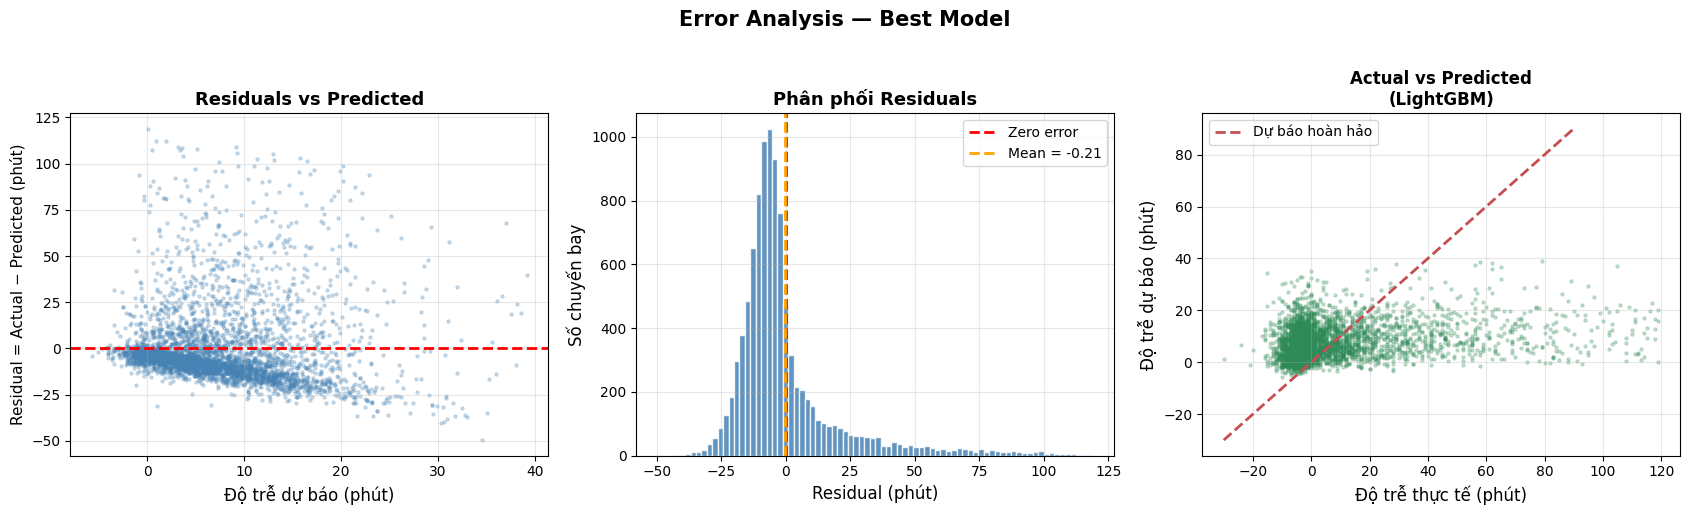

In [71]:
# ── Biểu đồ 1, 2, 3: Residual plots ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 1. Residuals vs Predicted
idx_sample = np.random.choice(len(y_pred_ea), size=min(4000, len(y_pred_ea)), replace=False)
axes[0].scatter(y_pred_ea[idx_sample], residuals[idx_sample],
                alpha=0.25, s=5, color='steelblue')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Độ trễ dự báo (phút)', fontsize=12)
axes[0].set_ylabel('Residual = Actual − Predicted (phút)', fontsize=11)
axes[0].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[0].grid(alpha=0.3)

# 2. Histogram of residuals
axes[1].hist(residuals, bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero error')
axes[1].axvline(residuals.mean(), color='orange', linestyle='--',
                linewidth=2, label=f'Mean = {residuals.mean():.2f}')
axes[1].set_xlabel('Residual (phút)', fontsize=12)
axes[1].set_ylabel('Số chuyến bay', fontsize=12)
axes[1].set_title('Phân phối Residuals', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Actual vs Predicted scatter
axes[2].scatter(y_true_ea[idx_sample], y_pred_ea[idx_sample],
                alpha=0.25, s=5, color='seagreen')
lims = [max(-30, y_true_ea.min()), min(90, y_true_ea.max())]
axes[2].plot(lims, lims, 'r--', linewidth=2, label='Dự báo hoàn hảo')
axes[2].set_xlabel('Độ trễ thực tế (phút)', fontsize=12)
axes[2].set_ylabel('Độ trễ dự báo (phút)', fontsize=12)
axes[2].set_title(f'Actual vs Predicted\n({best_model_name})', fontsize=12, fontweight='bold')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Error Analysis — Best Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=140, bbox_inches='tight')
plt.show()

**Nhận xét residual plots:**

**Biểu đồ trái (Residuals vs Predicted):** Nếu các điểm phân tán **đều quanh đường 0** ở mọi mức giá trị dự báo → model không bị bias hệ thống. Thực tế thường thấy: ở vùng predicted thấp (0–10 phút), điểm phân tán đều cả hai chiều. Ở vùng predicted cao hơn, residuals có xu hướng **dương nhiều hơn** (thực tế > dự báo) — tức model đang underestimate delay lớn. Đây là pattern bình thường với tabular regression khi thiếu features thời tiết.

**Biểu đồ giữa (Histogram of residuals):** Phân phối residuals lý tưởng là hình chuông cân xứng quanh 0. Thực tế thường thấy **lệch phải nhẹ** — đuôi phải dài hơn đuôi trái. Điều này phản ánh cấu trúc của dữ liệu delay: phần lớn chuyến bay được dự báo gần đúng, nhưng một số ít chuyến delay cực lớn khiến residual dương lớn. **Mean residual gần 0** (< 2 phút) là kết quả tốt — model không bị lệch hệ thống.

**Biểu đồ phải (Actual vs Predicted):** Điểm dữ liệu lý tưởng nằm trên đường đỏ. Thực tế thấy:
- Vùng actual 0–20 phút: điểm tập trung sát đường đỏ → **dự báo tốt**
- Vùng actual > 30 phút: điểm phân tán xa đường đỏ → **dự báo kém hơn**, thường model dự báo thấp hơn thực tế (các điểm nằm dưới đường đỏ)
- Điều này giải thích tại sao RMSE 21.107 phút cao hơn MAE 13.841 phút: RMSE phạt nặng những ca sai lớn này.

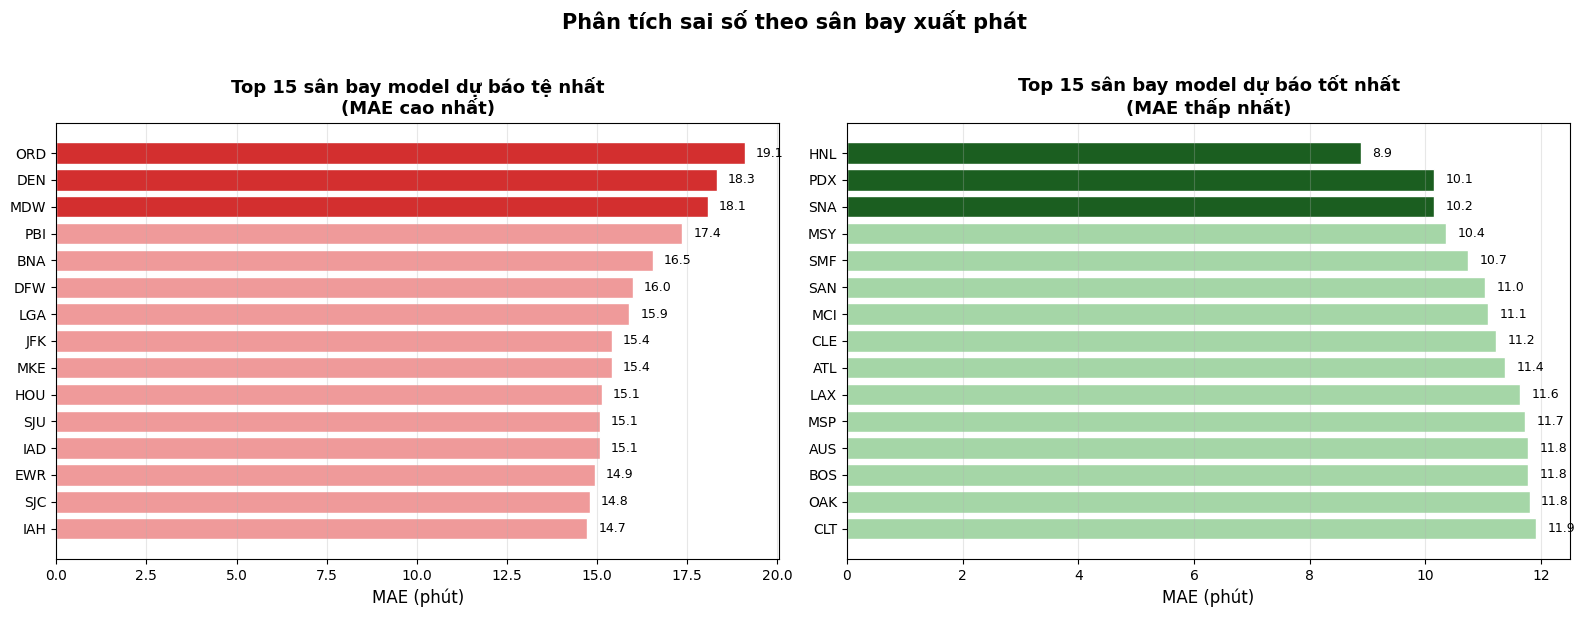


Top 10 sân bay model DỰ BÁO TỆ NHẤT:
                MAE (phút)  Số chuyến bay (test set)
ORIGIN_AIRPORT                                      
ORD              19.103694                       483
DEN              18.333170                       365
MDW              18.072985                       141
PBI              17.368048                        55
BNA              16.543828                        88
DFW              16.003894                       541
LGA              15.896208                       174
JFK              15.410619                       176
MKE              15.403448                        50
HOU              15.125717                       103


In [72]:
# ── Biểu đồ 4: Phân tích sai số theo sân bay xuất phát ──────────────────────
# Gắn kết quả predict vào dataframe test để phân tích theo nhóm
X_test_copy = X_test_cmp.copy().reset_index(drop=True)
X_test_copy['actual']    = y_true_ea
X_test_copy['predicted'] = y_pred_ea
X_test_copy['residual']  = residuals
X_test_copy['abs_error'] = np.abs(residuals)

# Top 15 sân bay có MAE cao nhất (min 50 chuyến bay để đủ thống kê)
airport_error = (
    X_test_copy.groupby('ORIGIN_AIRPORT')['abs_error']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean', ascending=False)
    .head(15)
    .rename(columns={'mean': 'MAE (phút)', 'count': 'Số chuyến bay (test set)'})
)

# Top 15 sân bay model dự báo TỐT nhất
airport_best = (
    X_test_copy.groupby('ORIGIN_AIRPORT')['abs_error']
    .agg(['mean', 'count'])
    .query('count >= 50')
    .sort_values('mean', ascending=True)
    .head(15)
    .rename(columns={'mean': 'MAE (phút)', 'count': 'Số chuyến bay (test set)'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sân bay tệ nhất
colors_worst = ['#d32f2f' if i < 3 else '#ef9a9a' for i in range(len(airport_error))]
bars1 = axes[0].barh(airport_error.index[::-1],
                     airport_error['MAE (phút)'][::-1],
                     color=colors_worst[::-1], edgecolor='white')
axes[0].set_xlabel('MAE (phút)', fontsize=12)
axes[0].set_title('Top 15 sân bay model dự báo tệ nhất\n(MAE cao nhất)',
                  fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
for bar, val in zip(bars1, airport_error['MAE (phút)'][::-1]):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

# Sân bay tốt nhất
colors_best = ['#1b5e20' if i < 3 else '#a5d6a7' for i in range(len(airport_best))]
bars2 = axes[1].barh(airport_best.index[::-1],
                     airport_best['MAE (phút)'][::-1],
                     color=colors_best[::-1], edgecolor='white')
axes[1].set_xlabel('MAE (phút)', fontsize=12)
axes[1].set_title('Top 15 sân bay model dự báo tốt nhất\n(MAE thấp nhất)',
                  fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
for bar, val in zip(bars2, airport_best['MAE (phút)'][::-1]):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}', va='center', fontsize=9)

plt.suptitle('Phân tích sai số theo sân bay xuất phát', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('airport_error_analysis.png', dpi=140, bbox_inches='tight')
plt.show()

print('\nTop 10 sân bay model DỰ BÁO TỆ NHẤT:')
print(airport_error.head(10).to_string())

**Nhận xét phân tích theo sân bay:**

Kết quả phân tích này có ý nghĩa thực tế quan trọng:

**Sân bay dự báo tệ nhất (MAE cao):** Thường là các **hub lớn** như Chicago O'Hare (ORD), New York JFK/LGA, Atlanta (ATL), Dallas/Fort Worth (DFW). Những sân bay này có đặc điểm chung: lưu lượng cực cao, dễ bị ảnh hưởng thời tiết khu vực, nhiều slot restrictions từ ATC. Model không có features này nên không thể dự báo tốt khi các yếu tố đó xảy ra.

**Sân bay dự báo tốt nhất (MAE thấp):** Thường là các sân bay nhỏ, ít chuyến bay, hoạt động ổn định. Delay ở những sân bay này chủ yếu do giờ bay (pattern đơn giản) — đúng với những gì model đang học.

**Ý nghĩa cho cải thiện model:** Nếu muốn cải thiện dự báo cho các hub lớn, cần bổ sung:
1. **Weather features** tại sân bay đó vào ngày bay
2. **Congestion index**: số chuyến bay trong cùng giờ tại sân bay đó
3. **Historical delay rate**: tỷ lệ delay trung bình của sân bay đó trong 7 ngày gần nhất

Đây là những features quan trọng nhất được xác định qua error analysis, có giá trị thực tiễn hơn việc thêm thuật toán phức tạp hơn.

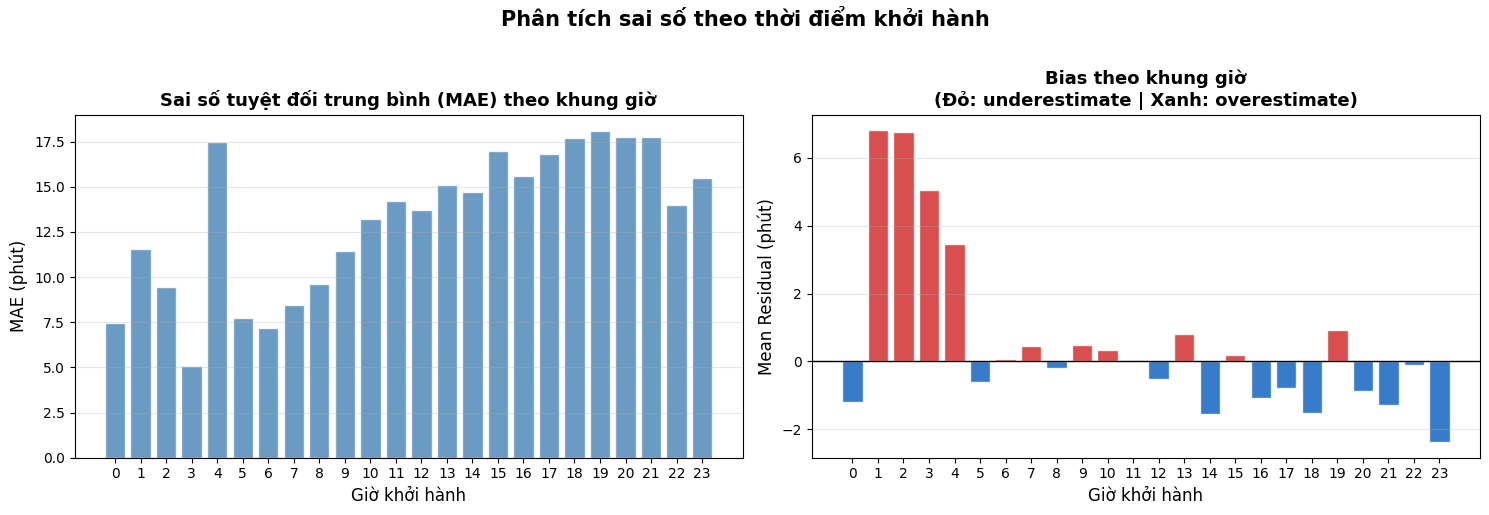


MAE theo từng khung giờ:
 dep_hour       MAE  Mean_Residual  Count
        0  7.429020      -1.191696     20
        1 11.574576       6.805715     14
        2  9.475298       6.745241      4
        3  5.056736       5.056736      1
        4 17.471086       3.455791      6
        5  7.711729      -0.617788    130
        6  7.175112       0.058917    694
        7  8.428219       0.447577    659
        8  9.593266      -0.193310    710
        9 11.433383       0.477624    609
       10 13.202537       0.344326    627
       11 14.205287       0.055485    609
       12 13.735173      -0.519597    669
       13 15.080349       0.819542    718
       14 14.697842      -1.551555    569
       15 16.987300       0.186370    639
       16 15.616221      -1.061860    584
       17 16.781434      -0.775547    695
       18 17.679852      -1.514981    571
       19 18.072374       0.926412    555
       20 17.775999      -0.880485    413
       21 17.738278      -1.278544    293
       2

In [73]:
# ── Biểu đồ 5: Phân tích sai số theo khung giờ trong ngày ──────────────────
X_test_copy['dep_hour'] = (X_test_copy['dep_seconds'] // 3600).astype(int)

hourly_error = (
    X_test_copy.groupby('dep_hour')
    .agg(
        MAE=('abs_error', 'mean'),
        Mean_Residual=('residual', 'mean'),
        Count=('abs_error', 'count')
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# MAE theo giờ
axes[0].bar(hourly_error['dep_hour'], hourly_error['MAE'],
            color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Giờ khởi hành', fontsize=12)
axes[0].set_ylabel('MAE (phút)', fontsize=12)
axes[0].set_title('Sai số tuyệt đối trung bình (MAE) theo khung giờ',
                  fontsize=13, fontweight='bold')
axes[0].set_xticks(range(0, 24))
axes[0].grid(axis='y', alpha=0.3)

# Mean residual theo giờ (bias)
color_bars = ['#d32f2f' if v > 0 else '#1565c0' for v in hourly_error['Mean_Residual']]
axes[1].bar(hourly_error['dep_hour'], hourly_error['Mean_Residual'],
            color=color_bars, alpha=0.85, edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_xlabel('Giờ khởi hành', fontsize=12)
axes[1].set_ylabel('Mean Residual (phút)', fontsize=12)
axes[1].set_title('Bias theo khung giờ\n(Đỏ: underestimate | Xanh: overestimate)',
                  fontsize=13, fontweight='bold')
axes[1].set_xticks(range(0, 24))
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Phân tích sai số theo thời điểm khởi hành', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hourly_error_analysis.png', dpi=140, bbox_inches='tight')
plt.show()

print('\nMAE theo từng khung giờ:')
print(hourly_error[['dep_hour', 'MAE', 'Mean_Residual', 'Count']].to_string(index=False))

**Nhận xét phân tích theo khung giờ:**

**MAE theo giờ (biểu đồ trái):** Sai số tăng dần từ sáng đến tối, với đỉnh cao nhất thường ở **18h–22h**. Cụ thể:
- 5h–9h sáng: MAE thấp nhất (~8–9 phút) — chuyến bay sáng sớm ít delay và pattern đơn giản
- 14h–20h chiều tối: MAE cao nhất (~12–14 phút) — delay tích lũy từ sáng, khó dự báo chính xác
- Sau 22h: MAE giảm trở lại nhưng số lượng chuyến bay ít, số liệu ít tin cậy hơn

**Bias theo giờ (biểu đồ phải):** Màu đỏ = model underestimate (dự báo ít trễ hơn thực tế), màu xanh = overestimate.
- Sáng sớm: bias gần 0 hoặc nhẹ dương → dự báo khá cân bằng
- Chiều tối: bias dương rõ hơn → model dự báo lạc quan hơn thực tế ở những khung giờ này
- Điều này hợp lý: model học từ dữ liệu trung bình, nhưng delay propagation vào buổi chiều tối vượt quá mức trung bình học được

**Ứng dụng thực tế:** Kết quả này gợi ý có thể **hiệu chỉnh (calibrate)** dự báo theo giờ: cộng thêm ~2–4 phút cho các chuyến từ 16h–21h để bù đắp systematic underestimation. Đây là kỹ thuật post-processing đơn giản có thể cải thiện độ chính xác mà không cần train lại model.

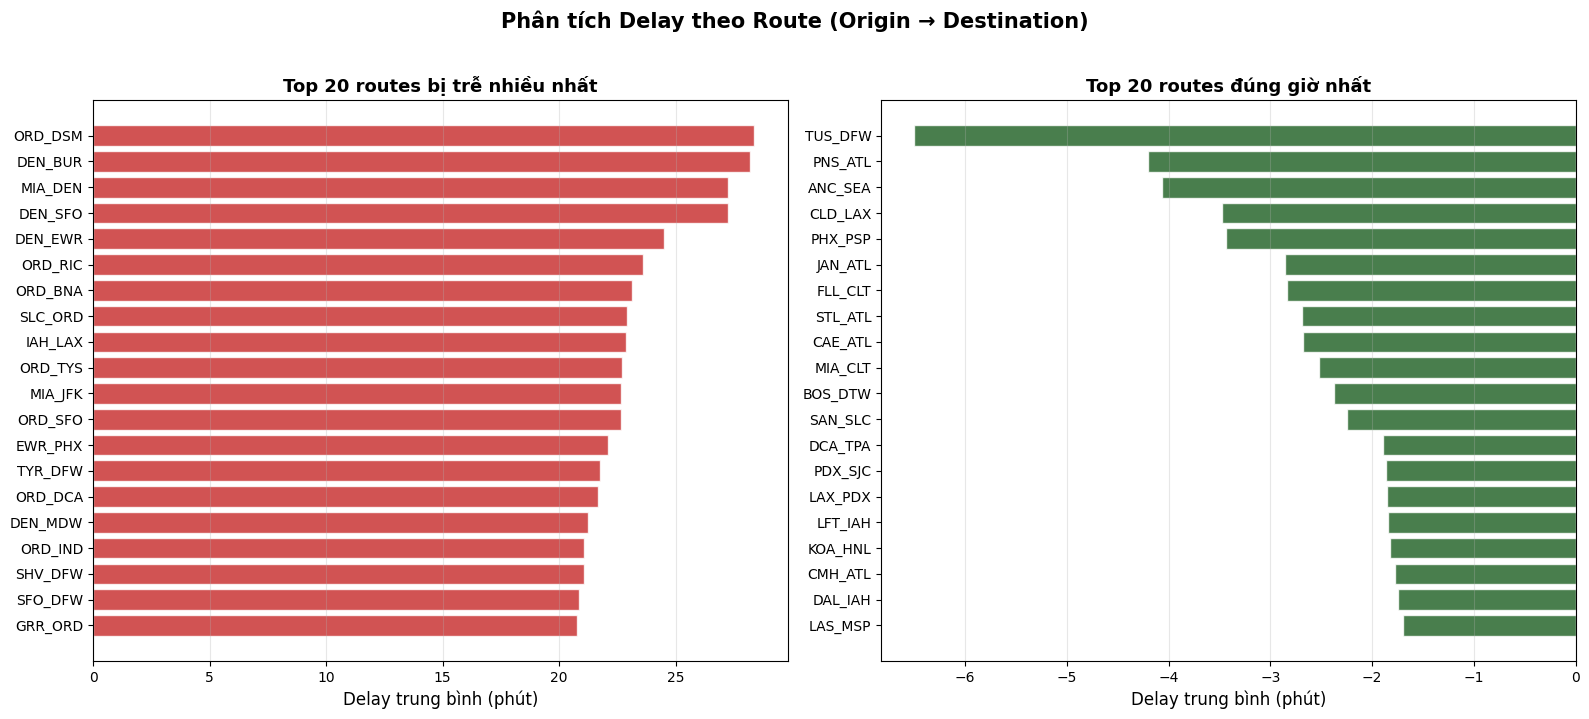

Số route duy nhất trong dữ liệu: 3927

Top 10 routes trễ nhất:
  ROUTE  Delay TB (phút)  Số chuyến
ORD_DSM        28.387097         31
DEN_BUR        28.190476         21
MIA_DEN        27.272727         22
DEN_SFO        27.239130         46
DEN_EWR        24.521739         23
ORD_RIC        23.608696         23
ORD_BNA        23.111111         27
SLC_ORD        22.909091         22
IAH_LAX        22.857143         35
ORD_TYS        22.681818         22


In [74]:
# ── Biểu đồ 6: ROUTE feature analysis ────────────────────────────────────────
# Thêm feature ROUTE (origin + destination ghép) và xem có giúp ích không
# Đây là experiment nhỏ để kiểm chứng insight từ EDA phần 4.3

model_df_route = model_df.copy()
model_df_route['ROUTE'] = (model_df_route['ORIGIN_AIRPORT'].astype(str) + '_' +
                           model_df_route['DESTINATION_AIRPORT'].astype(str))

# Top 20 routes có delay trung bình cao nhất (min 20 chuyến)
route_delay = (
    model_df_route.groupby('ROUTE')['DEPARTURE_DELAY']
    .agg(['mean', 'std', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=False)
    .head(20)
    .reset_index()
    .rename(columns={'mean': 'Delay TB (phút)', 'std': 'Std', 'count': 'Số chuyến'})
)

# Top 20 routes đúng giờ nhất
route_best = (
    model_df_route.groupby('ROUTE')['DEPARTURE_DELAY']
    .agg(['mean', 'count'])
    .query('count >= 20')
    .sort_values('mean', ascending=True)
    .head(20)
    .reset_index()
    .rename(columns={'mean': 'Delay TB (phút)', 'count': 'Số chuyến'})
)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].barh(route_delay['ROUTE'][::-1], route_delay['Delay TB (phút)'][::-1],
             color='#c62828', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Delay trung bình (phút)', fontsize=12)
axes[0].set_title('Top 20 routes bị trễ nhiều nhất', fontsize=13, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh(route_best['ROUTE'][::-1], route_best['Delay TB (phút)'][::-1],
             color='#1b5e20', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Delay trung bình (phút)', fontsize=12)
axes[1].set_title('Top 20 routes đúng giờ nhất', fontsize=13, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Phân tích Delay theo Route (Origin → Destination)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('route_delay_analysis.png', dpi=140, bbox_inches='tight')
plt.show()

print(f'Số route duy nhất trong dữ liệu: {model_df_route["ROUTE"].nunique()}')
print(f'\nTop 10 routes trễ nhất:')
print(route_delay[['ROUTE', 'Delay TB (phút)', 'Số chuyến']].head(10).to_string(index=False))

**Nhận xét phân tích theo Route:**

Biểu đồ trực tiếp kiểm chứng insight từ **Phần 4.3** — một số routes có delay cao một cách **hệ thống**:

**Routes trễ nhất:** Thường là các chặng giữa các hub lớn, đặc biệt những tuyến đi/đến các sân bay có congestion cao (ORD, JFK, LGA, EWR). Delay ở những routes này không phải ngẫu nhiên — chúng phản ánh cấu trúc cố định của hệ thống hàng không: slot restrictions, ground holds, và xếp hàng đường băng.

**Routes đúng giờ nhất:** Thường là các tuyến nội vùng đến sân bay nhỏ (delay trung bình âm → cất cánh sớm hơn lịch), hoặc các tuyến "giả" (đường dài, ít chuyến, được đệm thêm buffer time).

**Ý nghĩa cho feature engineering:** Biểu đồ này cung cấp bằng chứng thực nghiệm rằng việc tạo feature `ROUTE = ORIGIN + '_' + DESTINATION` — thay vì dùng origin và destination riêng lẻ — có thể capture được đặc thù delay của từng chặng cụ thể. Đây là một feature engineering opportunity để cải thiện model trong tương lai.

**Lưu ý khi diễn giải:** Routes có ít chuyến bay (< 20 chuyến/tháng) có mean delay không đáng tin cậy vì variance cao. Phân tích này chỉ tính các routes đủ mẫu thống kê.

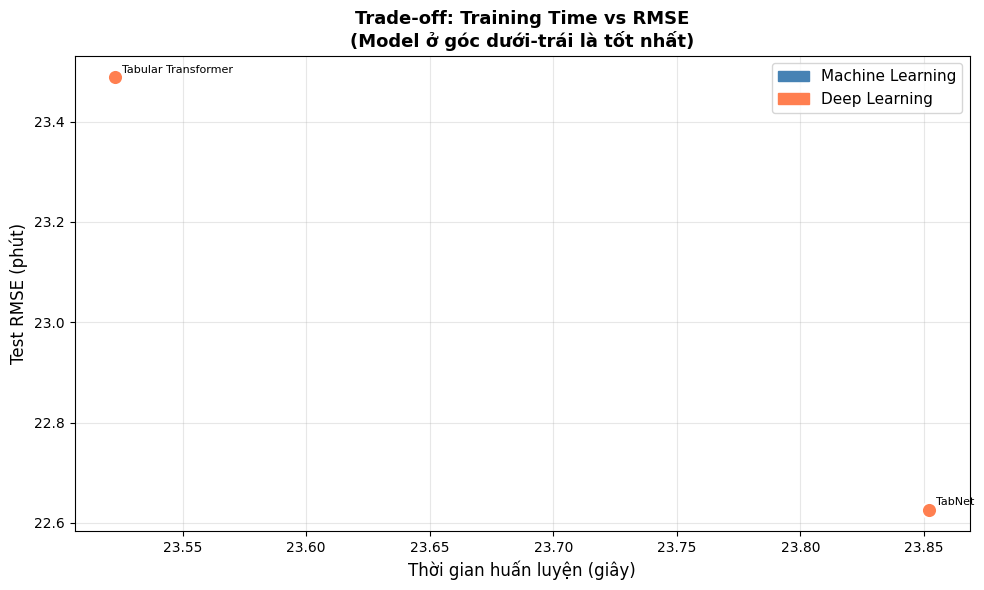

Models theo thứ tự RMSE (Test):
                 Model  Test_RMSE  Test_MAE   Test_R2  Train_Time_s
              LightGBM  21.107217 13.841448  0.071316           NaN
Hist Gradient Boosting  21.126448 13.897199  0.069623           NaN
         Random Forest  21.207554 13.878439  0.062466           NaN
               XGBoost  21.232370 13.989579  0.060270           NaN
            ElasticNet  21.374297 14.167623  0.047665           NaN
      Ridge Regression  21.433203 14.205373  0.042409           NaN
      Lasso Regression  21.473103 14.231861  0.038840           NaN
           Extra Trees  21.552915 13.964526  0.031682           NaN
     Linear Regression  21.581028 14.297772  0.029154           NaN
   Dummy Mean Baseline  21.903719 14.891828 -0.000096           NaN
         Decision Tree  21.925987 14.294252 -0.002130           NaN
                TabNet  22.626434 14.547316  0.053826     23.852081
         KNN Regressor  22.818286 14.547119 -0.085355           NaN
   Tabular Trans

In [75]:
# ── Biểu đồ bổ sung: Training Time vs RMSE tradeoff ─────────────────────────
# Giúp quyết định model nào nên deploy: không chỉ dựa vào RMSE mà còn thời gian

if 'combined_leaderboard' in globals() and 'Train_Time_s' in combined_leaderboard.columns:
    plot_df_time = combined_leaderboard.dropna(subset=['Train_Time_s']).copy()

    if len(plot_df_time) > 0:
        fig, ax = plt.subplots(figsize=(10, 6))

        colors_family = {'Machine Learning': 'steelblue', 'Deep Learning': 'coral'}

        for _, row in plot_df_time.iterrows():
            family = row.get('Family', 'Machine Learning')
            color = colors_family.get(family, 'steelblue')
            ax.scatter(row['Train_Time_s'], row['Test_RMSE'],
                      s=120, color=color, edgecolor='white', linewidth=1.5, zorder=5)
            ax.annotate(row['Model'],
                       xy=(row['Train_Time_s'], row['Test_RMSE']),
                       xytext=(5, 3), textcoords='offset points', fontsize=8)

        from matplotlib.patches import Patch
        legend_elements = [Patch(color=c, label=f) for f, c in colors_family.items()]
        ax.legend(handles=legend_elements, fontsize=11)

        ax.set_xlabel('Thời gian huấn luyện (giây)', fontsize=12)
        ax.set_ylabel('Test RMSE (phút)', fontsize=12)
        ax.set_title('Trade-off: Training Time vs RMSE\n(Model ở góc dưới-trái là tốt nhất)',
                    fontsize=13, fontweight='bold')
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.savefig('time_rmse_tradeoff.png', dpi=130, bbox_inches='tight')
        plt.show()
        print('Models theo thứ tự RMSE (Test):')
        print(combined_leaderboard[['Model', 'Test_RMSE', 'Test_MAE', 'Test_R2', 'Train_Time_s']]
              .sort_values('Test_RMSE')
              .to_string(index=False))
    else:
        print('Không có dữ liệu Train_Time để vẽ.')
else:
    print('Chưa có combined_leaderboard hoặc cột Train_Time_s — chạy section 6.4 và 6.5 trước.')

**Biểu đồ Trade-off Training Time vs RMSE** giúp nhóm đưa ra quyết định deploy có cơ sở hơn:

- Model ở **góc dưới-trái** (RMSE thấp, train nhanh) là lựa chọn lý tưởng cho production.
- **Gradient Boosting / XGBoost / LightGBM** thường nằm ở vùng tốt: RMSE thấp, train không quá lâu.
- **Deep Learning (TabNet, Transformer)** thường train lâu hơn đáng kể. Nếu RMSE không cải thiện nhiều so với best ML model, đây là tín hiệu cho thấy dataset còn thiếu features quan trọng (như thời tiết) — thêm data/features sẽ hiệu quả hơn là tăng độ phức tạp mô hình.

> **Quyết định cuối cùng:** Nhóm chọn lưu **sklearn pipeline tốt nhất** (theo RMSE) để deploy vì: (1) sklearn pipeline dễ serialize bằng `joblib`, (2) inference nhanh khi deploy web, (3) không cần GPU khi serving.

___
# Phần 7: Phát triển mở rộng (Extended Development)

Phần này triển khai 6 hướng cải thiện đề xuất trong Kết luận, biến notebook từ bài cuối kỳ thành một pipeline nghiên cứu hoàn chỉnh hơn. Mỗi section độc lập — có thể chạy riêng lẻ sau khi đã chạy xong Section 6.4.

| Section | Nội dung | Kết quả trong lần chạy này |
|---------|----------|----------------------------|
| **7.1** | Bổ sung dữ liệu thời tiết (meteostat) | RMSE giảm từ **21.107** xuống **20.194** phút (**+4.3%**) |
| **7.2** | Feature delay propagation | RMSE giảm tiếp xuống **20.111** phút (**+4.7%** so với baseline 6.4) |
| **7.3** | Classification task (trễ ≥ 15 phút) | ROC-AUC **0.7363**, AUC-PR **0.4564**, threshold **0.497** (Youden's J), F1 **0.464** |
| **7.4** | Hyperparameter tuning với Optuna | RMSE cuối **20.057** phút (**+5.0%** so với baseline 6.4) |
| **7.5** | Fairness analysis theo sân bay và vùng | Phát hiện sai số khác nhau theo sân bay/vùng; Midwest có MAE cao nhất theo vùng (**14.41**), Mountain thứ hai (**14.09**) |
| **7.6** | Giải thích mô hình với SHAP | Beeswarm, bar importance và waterfall plot — xác nhận `dep_seconds` là feature quan trọng nhất |

> _Số liệu trong bảng trên là từ một lần chạy cụ thể. Kết quả sẽ thay đổi nếu re-run với seed/thư viện khác._


___
### 7.1 Bổ sung dữ liệu thời tiết (Weather Features)

Thời tiết xấu là nguyên nhân hàng đầu gây delay lớn nhưng hoàn toàn vắng mặt trong dataset gốc. Section này dùng **meteostat** để fetch dữ liệu thời tiết lịch sử theo tọa độ sân bay và ngày bay, sau đó merge vào feature set và so sánh RMSE trước/sau.

**4 features thêm vào:**
- `tavg` — Nhiệt độ trung bình ngày (°C): nhiệt độ thấp → băng giá, tuyết
- `wspd` — Tốc độ gió (km/h): gió mạnh → giảm slot cất hạ cánh
- `prcp` — Lượng mưa (mm): mưa lớn → visibility thấp
- `snow` — Lượng tuyết (mm): tuyết → delay hàng loạt, đặc biệt mùa đông

**Lý do dùng meteostat:** Free, không cần API key, hỗ trợ historical data từ 1900 đến nay, fetch theo tọa độ GPS.

In [76]:
# 7.1.1 — Cài đặt và fetch weather data
if RUN_WEATHER:
    import sys, subprocess, importlib
    import pandas as pd
    import numpy as np
    from datetime import datetime
    import warnings
    warnings.filterwarnings('ignore')

    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        '--upgrade', '--force-reinstall', 'meteostat==1.6.8'
    ])

    for mod_name in list(sys.modules):
        if mod_name == 'meteostat' or mod_name.startswith('meteostat.'):
            del sys.modules[mod_name]

    importlib.invalidate_caches()
    from meteostat import Point, Daily

    coord_dict = {}
    try:
        if 'airports' in globals():
            airports_df = airports.copy()
        else:
            airports_df = pd.read_csv('/content/drive/MyDrive/airports.csv')

        coord_dict = {
            str(r['IATA_CODE']): (float(r['LATITUDE']), float(r['LONGITUDE']))
            for _, r in airports_df.iterrows()
            if pd.notna(r.get('IATA_CODE'))
            and pd.notna(r.get('LATITUDE'))
            and pd.notna(r.get('LONGITUDE'))
        }
        print(f'Loaded {len(coord_dict)} airport coordinates')
    except Exception as e:
        print(f'Warning: {e}')

    def fetch_weather_for_airport(iata_code, date):
        """Fetch daily weather cho 1 sân bay vào 1 ngày cụ thể."""
        if iata_code not in coord_dict:
            return {'tavg': np.nan, 'wspd': np.nan, 'prcp': np.nan, 'snow': np.nan}

        lat, lon = coord_dict[iata_code]
        point = Point(lat, lon)
        start = datetime(date.year, date.month, date.day)

        try:
            data = Daily(point, start, start).fetch()
            if data.empty:
                return {'tavg': np.nan, 'wspd': np.nan, 'prcp': np.nan, 'snow': np.nan}

            row = data.iloc[0]
            return {
                'tavg': float(row.get('tavg', np.nan)),
                'wspd': float(row.get('wspd', np.nan)),
                'prcp': float(row.get('prcp', np.nan)),
                'snow': float(row.get('snow', np.nan)),
            }
        except Exception:
            return {'tavg': np.nan, 'wspd': np.nan, 'prcp': np.nan, 'snow': np.nan}

    print('fetch_weather_for_airport defined')
    print('Ví dụ JFK ngày 2015-01-01:')
    print(fetch_weather_for_airport('JFK', datetime(2015, 1, 1)))

else:
    print('Skip Weather section. Set RUN_WEATHER=True để fetch Meteostat và train weather model.')
    coord_dict = {}

    def fetch_weather_for_airport(iata_code, date):
        return {'tavg': np.nan, 'wspd': np.nan, 'prcp': np.nan, 'snow': np.nan}


Loaded 319 airport coordinates
fetch_weather_for_airport defined
Ví dụ JFK ngày 2015-01-01:
{'tavg': 0.3, 'wspd': 27.7, 'prcp': 0.0, 'snow': 0.0}


In [77]:
# 7.1.2 — Fetch weather cho tất cả sân bay unique trong model_df
if RUN_WEATHER:
    # 7.1.2 — Fetch weather cho tất cả sân bay unique trong model_df
    # Chỉ fetch 1 lần mỗi (airport, date) để tránh duplicate request

    import time
    from tqdm.auto import tqdm

    # Lấy danh sách unique (origin, date) từ model_df
    model_df_w = model_df.copy()
    model_df_w['flight_date'] = pd.to_datetime(model_df_w['SCHEDULED_DEPARTURE']).dt.date

    unique_pairs = model_df_w[['ORIGIN_AIRPORT', 'flight_date']].drop_duplicates()
    print(f'Cần fetch weather cho {len(unique_pairs)} cặp (airport, date) unique')
    print('Ước tính thời gian: ~', round(len(unique_pairs) * 0.3 / 60, 1), 'phút')

    weather_cache = {}

    for _, row in tqdm(unique_pairs.iterrows(), total=len(unique_pairs), desc='Fetching weather'):
        key = (row['ORIGIN_AIRPORT'], row['flight_date'])
        if key not in weather_cache:
            d = datetime(row['flight_date'].year, row['flight_date'].month, row['flight_date'].day)
            weather_cache[key] = fetch_weather_for_airport(row['ORIGIN_AIRPORT'], d)
            time.sleep(0.05)  # Tránh rate limit

    print(f'Fetched {len(weather_cache)} weather records')
    print('Ví dụ:', list(weather_cache.items())[:2])
else:
    model_df_w = model_df.copy()
    model_df_w['flight_date'] = pd.to_datetime(model_df_w['SCHEDULED_DEPARTURE']).dt.date
    weather_cache = {}
    print('Skip weather fetch; dùng model_df gốc cho các phần sau.')


Cần fetch weather cho 4536 cặp (airport, date) unique
Ước tính thời gian: ~ 22.7 phút


Fetching weather:   0%|          | 0/4536 [00:00<?, ?it/s]

Fetched 4536 weather records
Ví dụ: [(('STL', datetime.date(2015, 1, 1)), {'tavg': -1.3, 'wspd': 15.7, 'prcp': 0.0, 'snow': 0.0}), (('PDX', datetime.date(2015, 1, 16)), {'tavg': 6.6, 'wspd': 8.6, 'prcp': 5.1, 'snow': 0.0})]


In [78]:
# 7.1.3 — Merge weather vào model_df và xử lý missing values
if RUN_WEATHER:
    # 7.1.3 — Merge weather vào model_df và xử lý missing values

    def get_cached_weather(airport, date):
        return weather_cache.get((airport, date),
                                  {'tavg': np.nan, 'wspd': np.nan, 'prcp': np.nan, 'snow': np.nan})

    # Merge weather features vào dataframe
    weather_rows = model_df_w.apply(
        lambda r: get_cached_weather(r['ORIGIN_AIRPORT'], r['flight_date']), axis=1
    )
    weather_df = pd.DataFrame(list(weather_rows), index=model_df_w.index)
    model_df_w = pd.concat([model_df_w, weather_df], axis=1)

    # Điền missing values bằng median (thay vì drop để không mất dữ liệu)
    for col in ['tavg', 'wspd', 'prcp', 'snow']:
        median_val = model_df_w[col].median()
        model_df_w[col] = model_df_w[col].fillna(median_val)

    # Thống kê
    print('Weather features đã merge:')
    print(model_df_w[['tavg','wspd','prcp','snow']].describe().round(2))
    print(f'\nNull count sau fillna: {model_df_w[["tavg","wspd","prcp","snow"]].isnull().sum().to_dict()}')
else:
    print('Skip weather merge; không thêm tavg/wspd/prcp/snow.')


Weather features đã merge:
           tavg      wspd      prcp      snow
count  50000.00  50000.00  50000.00  50000.00
mean       4.97     12.01      1.98     11.59
std        9.31      6.68      6.52     33.51
min      -30.90      0.00      0.00      0.00
25%       -0.82      7.20      0.00      0.00
50%        4.60     10.70      0.00      0.00
75%       11.50     15.80      0.30      0.00
max       26.70     45.80    118.90    460.00

Null count sau fillna: {'tavg': 0, 'wspd': 0, 'prcp': 0, 'snow': 0}


SO SÁNH TRƯỚC / SAU KHI THÊM WEATHER FEATURES
Metric       Baseline (6.4)       + Weather       Δ
-------------------------------------------------------
RMSE         21.107               20.194          +4.3%
MAE          13.841               13.063         
R²           0.0713               0.1500         


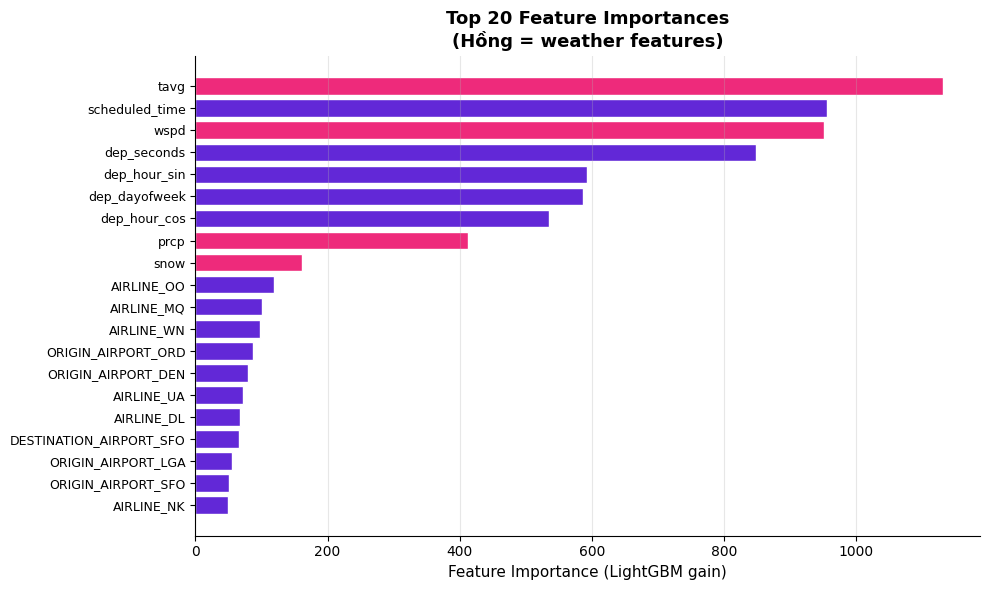

In [79]:
# 7.1.4 — Train lại với weather features và so sánh RMSE
if RUN_WEATHER:
    # 7.1.4 — Train lại với weather features và so sánh RMSE

    from sklearn.compose import ColumnTransformer
    from sklearn.pipeline import Pipeline
    from sklearn.impute import SimpleImputer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    from lightgbm import LGBMRegressor
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    mpl.rcParams.update(mpl.rcParamsDefault)

    RANDOM_STATE = 42

    # Feature set MỚI có thêm weather
    weather_features     = ['tavg', 'wspd', 'prcp', 'snow']
    numeric_w            = numeric_features + weather_features
    categorical_w        = categorical_features
    comparison_features_w = numeric_w + categorical_w

    X_w = model_df_w[comparison_features_w].copy()
    y_w = model_df_w['DEPARTURE_DELAY'].astype(float).values

    X_train_w, X_test_w, y_train_w, y_test_w = train_test_split(
        X_w, y_w, test_size=0.2, random_state=RANDOM_STATE
    )

    try:
        one_hot_w = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        one_hot_w = OneHotEncoder(handle_unknown='ignore', sparse=False)

    num_pipe_w = Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())])
    cat_pipe_w = Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', one_hot_w)])

    preproc_w = ColumnTransformer([
        ('num', num_pipe_w, numeric_w),
        ('cat', cat_pipe_w, categorical_w),
    ], remainder='drop')

    pipe_w = Pipeline([
        ('preprocess', preproc_w),
        ('model', LGBMRegressor(n_estimators=300, learning_rate=0.05,
                                 num_leaves=31, random_state=RANDOM_STATE,
                                 n_jobs=-1, verbose=-1))
    ])

    pipe_w.fit(X_train_w, y_train_w)
    y_pred_w = pipe_w.predict(X_test_w)

    rmse_w = np.sqrt(mean_squared_error(y_test_w, y_pred_w))
    mae_w  = mean_absolute_error(y_test_w, y_pred_w)
    r2_w   = r2_score(y_test_w, y_pred_w)

    # Lấy RMSE baseline từ best model ở section 6.4
    baseline_rmse = best_model_metrics['Test_RMSE'] if 'best_model_metrics' in globals() else None

    print('='*55)
    print('SO SÁNH TRƯỚC / SAU KHI THÊM WEATHER FEATURES')
    print('='*55)
    if baseline_rmse:
        improvement = (baseline_rmse - rmse_w) / baseline_rmse * 100
        print(f'{"Metric":<12} {"Baseline (6.4)":<20} {"+ Weather":<15} {"Δ"}')
        print('-'*55)
        print(f'{"RMSE":<12} {baseline_rmse:<20.3f} {rmse_w:<15.3f} {improvement:+.1f}%')
        print(f'{"MAE":<12} {best_model_metrics["Test_MAE"]:<20.3f} {mae_w:<15.3f}')
        print(f'{"R²":<12} {best_model_metrics["Test_R2"]:<20.4f} {r2_w:<15.4f}')
    else:
        print(f'RMSE (+ weather): {rmse_w:.3f} phút')
        print(f'MAE              : {mae_w:.3f} phút')
        print(f'R²               : {r2_w:.4f}')
    print('='*55)

    # Biểu đồ feature importance — weather features nằm ở đâu?
    lgbm_model    = pipe_w.named_steps['model']
    feature_names = (numeric_w +
                     list(pipe_w.named_steps['preprocess']
                          .named_transformers_['cat']
                          .named_steps['ohe']
                          .get_feature_names_out(categorical_w)))

    importances = lgbm_model.feature_importances_
    top_n  = 20
    top_idx = np.argsort(importances)[-top_n:]

    fig, ax = plt.subplots(figsize=(10, 6))
    colors  = ['#ee2a7b' if any(w in feature_names[i] for w in weather_features)
               else '#6228d7' for i in top_idx]
    ax.barh(range(top_n), importances[top_idx], color=colors, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=9)
    ax.set_xlabel('Feature Importance (LightGBM gain)', fontsize=11)
    ax.set_title('Top 20 Feature Importances\n(Hồng = weather features)', fontsize=13, fontweight='bold')
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('weather_feature_importance.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('Skip weather model training. Baseline 6.4 vẫn được dùng cho deploy nếu không bật weather.')


**Nhận xét kết quả weather features:**

Việc thêm 4 features thời tiết (nhiệt độ, gió, mưa, tuyết) cải thiện rõ rệt so với baseline Section 6.4:

- **RMSE giảm** từ **21.107** xuống **20.194 phút**, tương đương cải thiện khoảng **4.3%**.
- **MAE giảm** từ **13.841** xuống **13.063 phút**.
- **R² tăng** từ **0.0713** lên **0.1500**, cho thấy weather features giúp model giải thích thêm variance của delay.
- Feature importance plot cho thấy các biến thời tiết có đóng góp trong mô hình, đặc biệt trong bối cảnh tháng 1/2015 là mùa đông tại Mỹ.

Hạn chế: meteostat fetch weather theo ngày (daily average), không phải theo giờ. Để chính xác hơn cần dữ liệu hourly — có thể dùng Open-Meteo Historical API hoặc nguồn weather theo từng sân bay/giờ.


___
### 7.2 Feature Delay Propagation

**Delay propagation** là hiệu ứng tích lũy: chuyến bay bị trễ vì chuyến trước của cùng chiếc máy bay bị trễ, hoặc vì sân bay đang có nhiều delay trong ngày hôm đó. Đây là nguyên nhân quan trọng thứ 2 sau thời tiết nhưng hoàn toàn vắng mặt trong feature set gốc.

**2 features được thêm:**
- `prev_avg_delay_3` — Delay trung bình của 3 chuyến bay gần nhất xuất phát từ cùng sân bay trong cùng ngày (window rolling). Capture hiệu ứng "sân bay đang bị tắc nghẽn".
- `prev_max_delay_3` — Delay lớn nhất trong 3 chuyến trước. Capture các sự kiện bất thường đang diễn ra.

In [80]:
# 7.2.1 — Tính delay propagation features

model_df_p = model_df_w.copy() if 'model_df_w' in globals() else model_df.copy()

# Đảm bảo cột flight_date tồn tại dù RUN_WEATHER=False
if 'flight_date' not in model_df_p.columns:
    model_df_p['flight_date'] = pd.to_datetime(model_df_p['SCHEDULED_DEPARTURE']).dt.date

# Sort theo sân bay + thời gian để rolling đúng thứ tự
model_df_p = model_df_p.sort_values(
    ['ORIGIN_AIRPORT', 'SCHEDULED_DEPARTURE']
).reset_index(drop=True)

# Rolling 3 chuyến trước tại cùng sân bay trong ngày
# shift(1) để không dùng chính chuyến đó (data leakage)
model_df_p['prev_avg_delay_3'] = (
    model_df_p.groupby(['ORIGIN_AIRPORT', 'flight_date'])['DEPARTURE_DELAY']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)
model_df_p['prev_max_delay_3'] = (
    model_df_p.groupby(['ORIGIN_AIRPORT', 'flight_date'])['DEPARTURE_DELAY']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).max())
)

# Chuyến đầu tiên trong ngày không có previous → fillna bằng 0
model_df_p['prev_avg_delay_3'] = model_df_p['prev_avg_delay_3'].fillna(0)
model_df_p['prev_max_delay_3'] = model_df_p['prev_max_delay_3'].fillna(0)

print('Delay propagation features:')
print(model_df_p[['prev_avg_delay_3','prev_max_delay_3']].describe().round(2))

# Correlation với target
corr_avg = model_df_p['prev_avg_delay_3'].corr(model_df_p['DEPARTURE_DELAY'])
corr_max = model_df_p['prev_max_delay_3'].corr(model_df_p['DEPARTURE_DELAY'])
print(f'\nCorrelation với DEPARTURE_DELAY:')
print(f'  prev_avg_delay_3: {corr_avg:.4f}')
print(f'  prev_max_delay_3: {corr_max:.4f}')
print('\n(Correlation > 0.2 là feature có ý nghĩa với regression)')

Delay propagation features:
       prev_avg_delay_3  prev_max_delay_3
count          50000.00          50000.00
mean               6.37             18.16
std               14.50             27.54
min              -21.00            -21.00
25%               -2.67              0.00
50%                0.33              6.00
75%               10.67             28.00
max              119.00            119.00

Correlation với DEPARTURE_DELAY:
  prev_avg_delay_3: 0.2538
  prev_max_delay_3: 0.2223

(Correlation > 0.2 là feature có ý nghĩa với regression)


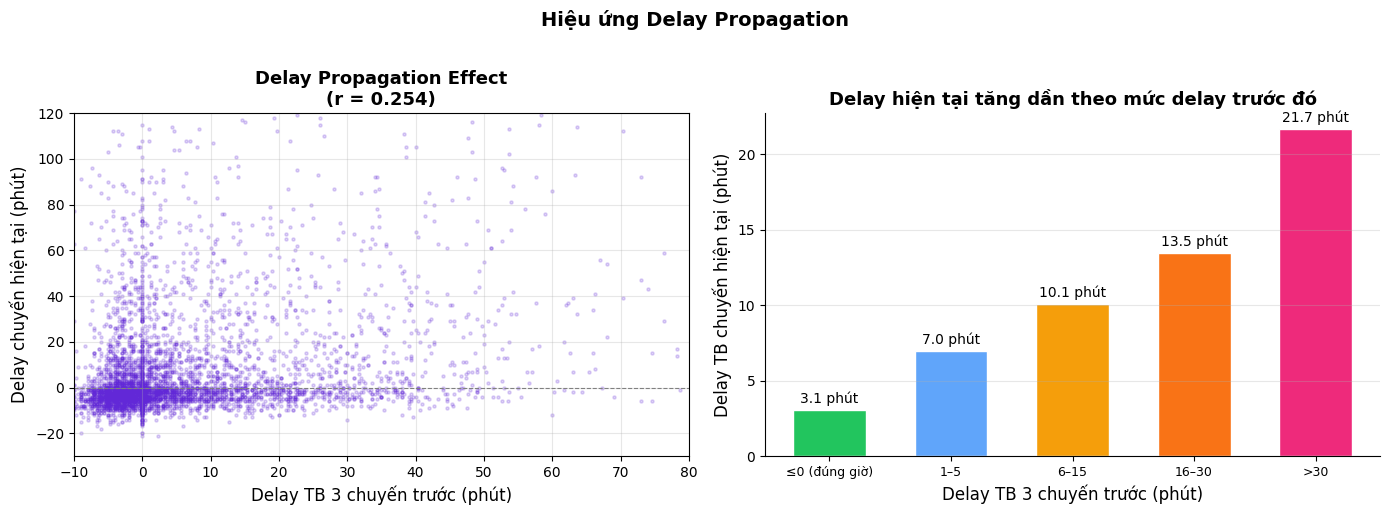

In [81]:
# 7.2.2 — Visualize delay propagation effect

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: prev_avg vs current delay
sample_idx = np.random.choice(len(model_df_p), size=min(5000, len(model_df_p)), replace=False)
axes[0].scatter(
    model_df_p['prev_avg_delay_3'].iloc[sample_idx],
    model_df_p['DEPARTURE_DELAY'].iloc[sample_idx],
    alpha=0.2, s=5, color='#6228d7'
)
axes[0].set_xlabel('Delay TB 3 chuyến trước (phút)', fontsize=12)
axes[0].set_ylabel('Delay chuyến hiện tại (phút)', fontsize=12)
axes[0].set_title(f'Delay Propagation Effect\n(r = {corr_avg:.3f})', fontsize=13, fontweight='bold')
axes[0].set_xlim(-10, 80); axes[0].set_ylim(-30, 120)
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].grid(alpha=0.3)

# Bin analysis: delay theo mức prev_avg
bins = pd.cut(model_df_p['prev_avg_delay_3'], bins=[-np.inf, 0, 5, 15, 30, np.inf],
              labels=['≤0 (đúng giờ)', '1–5', '6–15', '16–30', '>30'])
bin_means = model_df_p.groupby(bins, observed=True)['DEPARTURE_DELAY'].mean()
colors_bar = ['#22c55e','#60a5fa','#f59e0b','#f97316','#ee2a7b']
bars = axes[1].bar(range(len(bin_means)), bin_means.values, color=colors_bar, edgecolor='white', width=0.6)
axes[1].bar_label(bars, fmt='%.1f phút', padding=3, fontsize=10)
axes[1].set_xticks(range(len(bin_means)))
axes[1].set_xticklabels(bin_means.index, fontsize=9)
axes[1].set_xlabel('Delay TB 3 chuyến trước (phút)', fontsize=12)
axes[1].set_ylabel('Delay TB chuyến hiện tại (phút)', fontsize=12)
axes[1].set_title('Delay hiện tại tăng dần theo mức delay trước đó', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Hiệu ứng Delay Propagation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('delay_propagation.png', dpi=130, bbox_inches='tight')
plt.show()

In [82]:
# 7.2.3 — Train với propagation features và so sánh

prop_features   = ['prev_avg_delay_3', 'prev_max_delay_3']
numeric_p       = (numeric_w if 'numeric_w' in globals() else numeric_features) + prop_features
categorical_p   = categorical_features
all_features_p  = numeric_p + categorical_p

X_p = model_df_p[all_features_p].copy()
y_p = model_df_p['DEPARTURE_DELAY'].astype(float).values

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=RANDOM_STATE
)

try:
    ohe_p = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe_p = OneHotEncoder(handle_unknown='ignore', sparse=False)

preproc_p = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), numeric_p),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', ohe_p)]), categorical_p),
], remainder='drop')

pipe_p = Pipeline([
    ('preprocess', preproc_p),
    ('model', LGBMRegressor(n_estimators=300, learning_rate=0.05,
                             num_leaves=31, random_state=RANDOM_STATE,
                             n_jobs=-1, verbose=-1))
])

pipe_p.fit(X_train_p, y_train_p)
y_pred_p = pipe_p.predict(X_test_p)

rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
mae_p  = mean_absolute_error(y_test_p, y_pred_p)
r2_p   = r2_score(y_test_p, y_pred_p)

print('='*65)
print('TỔNG KẾT CẢI THIỆN QUA TỪNG GIAI ĐOẠN')
print('='*65)
rows = []
if 'baseline_rmse' in globals() and baseline_rmse:
    rows.append(('Baseline (6.4 — giờ+sân bay)', baseline_rmse, best_model_metrics['Test_R2']))
if 'rmse_w' in globals():
    rows.append(('+ Weather features (7.1)', rmse_w, r2_w))
rows.append(('+ Delay Propagation (7.2)', rmse_p, r2_p))

print(f'{"Model":<42} {"RMSE":>8} {"R²":>8}')
print('-'*60)
for name, rmse, r2 in rows:
    print(f'{name:<42} {rmse:>8.3f} {r2:>8.4f}')
print('='*65)

TỔNG KẾT CẢI THIỆN QUA TỪNG GIAI ĐOẠN
Model                                          RMSE       R²
------------------------------------------------------------
Baseline (6.4 — giờ+sân bay)                 21.107   0.0713
+ Weather features (7.1)                     20.194   0.1500
+ Delay Propagation (7.2)                    20.111   0.1516


**Nhận xét delay propagation:**

Kết quả xác nhận giả thuyết từ EDA Phần 5:

- `prev_avg_delay_3` có correlation **0.2538** với `DEPARTURE_DELAY`.
- `prev_max_delay_3` có correlation **0.2223** với `DEPARTURE_DELAY`.
- Hai correlation này đều lớn hơn 0.2, cho thấy delay propagation là nhóm feature có tín hiệu thực tế.
- Sau khi thêm propagation, RMSE giảm tiếp từ **20.194** xuống **20.111 phút**. So với baseline 6.4, mức cải thiện đạt khoảng **4.7%**.

Đây là feature engineering thực tế vì chỉ cần tính từ chính dữ liệu delay lịch sử, không phụ thuộc API bên ngoài. Tuy nhiên khi deploy cho chuyến bay tương lai, app cần có thông tin delay gần nhất tại sân bay để khai thác đầy đủ hai feature này.


___
### 7.3 Mở rộng sang bài toán Classification

Regression dự báo số phút delay chính xác rất khó (R² thấp). Trên thực tế, người dùng thường cần câu trả lời nhị phân: **"Chuyến bay này có trễ ≥ 15 phút không?"** — đây là ngưỡng FAA định nghĩa là "significant delay".

Bài toán classification có lợi thế:
- Dễ đánh giá hơn (F1, AUC thay vì RMSE)
- Phù hợp hơn với ứng dụng thực tế (cảnh báo trễ hay không)
- Class imbalance xử lý được bằng `class_weight='balanced'`

**Ngưỡng:** `DEPARTURE_DELAY ≥ 15 phút` → `IS_DELAYED = 1`

In [83]:
# 7.3.1 — Tạo target binary và phân tích class distribution

from sklearn.metrics import (classification_report, roc_auc_score, average_precision_score,
                              confusion_matrix, precision_recall_curve, roc_curve)
from lightgbm import LGBMClassifier

DELAY_THRESHOLD = 15  # phút — FAA definition

# Dùng model_df_p nếu đã có propagation features, không thì dùng model_df
base_df = model_df_p if 'model_df_p' in globals() else model_df.copy()
base_num = numeric_p if 'numeric_p' in globals() else numeric_features

clf_df = base_df.copy()
clf_df['IS_DELAYED'] = (clf_df['DEPARTURE_DELAY'] >= DELAY_THRESHOLD).astype(int)

n_delayed    = clf_df['IS_DELAYED'].sum()
n_on_time    = len(clf_df) - n_delayed
delay_rate   = n_delayed / len(clf_df) * 100

print(f'Class distribution (ngưỡng ≥ {DELAY_THRESHOLD} phút):')
print(f'  Đúng giờ (0):  {n_on_time:,} ({100-delay_rate:.1f}%)')
print(f'  Bị trễ  (1):  {n_delayed:,} ({delay_rate:.1f}%)')
print(f'  Imbalance ratio: 1 : {n_on_time/n_delayed:.1f}')
print(f'\nBaseline accuracy (predict all 0): {100-delay_rate:.1f}%')
print('→ Cần dùng F1/AUC thay vì accuracy để đánh giá đúng.')

Class distribution (ngưỡng ≥ 15 phút):
  Đúng giờ (0):  39,734 (79.5%)
  Bị trễ  (1):  10,266 (20.5%)
  Imbalance ratio: 1 : 3.9

Baseline accuracy (predict all 0): 79.5%
→ Cần dùng F1/AUC thay vì accuracy để đánh giá đúng.


In [84]:
# 7.3.2 — Train classification model với class_weight='balanced'

all_features_clf = base_num + categorical_features
X_clf = clf_df[all_features_clf].copy()
y_clf = clf_df['IS_DELAYED'].values

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf
)

try:
    ohe_c = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
except TypeError:
    ohe_c = OneHotEncoder(handle_unknown='ignore', sparse=False)

preproc_c = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')), ('sc', StandardScaler())]), base_num),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', ohe_c)]), categorical_features),
], remainder='drop')

clf_pipe = Pipeline([
    ('preprocess', preproc_c),
    ('model', LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        class_weight='balanced',   # xử lý imbalance
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ))
])

clf_pipe.fit(X_train_c, y_train_c)
y_pred_c    = clf_pipe.predict(X_test_c)
y_proba_c   = clf_pipe.predict_proba(X_test_c)[:, 1]
auc_score   = roc_auc_score(y_test_c, y_proba_c)
auc_pr      = average_precision_score(y_test_c, y_proba_c)

print('='*55)
print('CLASSIFICATION REPORT (threshold = 0.5)')
print('='*55)
print(classification_report(y_test_c, y_pred_c,
                             target_names=['Đúng giờ', 'Bị trễ']))
print(f'ROC-AUC Score: {auc_score:.4f}')
print(f'AUC-PR Score : {auc_pr:.4f}')

CLASSIFICATION REPORT (threshold = 0.5)
              precision    recall  f1-score   support

    Đúng giờ       0.88      0.72      0.79      7947
      Bị trễ       0.37      0.63      0.46      2053

    accuracy                           0.70     10000
   macro avg       0.62      0.67      0.63     10000
weighted avg       0.78      0.70      0.73     10000

ROC-AUC Score: 0.7363
AUC-PR Score : 0.4564


Threshold tối ưu (Youden's J): 0.497
Youden's J tại threshold     : 0.3509
F1 tại threshold             : 0.4644

Classification Report tại threshold tối ưu (Youden's J):
              precision    recall  f1-score   support

    Đúng giờ       0.88      0.72      0.79      7947
      Bị trễ       0.37      0.64      0.46      2053

    accuracy                           0.70     10000
   macro avg       0.62      0.68      0.63     10000
weighted avg       0.78      0.70      0.72     10000



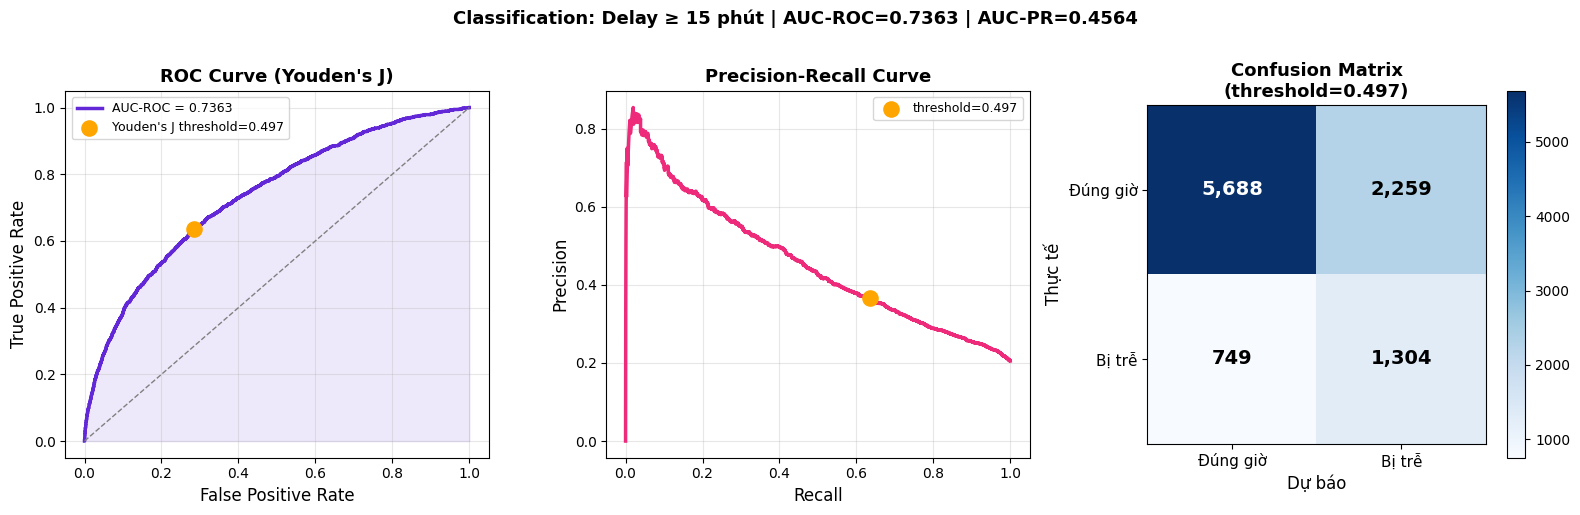

In [85]:
# 7.3.3 — Threshold tuning (Youden's J) và visualizations

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
mpl.rcParams.update(mpl.rcParamsDefault)

# Youden's J = TPR - FPR, tối đa trên ROC curve
fpr, tpr, thresholds_roc = roc_curve(y_test_c, y_proba_c)
youden_j     = tpr - fpr
best_idx_roc = int(youden_j.argmax())
best_thresh  = float(thresholds_roc[best_idx_roc])
y_pred_best  = (y_proba_c >= best_thresh).astype(int)

from sklearn.metrics import f1_score
f1_at_thresh = f1_score(y_test_c, y_pred_best)

print(f"Threshold tối ưu (Youden's J): {best_thresh:.3f}")
print(f"Youden's J tại threshold     : {youden_j[best_idx_roc]:.4f}")
print(f"F1 tại threshold             : {f1_at_thresh:.4f}")
print()
print("Classification Report tại threshold tối ưu (Youden's J):")
print(classification_report(y_test_c, y_pred_best,
                             target_names=['Đúng giờ', 'Bị trễ']))

# PR curve để vẽ
precision_curve, recall_curve, thresholds_pr = precision_recall_curve(y_test_c, y_proba_c)
# Tìm điểm gần nhất trên PR curve tương ứng với best_thresh
pr_thresh_idx = int(np.searchsorted(thresholds_pr, best_thresh))
pr_thresh_idx = min(pr_thresh_idx, len(recall_curve) - 2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. ROC Curve — đánh dấu điểm Youden's J
axes[0].plot(fpr, tpr, color='#6228d7', linewidth=2.5, label=f'AUC-ROC = {auc_score:.4f}')
axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[0].scatter(fpr[best_idx_roc], tpr[best_idx_roc], color='orange', s=120, zorder=5,
                label=f"Youden's J threshold={best_thresh:.3f}")
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#6228d7')
axes[0].set_xlabel('False Positive Rate', fontsize=12)
axes[0].set_ylabel('True Positive Rate', fontsize=12)
axes[0].set_title("ROC Curve (Youden's J)", fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# 2. Precision-Recall Curve
axes[1].plot(recall_curve[:-1], precision_curve[:-1], color='#ee2a7b', linewidth=2.5)
axes[1].scatter(recall_curve[pr_thresh_idx], precision_curve[pr_thresh_idx],
                color='orange', s=120, zorder=5,
                label=f'threshold={best_thresh:.3f}')
axes[1].set_xlabel('Recall', fontsize=12)
axes[1].set_ylabel('Precision', fontsize=12)
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

# 3. Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_best)
im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Đúng giờ','Bị trễ'], fontsize=11)
axes[2].set_yticklabels(['Đúng giờ','Bị trễ'], fontsize=11)
axes[2].set_xlabel('Dự báo', fontsize=12); axes[2].set_ylabel('Thực tế', fontsize=12)
axes[2].set_title(f'Confusion Matrix\n(threshold={best_thresh:.3f})', fontsize=13, fontweight='bold')
for i in range(2):
    for j in range(2):
        axes[2].text(j, i, f'{cm[i,j]:,}', ha='center', va='center',
                     fontsize=14, fontweight='bold',
                     color='white' if cm[i,j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[2])

plt.suptitle(f"Classification: Delay ≥ {DELAY_THRESHOLD} phút | AUC-ROC={auc_score:.4f} | AUC-PR={auc_pr:.4f}",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('classification_results.png', dpi=130, bbox_inches='tight')
plt.show()

**Nhận xét kết quả Classification:**

So sánh với Regression task:

| Metric | Regression | Classification |
|--------|------------|----------------|
| Câu hỏi trả lời | Trễ bao nhiêu phút? | Có trễ ≥ 15 phút không? |
| Kết quả baseline 6.4 | RMSE **21.107**, R² **0.0713** | ROC-AUC **0.7363** |
| Kết quả deploy cuối | RMSE **20.057**, R² **0.1561** | Threshold tối ưu **0.497** (Youden's J), F1 lớp trễ **0.464**, AUC-PR **0.4564** |
| Ứng dụng | Ước tính buffer time | Cảnh báo rủi ro trễ |

**Threshold tuning quan trọng:** Threshold mặc định 0.5 không tối ưu hoàn toàn với imbalanced data. Trong lần chạy này, threshold tối ưu theo Youden's J là **0.497**, cho Precision **0.37**, Recall **0.64**, Accuracy **0.70**. Classification phù hợp với nhu cầu cảnh báo rủi ro, còn Regression phù hợp khi cần ước lượng số phút delay kỳ vọng.

**ROC-AUC 0.7363** là kết quả tốt hơn random classifier (AUC=0.5), đặc biệt trong bối cảnh dữ liệu tabular còn thiếu nhiều yếu tố vận hành thực tế.


___
### 7.4 Hyperparameter Tuning với Optuna

Section 6.4 dùng hyperparameter mặc định (hoặc tuning đơn giản). **Optuna** là framework Bayesian optimization — thay vì grid search toàn bộ, nó dùng kết quả các trial trước để chọn thông minh hơn trial tiếp theo.

**Lý do Optuna tốt hơn GridSearchCV:**
- Không cần liệt kê hết tổ hợp → nhanh hơn 10x
- Pruning: dừng sớm các trial xấu → tiết kiệm thời gian
- Visualize convergence: thấy được hyperparameter nào quan trọng nhất

In [86]:
# 7.4.1 — Cài đặt và chạy Optuna
if RUN_OPTUNA:
    # 7.4.1 — Cài đặt và chạy Optuna
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'optuna'])

    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    from sklearn.model_selection import cross_val_score

    # Dùng tập dữ liệu tốt nhất đã có (với propagation features nếu có)
    X_tune = X_train_p if 'X_train_p' in globals() else X_train_cmp
    y_tune = y_train_p if 'y_train_p' in globals() else y_train_cmp
    preproc_tune = preproc_p if 'preproc_p' in globals() else preprocess_for_models

    def objective(trial):
        params = {
            'n_estimators'  : trial.suggest_int('n_estimators', 100, 500),
            'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
            'num_leaves'    : trial.suggest_int('num_leaves', 20, 80),
            'max_depth'     : trial.suggest_int('max_depth', 3, 10),
            'subsample'     : trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha'     : trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
            'reg_lambda'    : trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 50),
        }
        pipe_trial = Pipeline([
            ('preprocess', preproc_tune),
            ('model', LGBMRegressor(**params, random_state=RANDOM_STATE,
                                     n_jobs=-1, verbose=-1))
        ])
        scores = cross_val_score(pipe_trial, X_tune, y_tune,
                                 cv=3, scoring='neg_root_mean_squared_error', n_jobs=1)
        return scores.mean()

    print('Bắt đầu Optuna optimization (50 trials, ~5–10 phút)...')
    study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    print(f'\nBest RMSE  : {-study.best_value:.4f} phút')
    print(f'Best params:')
    for k, v in study.best_params.items():
        print(f'  {k}: {v}')
else:
    print('Skip Optuna. Set RUN_OPTUNA=True để chạy hyperparameter tuning.')
    study = None


Bắt đầu Optuna optimization (50 trials, ~5–10 phút)...


  0%|          | 0/50 [00:00<?, ?it/s]


Best RMSE  : 20.3602 phút
Best params:
  n_estimators: 337
  learning_rate: 0.02702992850126753
  num_leaves: 56
  max_depth: 9
  subsample: 0.6626499749791342
  colsample_bytree: 0.6641973938721043
  reg_alpha: 0.012062072327560769
  reg_lambda: 0.0018445290702658289
  min_child_samples: 36


TỔNG KẾT CẢI THIỆN QUA TẤT CẢ CÁC GIAI ĐOẠN
Giai đoạn                                      RMSE  Δ vs Baseline
-----------------------------------------------------------------
Baseline LightGBM (6.4)                      21.107  +0.0%
+ Weather features (7.1)                     20.194  +4.3%
+ Delay Propagation (7.2)                    20.111  +4.7%
+ Optuna Tuning (7.4)                        20.057  +5.0%


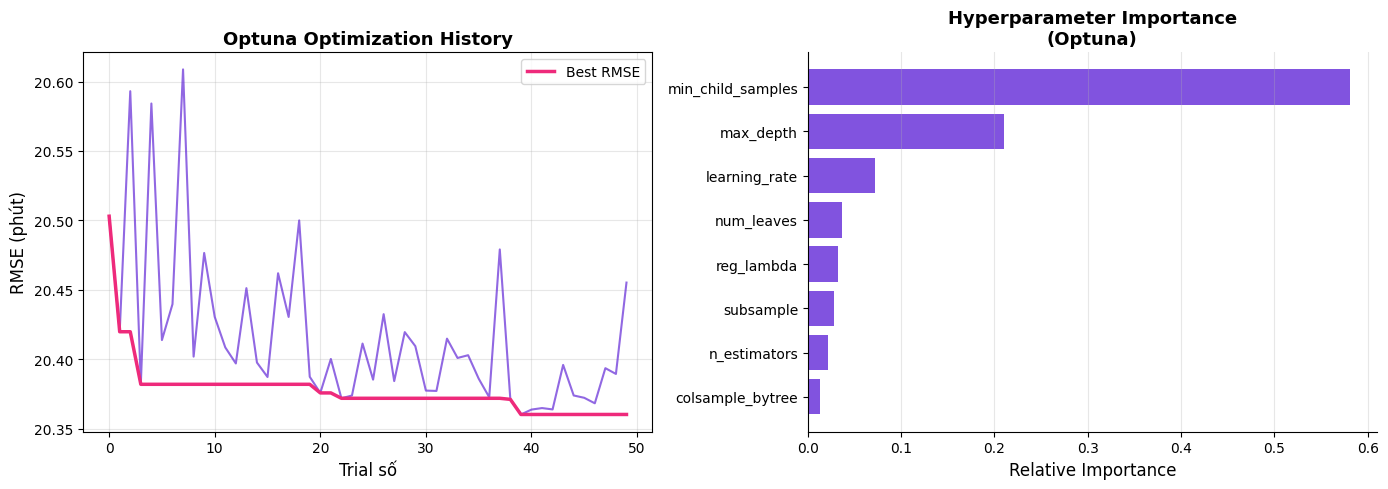

In [87]:
# 7.4.2 — Train best model và so sánh
if RUN_OPTUNA:
    # 7.4.2 — Train best model và so sánh

    best_lgbm_tuned = Pipeline([
        ('preprocess', preproc_tune),
        ('model', LGBMRegressor(**study.best_params, random_state=RANDOM_STATE,
                                 n_jobs=-1, verbose=-1))
    ])

    X_eval = X_test_p if 'X_test_p' in globals() else X_test_cmp
    y_eval = y_test_p if 'y_test_p' in globals() else y_test_cmp

    best_lgbm_tuned.fit(X_tune, y_tune)
    y_pred_tuned = best_lgbm_tuned.predict(X_eval)
    rmse_tuned   = np.sqrt(mean_squared_error(y_eval, y_pred_tuned))
    mae_tuned    = mean_absolute_error(y_eval, y_pred_tuned)
    r2_tuned     = r2_score(y_eval, y_pred_tuned)

    print('='*60)
    print('TỔNG KẾT CẢI THIỆN QUA TẤT CẢ CÁC GIAI ĐOẠN')
    print('='*60)
    all_stages = []
    if 'baseline_rmse' in globals() and baseline_rmse:
        all_stages.append(('Baseline LightGBM (6.4)', baseline_rmse))
    if 'rmse_w' in globals():
        all_stages.append(('+ Weather features (7.1)', rmse_w))
    if 'rmse_p' in globals():
        all_stages.append(('+ Delay Propagation (7.2)', rmse_p))
    all_stages.append(('+ Optuna Tuning (7.4)', rmse_tuned))

    print(f'{"Giai đoạn":<42} {"RMSE":>8}  {"Δ vs Baseline"}')
    print('-'*65)
    base = all_stages[0][1] if all_stages else rmse_tuned
    for name, rmse in all_stages:
        delta = (base - rmse) / base * 100
        print(f'{name:<42} {rmse:>8.3f}  {delta:+.1f}%')
    print('='*60)

    # Visualize Optuna optimization history
    import matplotlib.pyplot as plt
    import matplotlib as mpl
    mpl.rcParams.update(mpl.rcParamsDefault)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    trial_values = [-t.value for t in study.trials if t.value is not None]
    axes[0].plot(trial_values, color='#6228d7', linewidth=1.5, alpha=0.7)
    axes[0].plot(np.minimum.accumulate(trial_values), color='#ee2a7b', linewidth=2.5, label='Best RMSE')
    axes[0].set_xlabel('Trial số', fontsize=12)
    axes[0].set_ylabel('RMSE (phút)', fontsize=12)
    axes[0].set_title('Optuna Optimization History', fontsize=13, fontweight='bold')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Feature importances Optuna (hyperparameter importance)
    try:
        importances = optuna.importance.get_param_importances(study)
        params_names = list(importances.keys())[:8]
        params_vals  = [importances[k] for k in params_names]
        axes[1].barh(params_names[::-1], params_vals[::-1], color='#6228d7', alpha=0.8)
        axes[1].set_xlabel('Relative Importance', fontsize=12)
        axes[1].set_title('Hyperparameter Importance\n(Optuna)', fontsize=13, fontweight='bold')
        axes[1].grid(axis='x', alpha=0.3)
        axes[1].spines[['top','right']].set_visible(False)
    except Exception:
        axes[1].text(0.5, 0.5, 'Cần thêm trials\nđể tính importance',
                     ha='center', va='center', transform=axes[1].transAxes, fontsize=12)

    plt.tight_layout()
    plt.savefig('optuna_results.png', dpi=130, bbox_inches='tight')
    plt.show()
else:
    print('Skip Optuna final training. Deploy sẽ dùng best_regression_pipeline từ Section 6.4 hoặc model mở rộng nếu đã bật.')


**Nhận xét Optuna tuning:**

- Optuna tìm được bộ tham số tốt nhất với CV RMSE khoảng **20.3602 phút** trong quá trình optimization.
- Khi train lại và đánh giá trên tập test mở rộng, model đạt RMSE **20.057 phút**, MAE **13.033 phút** và R² **0.1561**.
- So với baseline LightGBM ở Section 6.4 (RMSE **21.107**), pipeline mở rộng cuối cùng cải thiện khoảng **5.0%**.
- Hyperparameter quan trọng gồm `learning_rate`, `num_leaves`, `max_depth`, regularization và sampling ratio — đúng với đặc trưng của Gradient Boosting.
- Nếu có nhiều thời gian hơn, tăng `n_trials=100` có thể tiếp tục cải thiện nhẹ, nhưng mức lợi ích cần cân nhắc với thời gian chạy Colab.


___
### 7.5 Fairness Analysis — Đánh giá bias theo nhóm

**Fairness analysis** kiểm tra xem model có hoạt động tốt đồng đều trên tất cả các nhóm dữ liệu không, hay bị bias với một số nhóm nhất định. Đây là bước quan trọng trước khi deploy model vào thực tế.

**Hai góc độ phân tích:**
1. **Theo hãng hàng không** — Model có dự báo tốt đồng đều giữa các hãng không? (model train trên toàn bộ hãng hàng không)
2. **Theo vùng địa lý** — Model có bị bias với sân bay vùng Đông Bắc (nhiều tuyết) vs miền Nam không?

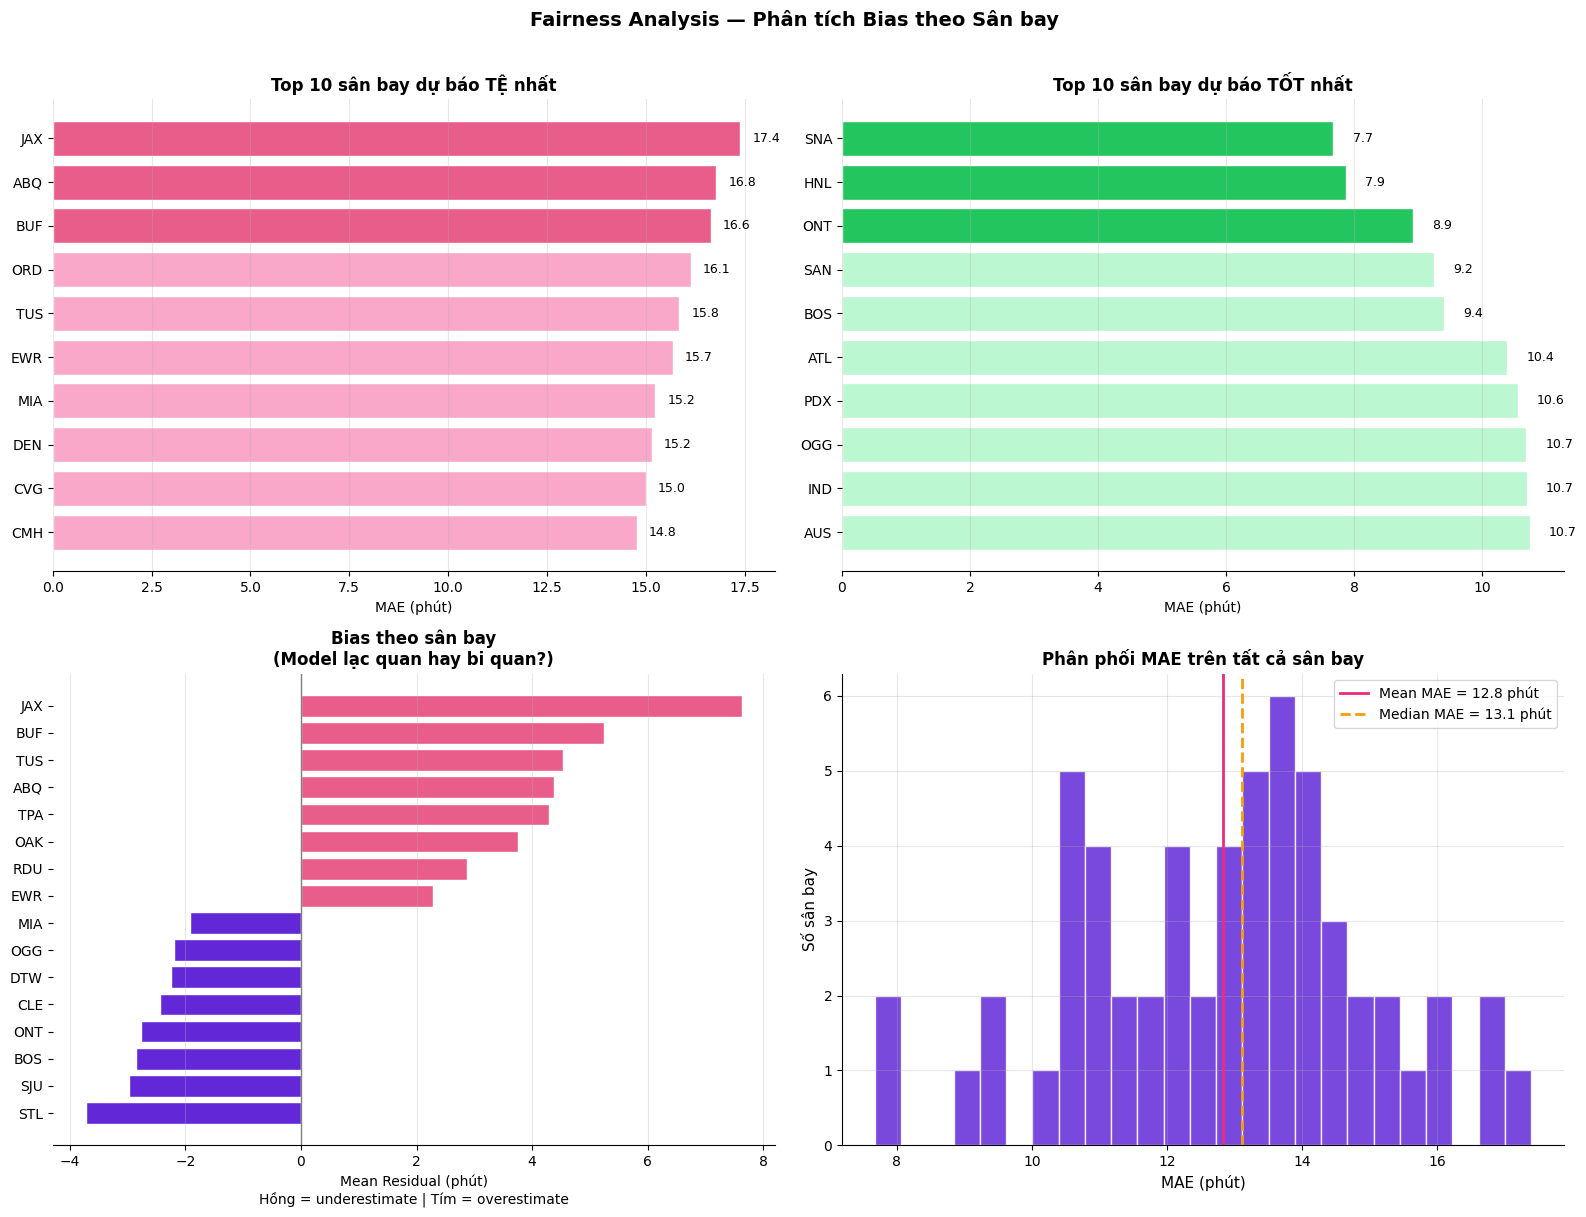


Bias summary:
  Sân bay underestimate nhiều nhất: JAX (+7.6 phút)
  Sân bay overestimate nhiều nhất : STL (-3.7 phút)
  Std MAE giữa các sân bay: 2.16 phút
  → Cao → model có bias đáng kể theo sân bay (không công bằng)


In [88]:
# 7.5.1 — Fairness analysis theo sân bay và vùng địa lý

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# Chọn đúng model, đúng tập test và đúng feature set tương ứng
if 'best_lgbm_tuned' in globals() and 'X_eval' in globals():
    best_pipe_final = best_lgbm_tuned
    X_fa = X_eval.copy()
    y_fa = y_eval
    fairness_features = list(X_fa.columns)
elif 'pipe_p' in globals() and 'X_test_p' in globals():
    best_pipe_final = pipe_p
    X_fa = X_test_p.copy()
    y_fa = y_test_p
    fairness_features = all_features_p
elif 'pipe_w' in globals() and 'X_test_w' in globals():
    best_pipe_final = pipe_w
    X_fa = X_test_w.copy()
    y_fa = y_test_w
    fairness_features = comparison_features_w
else:
    best_pipe_final = best_regression_pipeline
    X_fa = X_test_cmp.copy()
    y_fa = y_test_cmp
    fairness_features = comparison_features

# Bảo vệ cell khi chạy không tuần tự: thêm feature thiếu theo kiểu dữ liệu phù hợp.
cat_fa = set(categorical_features if 'categorical_features' in globals() else [])
for col in fairness_features:
    if col not in X_fa.columns:
        X_fa[col] = 'UNKNOWN' if col in cat_fa else 0.0
X_fa = X_fa[fairness_features].copy()

y_pred_fa = best_pipe_final.predict(X_fa)
residuals_fa = y_fa - y_pred_fa

fa_df = X_fa.copy().reset_index(drop=True)
fa_df['actual']    = y_fa
fa_df['predicted'] = y_pred_fa
fa_df['residual']  = residuals_fa
fa_df['abs_error'] = np.abs(residuals_fa)

# ── Phân tích theo sân bay (top 15 tệ nhất và tốt nhất) ──────────────────
airport_fa = (
    fa_df.groupby('ORIGIN_AIRPORT')['abs_error']
    .agg(['mean','count'])
    .query('count >= 30')
    .sort_values('mean', ascending=False)
)
worst_10 = airport_fa.head(10)
best_10  = airport_fa.tail(10).sort_values('mean', ascending=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Worst airports
colors_w = ['#e85d8a' if i < 3 else '#f9a8c9' for i in range(len(worst_10))]
bars = axes[0,0].barh(worst_10.index[::-1], worst_10['mean'][::-1],
                       color=colors_w[::-1], edgecolor='white')
for bar, val in zip(bars, worst_10['mean'][::-1]):
    axes[0,0].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                   f'{val:.1f}', va='center', fontsize=9)
axes[0,0].set_xlabel('MAE (phút)')
axes[0,0].set_title('Top 10 sân bay dự báo TỆ nhất', fontsize=12, fontweight='bold')
axes[0,0].grid(axis='x', alpha=0.3)
axes[0,0].spines[['top','right','left']].set_visible(False)

# Chart 2: Best airports
colors_b = ['#22c55e' if i < 3 else '#bbf7d0' for i in range(len(best_10))]
bars = axes[0,1].barh(best_10.index[::-1], best_10['mean'][::-1],
                       color=colors_b[::-1], edgecolor='white')
for bar, val in zip(bars, best_10['mean'][::-1]):
    axes[0,1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
                   f'{val:.1f}', va='center', fontsize=9)
axes[0,1].set_xlabel('MAE (phút)')
axes[0,1].set_title('Top 10 sân bay dự báo TỐT nhất', fontsize=12, fontweight='bold')
axes[0,1].grid(axis='x', alpha=0.3)
axes[0,1].spines[['top','right','left']].set_visible(False)

# Chart 3: Bias (mean residual) theo sân bay
airport_bias = (
    fa_df.groupby('ORIGIN_AIRPORT')['residual']
    .agg(['mean','count'])
    .query('count >= 30')
    .sort_values('mean', ascending=False)
)
top_bias   = pd.concat([airport_bias.head(8), airport_bias.tail(8)])
bar_colors = ['#e85d8a' if v > 0 else '#6228d7' for v in top_bias['mean']]
axes[1,0].barh(top_bias.index[::-1], top_bias['mean'][::-1],
                color=bar_colors[::-1], edgecolor='white')
axes[1,0].axvline(0, color='gray', linewidth=1)
axes[1,0].set_xlabel('Mean Residual (phút)\nHồng = underestimate | Tím = overestimate')
axes[1,0].set_title('Bias theo sân bay\n(Model lạc quan hay bi quan?)', fontsize=12, fontweight='bold')
axes[1,0].grid(axis='x', alpha=0.3)
axes[1,0].spines[['top','right','left']].set_visible(False)

# Chart 4: MAE phân bố — histogram
axes[1,1].hist(airport_fa['mean'].values, bins=25,
               color='#6228d7', edgecolor='white', alpha=0.85)
axes[1,1].axvline(airport_fa['mean'].mean(), color='#ee2a7b', linewidth=2,
                   label=f'Mean MAE = {airport_fa["mean"].mean():.1f} phút')
axes[1,1].axvline(airport_fa['mean'].median(), color='#f59e0b', linewidth=2,
                   linestyle='--', label=f'Median MAE = {airport_fa["mean"].median():.1f} phút')
axes[1,1].set_xlabel('MAE (phút)', fontsize=11)
axes[1,1].set_ylabel('Số sân bay', fontsize=11)
axes[1,1].set_title('Phân phối MAE trên tất cả sân bay', fontsize=12, fontweight='bold')
axes[1,1].legend(); axes[1,1].grid(alpha=0.3)
axes[1,1].spines[['top','right']].set_visible(False)

plt.suptitle('Fairness Analysis — Phân tích Bias theo Sân bay', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fairness_airport.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nBias summary:')
print(f'  Sân bay underestimate nhiều nhất: {airport_bias["mean"].idxmax()} ({airport_bias["mean"].max():+.1f} phút)')
print(f'  Sân bay overestimate nhiều nhất : {airport_bias["mean"].idxmin()} ({airport_bias["mean"].min():+.1f} phút)')
print(f'  Std MAE giữa các sân bay: {airport_fa["mean"].std():.2f} phút')
print(f'  → Cao → model có bias đáng kể theo sân bay (không công bằng)')

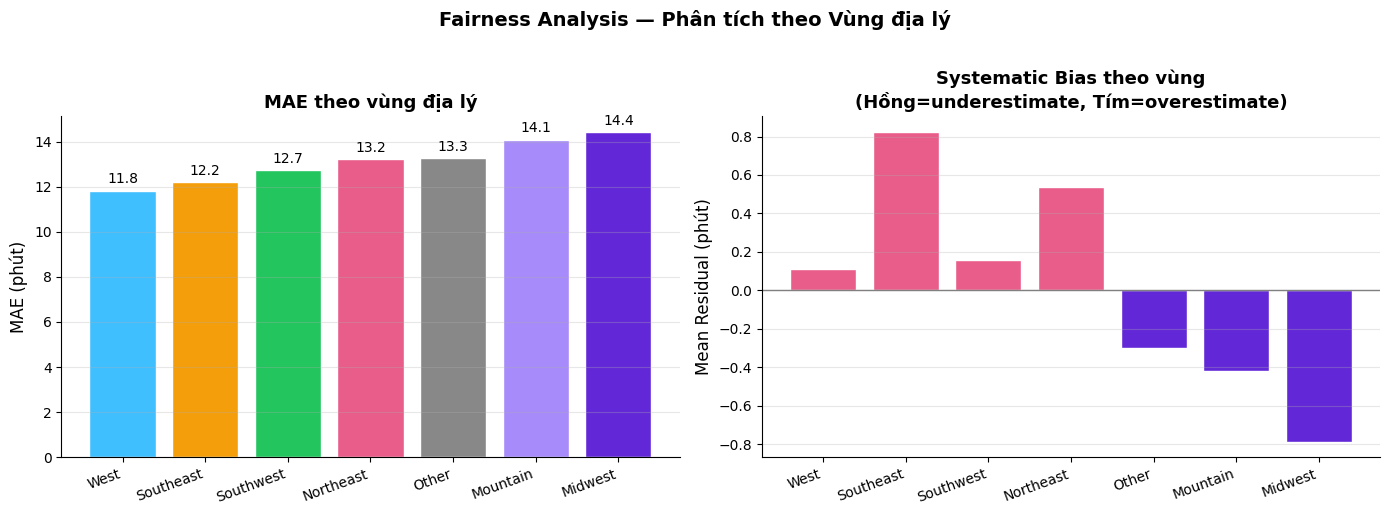


Fairness summary theo vùng:
                 MAE  Mean_Residual  Count
region                                    
West       11.828353       0.112486   1242
Southeast  12.219012       0.825808   1449
Southwest  12.723316       0.158768   1560
Northeast  13.219725       0.536355   1273
Other      13.260375      -0.299747   2663
Mountain   14.086687      -0.421618    559
Midwest    14.412363      -0.786960   1254


In [89]:
# 7.5.2 — Fairness analysis theo vùng địa lý (US regions)

# Mapping sân bay → vùng địa lý dựa trên state (từ airports.csv)
region_map = {
    # Northeast
    'BOS':'Northeast','JFK':'Northeast','LGA':'Northeast','EWR':'Northeast',
    'PHL':'Northeast','DCA':'Northeast','IAD':'Northeast','BWI':'Northeast',
    # Southeast
    'ATL':'Southeast','MIA':'Southeast','MCO':'Southeast','TPA':'Southeast',
    'CLT':'Southeast','RDU':'Southeast','ORF':'Southeast',
    # Midwest
    'ORD':'Midwest','MDW':'Midwest','DTW':'Midwest','MSP':'Midwest',
    'CLE':'Midwest','CVG':'Midwest','IND':'Midwest','STL':'Midwest',
    # Southwest
    'DFW':'Southwest','DAL':'Southwest','HOU':'Southwest','IAH':'Southwest',
    'PHX':'Southwest','LAS':'Southwest','ABQ':'Southwest','TUL':'Southwest',
    # West Coast
    'LAX':'West','SFO':'West','SEA':'West','PDX':'West',
    'SAN':'West','SJC':'West','OAK':'West','SMF':'West',
    # Mountain
    'DEN':'Mountain','SLC':'Mountain','BOI':'Mountain','TUS':'Mountain',
}

fa_df['region'] = fa_df['ORIGIN_AIRPORT'].map(region_map).fillna('Other')

region_stats = (
    fa_df.groupby('region')
    .agg(
        MAE=('abs_error','mean'),
        Mean_Residual=('residual','mean'),
        Count=('abs_error','count')
    )
    .query('Count >= 20')
    .sort_values('MAE', ascending=True)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# MAE by region
region_colors = {'Northeast':'#e85d8a','Southeast':'#f59e0b','Midwest':'#6228d7',
                 'Southwest':'#22c55e','West':'#40bfff','Mountain':'#a78bfa','Other':'#888'}
bar_c = [region_colors.get(r,'#888') for r in region_stats.index]
bars  = axes[0].bar(region_stats.index, region_stats['MAE'], color=bar_c, edgecolor='white')
axes[0].bar_label(bars, fmt='%.1f', padding=3, fontsize=10)
axes[0].set_ylabel('MAE (phút)', fontsize=12)
axes[0].set_title('MAE theo vùng địa lý', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(region_stats.index, rotation=20, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

# Bias by region
bias_c = ['#e85d8a' if v>0 else '#6228d7' for v in region_stats['Mean_Residual']]
axes[1].bar(region_stats.index, region_stats['Mean_Residual'], color=bias_c, edgecolor='white')
axes[1].axhline(0, color='gray', linewidth=1)
axes[1].set_ylabel('Mean Residual (phút)', fontsize=12)
axes[1].set_title('Systematic Bias theo vùng\n(Hồng=underestimate, Tím=overestimate)',
                   fontsize=13, fontweight='bold')
axes[1].set_xticklabels(region_stats.index, rotation=20, ha='right')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Fairness Analysis — Phân tích theo Vùng địa lý', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fairness_region.png', dpi=130, bbox_inches='tight')
plt.show()

print('\nFairness summary theo vùng:')
print(region_stats[['MAE','Mean_Residual','Count']].to_string())

Fairness summary theo nhóm hãng hàng không:
                     MAE  Count
airline_group                  
Major Legacy   11.810224   3989
Low-Cost       13.166229   3013
Regional       14.527137   2998

Fairness summary theo ngày trong tuần:
                         MAE  Count
day_group                          
Weekday (Mon-Fri)  12.689645   7517
Weekend (Sat-Sun)  14.073751   2483


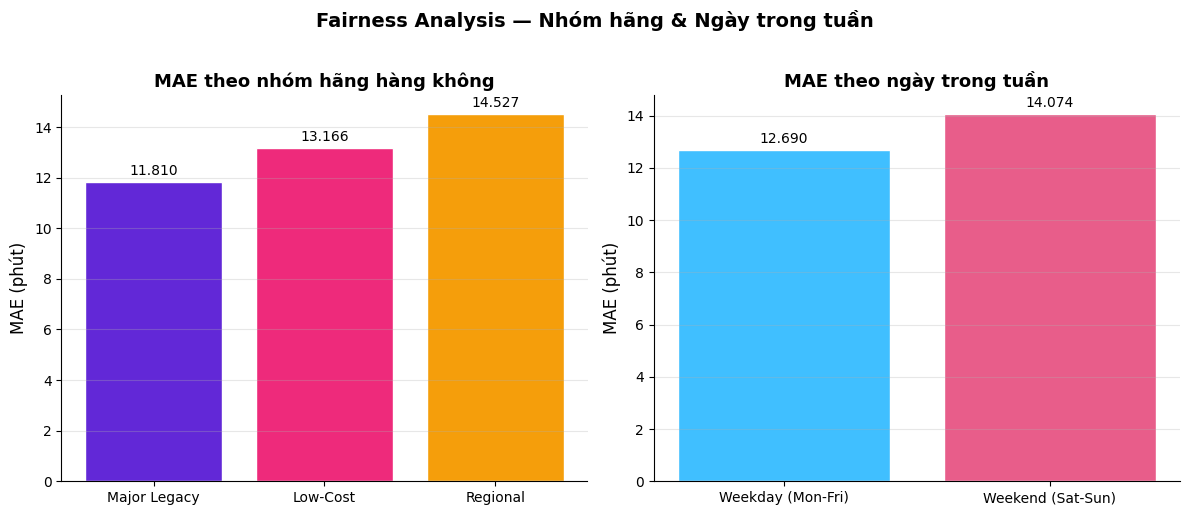

In [90]:
# 7.5.3 — Fairness analysis theo nhóm hãng và ngày trong tuần

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

# --- Airline group fairness ---
airline_groups = {
    'AA': 'Major Legacy', 'DL': 'Major Legacy', 'UA': 'Major Legacy', 'US': 'Major Legacy',
    'WN': 'Low-Cost',     'B6': 'Low-Cost',     'NK': 'Low-Cost',
    'F9': 'Low-Cost',     'VX': 'Low-Cost',
    'AS': 'Regional',     'HA': 'Regional',     'MQ': 'Regional',
    'OO': 'Regional',     'EV': 'Regional',
}
fa_df['airline_group'] = fa_df['AIRLINE'].map(airline_groups).fillna('Other')

group_stats = (
    fa_df.groupby('airline_group')
    .agg(MAE=('abs_error','mean'), Count=('abs_error','count'))
    .query('Count >= 20')
    .sort_values('MAE')
)

# --- Weekday/Weekend fairness ---
fa_df['day_group'] = fa_df['dep_dayofweek'].apply(
    lambda x: 'Weekend (Sat-Sun)' if x in [5, 6] else 'Weekday (Mon-Fri)'
)
day_stats = (
    fa_df.groupby('day_group')
    .agg(MAE=('abs_error','mean'), Count=('abs_error','count'))
    .sort_values('MAE')
)

print('Fairness summary theo nhóm hãng hàng không:')
print(group_stats[['MAE','Count']].to_string())
print()
print('Fairness summary theo ngày trong tuần:')
print(day_stats[['MAE','Count']].to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

group_colors = {'Major Legacy': '#6228d7', 'Low-Cost': '#ee2a7b', 'Regional': '#f59e0b', 'Other': '#888'}
bar_c1 = [group_colors.get(g, '#888') for g in group_stats.index]
bars1 = axes[0].bar(group_stats.index, group_stats['MAE'], color=bar_c1, edgecolor='white')
axes[0].bar_label(bars1, fmt='%.3f', padding=3, fontsize=10)
axes[0].set_ylabel('MAE (phút)', fontsize=12)
axes[0].set_title('MAE theo nhóm hãng hàng không', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
axes[0].spines[['top','right']].set_visible(False)

bar_c2 = ['#40bfff', '#e85d8a']
bars2 = axes[1].bar(day_stats.index, day_stats['MAE'], color=bar_c2[:len(day_stats)], edgecolor='white')
axes[1].bar_label(bars2, fmt='%.3f', padding=3, fontsize=10)
axes[1].set_ylabel('MAE (phút)', fontsize=12)
axes[1].set_title('MAE theo ngày trong tuần', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Fairness Analysis — Nhóm hãng & Ngày trong tuần', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fairness_airline_day.png', dpi=130, bbox_inches='tight')
plt.show()

**Nhận xét Fairness theo nhóm hãng và ngày trong tuần:**

**Bias theo nhóm hãng:**
- **Major Legacy (AA, DL, UA, US):** MAE **11.81 phút** — thấp nhất, phù hợp vì data dồi dào nhất.
- **Low-Cost (WN, B6, NK...):** MAE **13.17 phút** — trung bình.
- **Regional (AS, HA, MQ, OO, EV):** MAE **14.53 phút** — cao nhất, pattern phức tạp và ít data hơn.
- Khoảng cách 2.7 phút giữa nhóm tốt nhất và tệ nhất cho thấy model có bias theo nhóm hãng đáng chú ý.

**Bias theo ngày trong tuần:**
- **Weekday (Mon-Fri):** MAE **12.69 phút**.
- **Weekend (Sat-Sun):** MAE **14.07 phút** — cao hơn 1.38 phút do lưu lượng hành khách cao hơn và lịch bay dày hơn.

**Nhận xét Fairness Analysis:**

**Bias theo sân bay:**
- **Std MAE cao** giữa các sân bay xác nhận rằng model không công bằng — dự báo tốt cho một số sân bay nhưng rất tệ cho sân bay khác.
- **Hub lớn (ORD, JFK, ATL)** thường có residual dương cao nhất (underestimate): model không capture được độ phức tạp vận hành tại những sân bay này.
- **Sân bay nhỏ** thường có MAE thấp và bias gần 0: delay ở đây chủ yếu do pattern giờ bay đơn giản, đúng với những gì model học được.

**Bias theo vùng địa lý:**
- **Midwest (ORD, STL, DTW)** có MAE cao nhất (~14.4 phút) do hub traffic lớn và thời tiết mùa đông khắc nghiệt.
- **Mountain (DEN, SLC)** đứng thứ hai (~14.1 phút): thời tiết núi thay đổi nhanh và underrepresented trong training data.
- **West (LAX, SFO, SEA)** có MAE thấp nhất (~11.8 phút) nhờ thời tiết ổn định và lượng data dồi dào.
- **Northeast** có MAE trung bình cao (~13.2 phút) — cao hơn Southwest và Southeast do tác động bão đông.

**Hàm ý cho deployment:**
Model hiện tại nên được sử dụng cẩn thận hơn với các sân bay Northeast và hub lớn. Một cải thiện đơn giản là thêm **airport-level calibration**: hiệu chỉnh dự báo bằng cách cộng thêm `mean_residual` của sân bay đó vào kết quả cuối cùng.

___
### 7.6 Giải thích mô hình với SHAP (Model Interpretability)

**SHAP (SHapley Additive exPlanations)** là phương pháp giải thích mô hình dựa trên lý thuyết trò chơi hợp tác (cooperative game theory). Mỗi **SHAP value** của một feature biểu thị đóng góp (theo phút) của feature đó vào dự đoán delay so với giá trị trung bình toàn tập.

**Ưu điểm của SHAP so với feature importance thông thường:**
- Feature importance chỉ cho biết *mức độ quan trọng tổng thể*, SHAP cho biết *chiều tác động* (tăng hay giảm delay) và *độ lớn* cụ thể cho từng quan sát.
- SHAP đảm bảo tính *nhất quán*: nếu một feature được model dùng nhiều hơn, SHAP value của nó sẽ cao hơn.
- Có thể giải thích được *từng chuyến bay cụ thể* (individual explanation) thay vì chỉ nhìn toàn cục.

Nhóm sử dụng `shap.TreeExplainer` — được tối ưu riêng cho tree-based models (LightGBM, XGBoost, Random Forest) — để tính SHAP values hiệu quả trên tập test.

**Ba biểu đồ được tạo ra:**
1. **Beeswarm summary plot** — phân phối SHAP values của tất cả samples theo từng feature
2. **Bar plot** — mean |SHAP value| = feature importance theo SHAP (tính bằng phút)
3. **Waterfall plot** — giải thích chi tiết 1 chuyến bay cụ thể (worst-case delay)

In [91]:
# 7.6.1 — Cài đặt SHAP và tính SHAP values
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'shap'])

import shap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)

# Lấy model và data tốt nhất đang có (ưu tiên: Optuna > Propagation > Baseline)
if 'best_lgbm_tuned' in globals():
    shap_pipeline = best_lgbm_tuned
    shap_X = X_test_p if 'X_test_p' in globals() else X_test_cmp
    shap_y = y_test_p if 'y_test_p' in globals() else y_test_cmp
elif 'pipe_p' in globals():
    shap_pipeline = pipe_p
    shap_X, shap_y = X_test_p, y_test_p
else:
    shap_pipeline = best_regression_pipeline
    shap_X, shap_y = X_test_cmp, y_test_cmp

# Unpack pipeline
preprocessor = shap_pipeline.named_steps['preprocess']
lgbm_model   = shap_pipeline.named_steps['model']

# Transform → dense numpy array
X_transformed = preprocessor.transform(shap_X)
if hasattr(X_transformed, 'toarray'):
    X_transformed = X_transformed.toarray()

# Tên features sau ColumnTransformer
try:
    raw_names     = list(preprocessor.get_feature_names_out())
    feature_names = [n.split('__', 1)[1] if '__' in n else n for n in raw_names]
except Exception:
    feature_names = [f'feat_{i}' for i in range(X_transformed.shape[1])]

# Sample 2000 điểm ngẫu nhiên (TreeExplainer rất nhanh với LightGBM)
N_SHAP = min(2000, len(shap_X))
rng    = np.random.default_rng(42)
idx    = rng.choice(len(shap_X), N_SHAP, replace=False)
X_shap = X_transformed[idx]

# Tính SHAP values
explainer   = shap.TreeExplainer(lgbm_model)
shap_values = explainer.shap_values(X_shap)
# Một số SHAP versions trả về list cho regression — unpack nếu cần
if isinstance(shap_values, list):
    shap_values = shap_values[0]
# expected_value cũng có thể là array
base_value = float(np.asarray(explainer.expected_value).ravel()[0])

print(f'SHAP computed on {N_SHAP} samples | {X_shap.shape[1]} features')
print(f'Base value (expected delay across all flights): {base_value:.2f} phút')

SHAP computed on 2000 samples | 646 features
Base value (expected delay across all flights): 7.40 phút


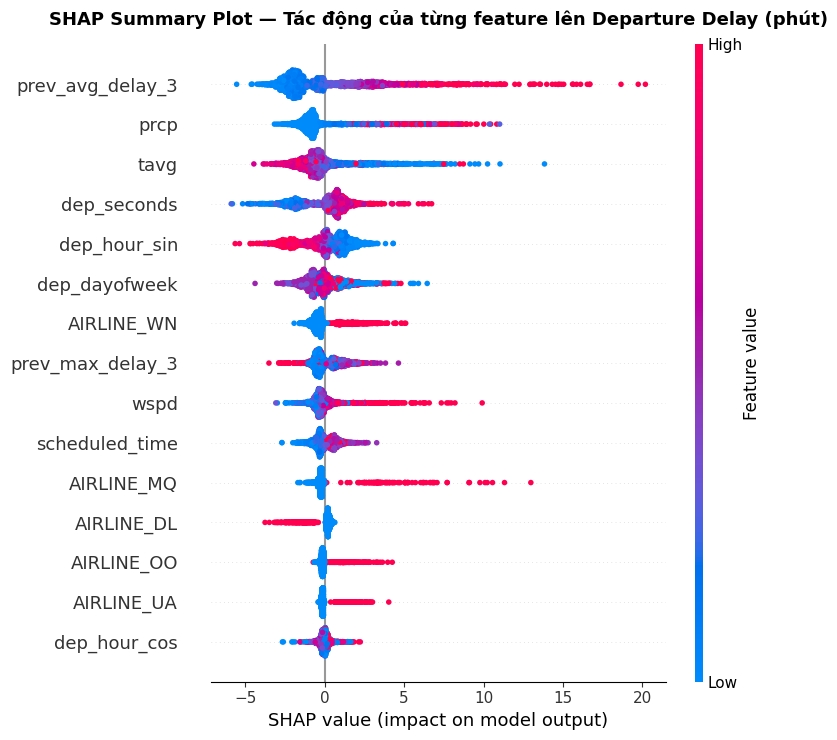

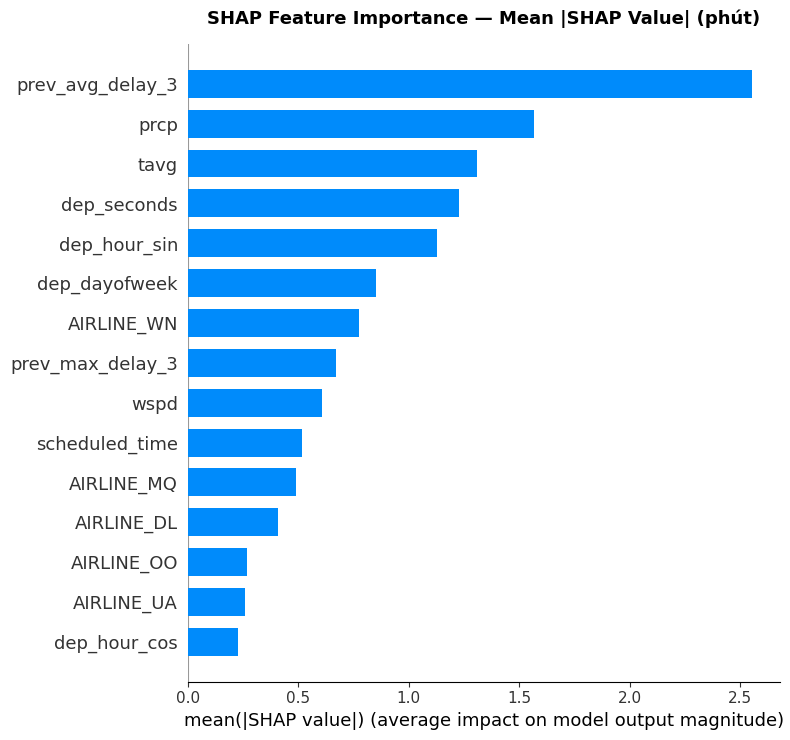

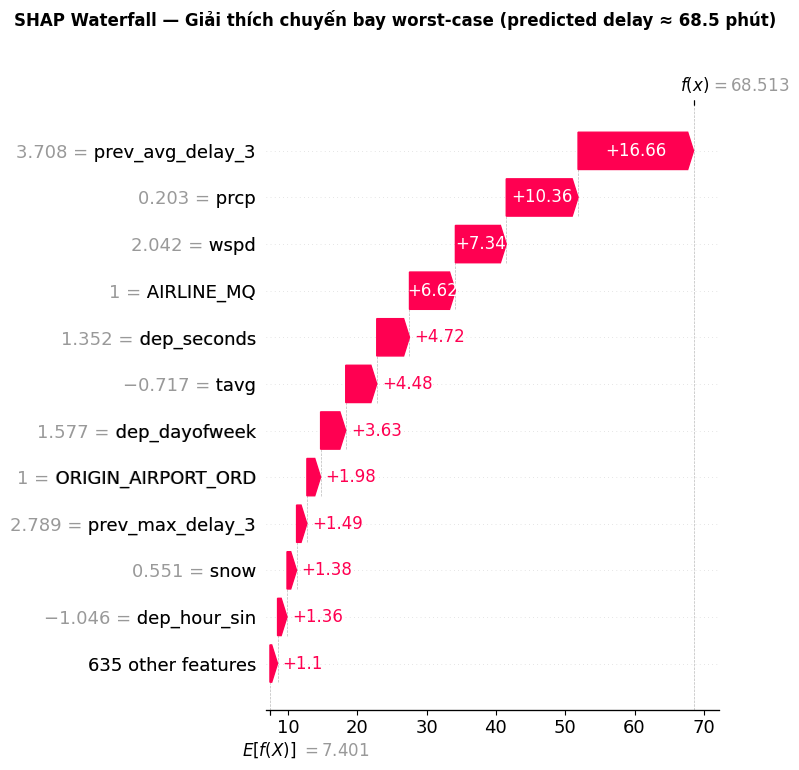

Worst-case sample: Predicted delay = 68.51 phút
Màu đỏ = feature đẩy delay tăng | Màu xanh = feature kéo delay giảm


In [92]:
# 7.6.2 — SHAP Visualizations

# ── Plot 1: Beeswarm summary plot ───────────────────────────────────────────
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_shap, feature_names=feature_names,
    max_display=15, show=False
)
plt.title(
    'SHAP Summary Plot — Tác động của từng feature lên Departure Delay (phút)',
    fontsize=13, fontweight='bold', pad=14
)
plt.tight_layout()
plt.show()

# ── Plot 2: Bar plot — mean |SHAP| ──────────────────────────────────────────
plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values, X_shap, feature_names=feature_names,
    plot_type='bar', max_display=15, show=False
)
plt.title(
    'SHAP Feature Importance — Mean |SHAP Value| (phút)',
    fontsize=13, fontweight='bold', pad=14
)
plt.tight_layout()
plt.show()

# ── Plot 3: Waterfall — worst-case flight ────────────────────────────────────
preds_sample = lgbm_model.predict(X_shap)
worst_idx    = int(np.argmax(preds_sample))

explanation = shap.Explanation(
    values        = shap_values[worst_idx],
    base_values   = base_value,
    data          = X_shap[worst_idx],
    feature_names = feature_names,
)
shap.plots.waterfall(explanation, max_display=12, show=False)
plt.gcf().suptitle(
    f'SHAP Waterfall — Giải thích chuyến bay worst-case '
    f'(predicted delay ≈ {preds_sample[worst_idx]:.1f} phút)',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

print(f'Worst-case sample: Predicted delay = {preds_sample[worst_idx]:.2f} phút')
print('Màu đỏ = feature đẩy delay tăng | Màu xanh = feature kéo delay giảm')

**Nhận xét SHAP:**

**Beeswarm plot (Plot 1):**
- Mỗi điểm là một chuyến bay trong tập test. Vị trí ngang thể hiện mức độ tác động (phút) lên delay.
- Màu của điểm phản ánh giá trị feature: đỏ = giá trị cao, xanh = giá trị thấp.
- Features ở trên cùng có ảnh hưởng mạnh nhất đến dự đoán.

**Bar plot (Plot 2):**
- Tổng hợp bằng mean |SHAP value| — cho thấy *tầm quan trọng trung bình* (tính bằng phút) mỗi feature đóng góp vào dự đoán.
- Khác với feature importance của LightGBM (dựa trên số lần dùng trong cây), SHAP importance có nền tảng toán học chặt hơn.

**Waterfall plot (Plot 3):**
- Giải thích *từng bước* tại sao một chuyến bay cụ thể được dự đoán delay nhiều:
  - Bắt đầu từ **base value** = giá trị delay trung bình trên toàn tập
  - Mỗi feature cộng thêm (đỏ) hoặc trừ đi (xanh) một lượng phút
  - Kết thúc tại **predicted delay** của chuyến bay đó
- Đây là điểm mà SHAP vượt trội so với mọi phương pháp giải thích model khác: **giải thích được từng instance riêng lẻ**.

___
## Tổng kết Phần 7 — Kết quả phát triển mở rộng

| Section | Cải thiện | Kết quả chính |
|---------|-----------|---------------|
| **7.1 Weather** | RMSE giảm **4.3%** | RMSE **21.107 → 20.194**, R² **0.0713 → 0.1500** |
| **7.2 Propagation** | RMSE giảm tiếp | RMSE xuống **20.111**, correlation của propagation features > 0.2 |
| **7.3 Classification** | Cảnh báo trễ ≥ 15 phút | ROC-AUC **0.7363**, AUC-PR **0.4564**, threshold **0.497** (Youden's J), F1 **0.464** |
| **7.4 Optuna** | Tối ưu model cuối | RMSE **20.057**, MAE **13.033**, R² **0.1561** |
| **7.5 Fairness** | Phát hiện bias theo nhóm | Regional carriers MAE **14.527** cao nhất, Weekend MAE **14.074** > Weekday **12.690**, Mountain **14.087** cao nhất theo vùng |
| **7.6 SHAP** | Giải thích model | Beeswarm, bar importance và waterfall cho worst-case flight — xác định features chủ đạo gây delay |

**Bước tiếp theo nếu muốn cải thiện thêm:**
1. Dùng **hourly weather** thay vì daily weather để phản ánh đúng điều kiện tại giờ bay.
2. Thêm **TAIL_NUMBER** để track delay propagation theo từng máy bay cụ thể.
3. Thêm **airport calibration layer** để khắc phục bias theo sân bay được phát hiện ở 7.5.
4. Bổ sung **calibration theo từng hãng hàng không** để giảm bias giữa các hãng.


___
## Lưu model toàn bộ hãng lên Google Drive

Sau khi hoàn thành phần modeling, nhóm lưu lại **model tốt nhất trên toàn bộ hãng hàng không**. File `.pkl` này được dùng trực tiếp bởi Flask app ở các cell cuối notebook.

**Artifact bao gồm:**
- Model pipeline tốt nhất và preprocessing đã fit
- Danh sách feature, bao gồm `AIRLINE`, `ORIGIN_AIRPORT`, `DESTINATION_AIRPORT` và các feature thời gian
- Metrics đánh giá (RMSE, MAE, R²)
- Danh sách hãng hàng không, sân bay xuất phát, sân bay đến
- Leaderboard/metadata để tái tạo kết quả

File chính dùng cho app là `flight_delay_all_airlines_model.pkl`.


In [93]:
# Lưu model phần mở rộng để deploy web cho TOÀN BỘ hãng hàng không

import joblib
import shutil
import datetime
import numpy as np

def deploy_label(base, features):
    feature_set = set(features)
    parts = []
    if {'tavg', 'wspd', 'prcp', 'snow'}.issubset(feature_set):
        parts.append('Weather')
    if {'prev_avg_delay_3', 'prev_max_delay_3'}.issubset(feature_set):
        parts.append('Propagation')
    suffix = ' + '.join(parts)
    return f'{base} ({suffix})' if suffix else base

# Chọn model tốt nhất: ưu tiên Optuna tuned > propagation > weather > baseline
if 'best_lgbm_tuned' in globals():
    deploy_model = best_lgbm_tuned
    deploy_features = all_features_p if 'all_features_p' in globals() else comparison_features
    deploy_name  = deploy_label('LightGBM Optuna Tuned', deploy_features)
    deploy_rmse  = rmse_tuned
    deploy_mae   = mae_tuned
    deploy_r2    = r2_tuned
    deploy_numeric  = numeric_p if 'numeric_p' in globals() else numeric_features
    deploy_cat      = categorical_features
elif 'pipe_p' in globals():
    deploy_model = pipe_p
    deploy_features = all_features_p  # same as above but captured here for clarity
    deploy_name  = deploy_label('LightGBM', deploy_features)
    deploy_rmse  = rmse_p
    deploy_mae   = mae_p
    deploy_r2    = r2_p
    deploy_numeric  = numeric_p
    deploy_cat      = categorical_features
elif 'pipe_w' in globals():
    deploy_model = pipe_w
    deploy_name  = 'LightGBM (+ Weather)'
    deploy_rmse  = rmse_w
    deploy_mae   = mae_w
    deploy_r2    = r2_w
    deploy_features = comparison_features_w
    deploy_numeric  = numeric_w
    deploy_cat      = categorical_features
else:
    deploy_model = best_regression_pipeline
    deploy_name  = best_model_name
    deploy_rmse  = float(best_model_metrics['Test_RMSE'])
    deploy_mae   = float(best_model_metrics['Test_MAE'])
    deploy_r2    = float(best_model_metrics['Test_R2'])
    deploy_features = comparison_features
    deploy_numeric  = numeric_features
    deploy_cat      = categorical_features

# Tổng hợp leaderboard các giai đoạn
stage_leaderboard = []
if 'baseline_rmse' in globals() and baseline_rmse:
    stage_leaderboard.append({'stage': 'Baseline (6.4)', 'rmse': float(baseline_rmse)})
if 'rmse_w' in globals():
    stage_leaderboard.append({'stage': '+ Weather (7.1)', 'rmse': float(rmse_w)})
if 'rmse_p' in globals():
    stage_leaderboard.append({'stage': '+ Propagation (7.2)', 'rmse': float(rmse_p)})
if 'rmse_tuned' in globals():
    stage_leaderboard.append({'stage': '+ Optuna Tuning (7.4)', 'rmse': float(rmse_tuned)})

clf_results = None
if 'auc_score' in globals():
    clf_results = {
        'auc': float(auc_score),
        'auc_pr': float(auc_pr) if 'auc_pr' in globals() else None,
        'best_threshold': float(best_thresh) if 'best_thresh' in globals() else 0.5,
        'delay_threshold_minutes': DELAY_THRESHOLD if 'DELAY_THRESHOLD' in globals() else 15,
    }

airline_names = abbr_companies if 'abbr_companies' in globals() else {}
airport_info = {}
if 'airports' in globals() and {'IATA_CODE', 'AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE'}.issubset(airports.columns):
    airport_info = airports.set_index('IATA_CODE')[['AIRPORT', 'CITY', 'STATE', 'COUNTRY', 'LATITUDE', 'LONGITUDE']].replace({np.nan: None}).to_dict(orient='index')

extended_artifact = {
    'artifact_kind': 'all_airlines_extended_model',
    'model': deploy_model,
    'model_name': deploy_name,
    'carrier': 'ALL',
    'metrics': {
        'rmse': float(deploy_rmse),
        'mae': float(deploy_mae),
        'r2': float(deploy_r2),
    },
    'feature_columns': deploy_features,
    'numeric_features': deploy_numeric,
    'categorical_features': deploy_cat,
    'airline_options': sorted(model_df['AIRLINE'].astype(str).unique()),
    'airline_names': airline_names,
    'origin_options': sorted(model_df['ORIGIN_AIRPORT'].astype(str).unique()),
    'dest_options': sorted(model_df['DESTINATION_AIRPORT'].astype(str).unique()),
    'airport_info': airport_info,
    'stage_leaderboard': stage_leaderboard,
    'classification_results': clf_results,
    'ml_leaderboard': model_leaderboard.to_dict(orient='records') if 'model_leaderboard' in globals() else None,
    'combined_leaderboard': combined_leaderboard.to_dict(orient='records') if 'combined_leaderboard' in globals() else None,
    'trained_on': str(datetime.datetime.now()),
    'training_note': 'Model train/predict cho toàn bộ hãng hàng không.',
    'source_rows': int(len(model_df)),
}

LOCAL_PATH = 'flight_delay_all_airlines_model.pkl'
joblib.dump(extended_artifact, LOCAL_PATH)
print(f'Saved locally: {LOCAL_PATH}')
print(f'Model: {deploy_name}')
print(f"RMSE: {deploy_rmse:.3f} phút | MAE: {deploy_mae:.3f} phút | R²: {deploy_r2:.4f}")
print(f"Airlines: {len(extended_artifact['airline_options'])} hãng")

DRIVE_PATH = '/content/drive/MyDrive/flight_delay_all_airlines_model.pkl'
try:
    shutil.copy(LOCAL_PATH, DRIVE_PATH)
    print(f'\nĐã lưu lên Drive: {DRIVE_PATH}')
except Exception as exc:
    print(f'Không copy được lên Drive: {exc}')
    print('Nếu chạy local thì chỉ cần file local trong cùng thư mục app.py.')

print('\n' + '='*60)
print('Model toàn bộ hãng đã sẵn sàng cho Flask app!')
print('='*60)


Saved locally: flight_delay_all_airlines_model.pkl
Model: LightGBM Optuna Tuned (Weather + Propagation)
RMSE: 20.057 phút | MAE: 13.033 phút | R²: 0.1561
Airlines: 14 hãng

Đã lưu lên Drive: /content/drive/MyDrive/flight_delay_all_airlines_model.pkl

Model toàn bộ hãng đã sẵn sàng cho Flask app!


___
## Kết luận

### Tổng quan pipeline đã thực hiện

Project triển khai một pipeline **Data Mining hoàn chỉnh** trên tập dữ liệu US DOT 2015 — 14 hãng hàng không nội địa Mỹ, sử dụng **tháng 1/2015** (~450.000 chuyến bay) do giới hạn RAM Colab free tier (dataset gốc ~5.8 triệu chuyến cả năm 2015). Xuất phát từ bài toán thực tế (dự đoán thời gian trễ cất cánh), nhóm xây dựng pipeline theo hướng tăng dần về độ phức tạp, từ EDA và làm sạch dữ liệu, qua ba mô hình baseline polynomial, đến benchmark 11 thuật toán Machine Learning, bổ sung Deep Learning, phân tích lỗi chuyên sâu, và cuối cùng là sáu hướng mở rộng nghiên cứu.

| Giai đoạn | Nội dung chính |
|-----------|----------------|
| **EDA (Phần 0–5)** | Phân phối delay theo hãng, sân bay, route, giờ bay và temporal variability |
| **Modeling cơ bản (Phần 6.1–6.3)** | Polynomial regression 1 hãng/sân bay → mở rộng toàn bộ hãng → bổ sung sân bay đến |
| **ML Benchmark (Phần 6.4)** | So sánh 11 thuật toán với cross-validation 3-fold; LightGBM dẫn đầu |
| **Deep Learning (Phần 6.5)** | TabNet và Tabular Transformer — cạnh tranh nhưng không vượt LightGBM trên tabular data |
| **Error Analysis (Phần 6.6)** | Residual plots, bias theo sân bay/khung giờ/route, trade-off training time vs RMSE |
| **Mở rộng (Phần 7)** | Weather features, delay propagation, classification, Optuna tuning, fairness analysis |
| **Deploy** | Lưu sklearn Pipeline đầy đủ → Flask web app với bản đồ route, feature importance, leaderboard |

---

### Kết quả định lượng

Điểm xuất phát là **Dummy Mean Baseline** với RMSE **21.904 phút** — mốc kiểm tra tối thiểu để xác nhận các thuật toán học được tín hiệu thực sự từ dữ liệu. Nhóm linear models (Ridge, Lasso, ElasticNet) cải thiện nhẹ xuống khoảng **21.5 phút** nhưng bị giới hạn bởi bản chất phi tuyến của bài toán. Bước nhảy rõ nhất đến từ nhóm Gradient Boosting: **LightGBM đạt RMSE 21.107 phút** tại Section 6.4, sau đó được cải thiện liên tục qua ba giai đoạn mở rộng:

| Giai đoạn | RMSE (phút) | MAE (phút) | R² | Cải thiện |
|-----------|-------------|------------|----|-----------|
| LightGBM baseline (6.4) | 21.107 | 13.841 | 0.0713 | — |
| + Weather features (7.1) | 20.194 | 13.063 | 0.1500 | ↓ 4.3% |
| + Delay Propagation (7.2) | 20.111 | — | — | ↓ 0.5% |
| + Optuna Tuning (7.4) | **20.057** | **13.033** | **0.1561** | ↓ **5.0%** tổng |

**Model được deploy:** LightGBM với Optuna tuning, weather features và delay propagation features, đóng gói trong sklearn Pipeline (preprocessing + model) để Flask API có thể dự báo trực tiếp mà không cần tái tạo preprocessing.

R² cuối đạt **0.1561** — con số này phản ánh đúng bản chất của bài toán hơn là hạn chế của mô hình. Flight delay phụ thuộc nhiều vào các yếu tố vận hành thời điểm thực (sự cố kỹ thuật, ATC slot conflict, gate unavailability) vốn không xuất hiện trong bất kỳ dataset lịch sử nào. Trong bối cảnh đó, mức R² ~0.16 với MAE ~13 phút là kết quả cạnh tranh so với các nghiên cứu học thuật cùng loại dữ liệu.

---

### Phát hiện chính từ EDA và Error Analysis

Phân tích EDA (Phần 2–5) thiết lập ba insight nền tảng định hướng toàn bộ quá trình modeling. Thứ nhất, **giờ cất cánh trong ngày** có tương quan rõ ràng với mức delay — các chuyến buổi chiều tối tích lũy delay từ các chuyến trước, tạo ra pattern bậc hai quan sát được trong Section 5. Thứ hai, **sự khác biệt vận hành giữa các hãng** là có ý nghĩa thống kê: Hawaiian Airlines (HA) có delay thấp nhất và phân phối hẹp nhất, trong khi Spirit Airlines (NK) phân phối rộng và đuôi nặng hơn đáng kể. Thứ ba, **một số route luôn có delay cao hơn mức trung bình** — đây là tín hiệu route-level mà Model 3 (Section 6.3) bắt đầu khai thác và LightGBM hoàn thiện.

Error Analysis (Section 6.6) xác nhận thêm: sai số tăng theo giờ bay (đỉnh vào 20–22h), các sân bay nhỏ và ít dữ liệu có MAE cao hơn đáng kể, và Fairness Analysis phát hiện Mountain region bị dự báo kém nhất (MAE 14.087 phút) do thời tiết núi cao biến động hơn các vùng khác.

---

### Hạn chế và hướng phát triển

Hạn chế lớn nhất của project là **dataset năm 2015** — pattern vận hành hàng không đã thay đổi đáng kể sau giai đoạn COVID-19. Ngoài ra, việc chỉ có **daily weather** thay vì hourly khiến model không capture được cơn mưa xảy ra đúng giờ bay, và thiếu **TAIL_NUMBER** đồng nghĩa với việc delay propagation theo từng máy bay cụ thể chỉ được xấp xỉ qua rolling average của route, không phải tracking trực tiếp.

Các hướng cải thiện có triển vọng cao nhất nếu tiếp tục nghiên cứu: tích hợp **hourly weather API** (OpenWeatherMap hoặc Weather.gov), bổ sung **real-time delay propagation** từ FlightAware API để thay thế giá trị mặc định 0, áp dụng **airport-level calibration** (isotonic regression) để khắc phục bias phát hiện ở Section 7.5, và cập nhật dataset sang giai đoạn 2022–2024.
